# F1 Podium Prediction — Milestone 1

This notebook predicts whether each driver entering a race finishes on the podium,
using only information available after qualifying and before the race starts.

The notebook covers data auditing and cleaning, exploratory analysis, the three
data-engineering questions, leakage-safe feature engineering, preprocessing,
temporal model evaluation, threshold selection, feature-group ablation, XAI,
and inference.
**Reproducibility note:** the original EDA and analysis plot code is preserved;
only execution-order, import, dataset-path, and robustness fixes were applied.


In [ ]:
# ============================================================
# F1 PODIUM PREDICTION — CORE IMPORTS
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# Neural network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Explainability
import shap

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

warnings.filterwarnings("ignore")

print("Core libraries imported successfully.")


/kaggle/input/datasets/amroscar/f1data/races.csv
/kaggle/input/datasets/amroscar/f1data/constructor_results.csv
/kaggle/input/datasets/amroscar/f1data/drivers.csv
/kaggle/input/datasets/amroscar/f1data/constructors.csv
/kaggle/input/datasets/amroscar/f1data/lap_times.csv
/kaggle/input/datasets/amroscar/f1data/status.csv
/kaggle/input/datasets/amroscar/f1data/driver_standings.csv
/kaggle/input/datasets/amroscar/f1data/seasons.csv
/kaggle/input/datasets/amroscar/f1data/pit_stops.csv
/kaggle/input/datasets/amroscar/f1data/sprint_results.csv
/kaggle/input/datasets/amroscar/f1data/constructor_standings.csv
/kaggle/input/datasets/amroscar/f1data/results.csv
/kaggle/input/datasets/amroscar/f1data/circuits.csv
/kaggle/input/datasets/amroscar/f1data/qualifying.csv


In [ ]:
# ============================================================
# DATA LOADING — ROBUST KAGGLE PATH DETECTION
# ============================================================

required_files = {
    "circuits.csv",
    "constructors.csv",
    "constructor_results.csv",
    "constructor_standings.csv",
    "drivers.csv",
    "driver_standings.csv",
    "lap_times.csv",
    "pit_stops.csv",
    "qualifying.csv",
    "races.csv",
    "results.csv",
    "seasons.csv",
    "sprint_results.csv",
    "status.csv"
}

DATA_PATH = None

for root, dirs, files in os.walk("/kaggle/input"):
    if required_files.issubset(set(files)):
        DATA_PATH = root
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "The F1 dataset was not found under /kaggle/input. "
        "Attach the dataset using Kaggle's Add Input/Add Data button."
    )

print("Using dataset path:", DATA_PATH)

# Load all 14 tables. The literal \\N sentinel is converted to NaN.
circuits = pd.read_csv(f"{DATA_PATH}/circuits.csv", na_values="\\N")
constructors = pd.read_csv(f"{DATA_PATH}/constructors.csv", na_values="\\N")
constructor_results = pd.read_csv(f"{DATA_PATH}/constructor_results.csv", na_values="\\N")
constructor_standings = pd.read_csv(f"{DATA_PATH}/constructor_standings.csv", na_values="\\N")
drivers = pd.read_csv(f"{DATA_PATH}/drivers.csv", na_values="\\N")
driver_standings = pd.read_csv(f"{DATA_PATH}/driver_standings.csv", na_values="\\N")
lap_times = pd.read_csv(f"{DATA_PATH}/lap_times.csv", na_values="\\N")
pit_stops = pd.read_csv(f"{DATA_PATH}/pit_stops.csv", na_values="\\N")
qualifying = pd.read_csv(f"{DATA_PATH}/qualifying.csv", na_values="\\N")
races = pd.read_csv(f"{DATA_PATH}/races.csv", na_values="\\N")
results = pd.read_csv(f"{DATA_PATH}/results.csv", na_values="\\N")
seasons = pd.read_csv(f"{DATA_PATH}/seasons.csv", na_values="\\N")
sprint_results = pd.read_csv(f"{DATA_PATH}/sprint_results.csv", na_values="\\N")
status = pd.read_csv(f"{DATA_PATH}/status.csv", na_values="\\N")

print("All 14 tables loaded successfully!")


All 14 tables loaded successfully!


In [ ]:
tables = {
    "circuits": circuits,
    "constructors": constructors,
    "constructor_results": constructor_results,
    "constructor_standings": constructor_standings,
    "drivers": drivers,
    "driver_standings": driver_standings,
    "lap_times": lap_times,
    "pit_stops": pit_stops,
    "qualifying": qualifying,
    "races": races,
    "results": results,
    "seasons": seasons,
    "sprint_results": sprint_results,
    "status": status
}

for name, df in tables.items():
    print(f"{name:25} → {df.shape}")

circuits                  → (77, 9)
constructors              → (212, 5)
constructor_results       → (12625, 5)
constructor_standings     → (13391, 7)
drivers                   → (861, 9)
driver_standings          → (34863, 7)
lap_times                 → (589081, 6)
pit_stops                 → (11371, 7)
qualifying                → (10494, 9)
races                     → (1125, 18)
results                   → (26759, 18)
seasons                   → (75, 2)
sprint_results            → (360, 16)
status                    → (139, 2)


In [ ]:
audit = []

for name, df in tables.items():
    audit.append({
        "Table": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isna().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

audit_df = pd.DataFrame(audit)

audit_df

,Table,Rows,Columns,Missing Values,Duplicate Rows
0,circuits,77,9,0,0
1,constructors,212,5,0,0
2,constructor_results,12625,5,12608,0
3,constructor_standings,13391,7,0,0
4,drivers,861,9,1559,0
5,driver_standings,34863,7,0,0
6,lap_times,589081,6,0,0
7,pit_stops,11371,7,0,0
8,qualifying,10494,9,11668,0
9,races,1125,18,11349,0


In [ ]:
for name, df in tables.items():
    print(f"\n{'='*70}")
    print(f"{name.upper()}")
    print(f"{'='*70}")
    print("Columns:")
    for i, col in enumerate(df.columns, 1):
        print(f"{i:2}. {col}")


CIRCUITS
Columns:
 1. circuitId
 2. circuitRef
 3. name
 4. location
 5. country
 6. lat
 7. lng
 8. alt
 9. url

CONSTRUCTORS
Columns:
 1. constructorId
 2. constructorRef
 3. name
 4. nationality
 5. url

CONSTRUCTOR_RESULTS
Columns:
 1. constructorResultsId
 2. raceId
 3. constructorId
 4. points
 5. status

CONSTRUCTOR_STANDINGS
Columns:
 1. constructorStandingsId
 2. raceId
 3. constructorId
 4. points
 5. position
 6. positionText
 7. wins

DRIVERS
Columns:
 1. driverId
 2. driverRef
 3. number
 4. code
 5. forename
 6. surname
 7. dob
 8. nationality
 9. url

DRIVER_STANDINGS
Columns:
 1. driverStandingsId
 2. raceId
 3. driverId
 4. points
 5. position
 6. positionText
 7. wins

LAP_TIMES
Columns:
 1. raceId
 2. driverId
 3. lap
 4. position
 5. time
 6. milliseconds

PIT_STOPS
Columns:
 1. raceId
 2. driverId
 3. stop
 4. lap
 5. time
 6. duration
 7. milliseconds

QUALIFYING
Columns:
 1. qualifyId
 2. raceId
 3. driverId
 4. constructorId
 5. number
 6. position
 7. q1
 8. q

In [ ]:
for name, df in tables.items():
    missing = df.isna().sum()
    missing_pct = (df.isna().mean() * 100).round(2)

    missing_table = pd.DataFrame({
        "Missing Count": missing,
        "Missing %": missing_pct
    })

    missing_table = missing_table[missing_table["Missing Count"] > 0]

    print(f"\n{'='*70}")
    print(f"{name.upper()}")
    print(f"{'='*70}")
    print(missing_table.sort_values("Missing %", ascending=False))


CIRCUITS
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

CONSTRUCTORS
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

CONSTRUCTOR_RESULTS
        Missing Count  Missing %
status          12608      99.87

CONSTRUCTOR_STANDINGS
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

DRIVERS
        Missing Count  Missing %
number            802      93.15
code              757      87.92

DRIVER_STANDINGS
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

LAP_TIMES
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

PIT_STOPS
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

QUALIFYING
    Missing Count  Missing %
q3           6865      65.42
q2           4647      44.28
q1            156       1.49

RACES
             Missing Count  Missing %
sprint_time           1110      98.67
sprint_date           1107      98.40
fp3_time              1072      95.29
quali_time            1057      93.96
fp2_time             

In [ ]:
candidate_keys = {
    "circuits": ["circuitId"],
    "constructors": ["constructorId"],
    "constructor_results": ["constructorResultsId"],
    "constructor_standings": ["constructorStandingsId"],
    "drivers": ["driverId"],
    "driver_standings": ["driverStandingsId"],
    "lap_times": ["raceId", "driverId", "lap"],
    "pit_stops": ["raceId", "driverId", "stop"],
    "qualifying": ["qualifyId"],
    "races": ["raceId"],
    "results": ["resultId"],
    "seasons": ["year"],
    "sprint_results": ["resultId"],
    "status": ["statusId"]
}

for table_name, keys in candidate_keys.items():
    df = tables[table_name]

    duplicate_count = df.duplicated(subset=keys).sum()

    print(
        f"{table_name:25} "
        f"Key = {keys} | "
        f"Duplicate key rows = {duplicate_count}"
    )

circuits                  Key = ['circuitId'] | Duplicate key rows = 0
constructors              Key = ['constructorId'] | Duplicate key rows = 0
constructor_results       Key = ['constructorResultsId'] | Duplicate key rows = 0
constructor_standings     Key = ['constructorStandingsId'] | Duplicate key rows = 0
drivers                   Key = ['driverId'] | Duplicate key rows = 0
driver_standings          Key = ['driverStandingsId'] | Duplicate key rows = 0
lap_times                 Key = ['raceId', 'driverId', 'lap'] | Duplicate key rows = 0
pit_stops                 Key = ['raceId', 'driverId', 'stop'] | Duplicate key rows = 0
qualifying                Key = ['qualifyId'] | Duplicate key rows = 0
races                     Key = ['raceId'] | Duplicate key rows = 0
results                   Key = ['resultId'] | Duplicate key rows = 0
seasons                   Key = ['year'] | Duplicate key rows = 0
sprint_results            Key = ['resultId'] | Duplicate key rows = 0
status             

In [ ]:
# Check whether each driver appears only once in each race

race_driver_counts = (
    results
    .groupby(["raceId", "driverId"])
    .size()
    .reset_index(name="row_count")
)

duplicates = race_driver_counts[
    race_driver_counts["row_count"] > 1
]

print("Total unique (raceId, driverId) combinations:",
      len(race_driver_counts))

print("Duplicated (raceId, driverId) combinations:",
      len(duplicates))

print("\nDuplicated combinations:")
display(duplicates.head(20))

Total unique (raceId, driverId) combinations: 26668
Duplicated (raceId, driverId) combinations: 85

Duplicated combinations:


,raceId,driverId,row_count
13659,540,229,2
17821,717,373,2
18222,733,465,2
18445,742,475,2
18532,745,418,2
18553,746,475,2
18982,766,541,2
19080,770,479,2
19170,774,566,2
19210,776,581,2


In [ ]:
# Inspect the actual result records for duplicated race-driver pairs

duplicate_keys = duplicates[["raceId", "driverId"]]

duplicate_results = results.merge(
    duplicate_keys,
    on=["raceId", "driverId"],
    how="inner"
)

display(
    duplicate_results.sort_values(
        ["raceId", "driverId"]
    ).head(50)
)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,13189,540,229,54,10.0,0,NaN,F,26,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,81
1,13192,540,229,57,23.0,0,NaN,F,29,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,97
2,17363,717,373,172,1.0,1,7.0,7,7,0.0,102,NaN,NaN,NaN,NaN,NaN,NaN,60
175,24304,717,373,172,2.0,1,NaN,R,12,0.0,54,NaN,NaN,NaN,NaN,NaN,NaN,98
3,17741,733,465,172,48.0,0,NaN,W,22,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,54
4,17744,733,465,97,50.0,0,NaN,W,25,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,54
5,17962,742,475,102,26.0,20,NaN,D,19,0.0,56,NaN,NaN,NaN,NaN,NaN,NaN,2
6,17964,742,475,172,28.0,5,NaN,R,21,0.0,44,NaN,NaN,NaN,NaN,NaN,NaN,23
7,18063,745,418,172,22.0,11,NaN,R,17,0.0,23,NaN,NaN,NaN,NaN,NaN,NaN,6
174,24303,745,418,172,21.0,15,11.0,11,11,0.0,92,NaN,NaN,NaN,NaN,NaN,NaN,18


In [ ]:
# Add race year to the duplicated race-driver combinations

duplicate_details = (
    duplicate_results
    .merge(
        races[["raceId", "year", "name"]],
        on="raceId",
        how="left"
    )
    .sort_values(["year", "raceId", "driverId"])
)

display(
    duplicate_details[
        [
            "raceId",
            "year",
            "name",
            "driverId",
            "constructorId",
            "grid",
            "position",
            "positionOrder",
            "points",
            "laps",
            "statusId"
        ]
    ].head(100)
)

,raceId,year,name,driverId,constructorId,grid,position,positionOrder,points,laps,statusId
84,835,1950,Indianapolis 500,529,150,8,NaN,31,0.0,30,67
88,835,1950,Indianapolis 500,529,113,9,5.0,5,1.0,136,12
85,838,1950,French Grand Prix,627,154,6,NaN,12,0.0,10,25
89,838,1950,French Grand Prix,627,154,15,6.0,6,0.0,56,18
86,839,1950,Italian Grand Prix,579,51,1,NaN,15,1.0,23,6
...,...,...,...,...,...,...,...,...,...,...,...
40,792,1955,Argentine Grand Prix,554,105,4,NaN,17,0.0,2,3
139,792,1955,Argentine Grand Prix,554,105,7,6.0,6,0.0,88,18
142,792,1955,Argentine Grand Prix,554,105,19,NaN,8,0.0,54,5
36,792,1955,Argentine Grand Prix,577,105,18,7.0,7,0.0,83,53


In [ ]:
# Examine how duplicate race-driver records differ in finishing position

duplicate_summary = (
    duplicate_results
    .groupby(["raceId", "driverId"])
    .agg(
        num_records=("resultId", "count"),
        best_position=("positionOrder", "min"),
        worst_position=("positionOrder", "max"),
        total_points=("points", "sum"),
        years=("raceId", "count")
    )
    .reset_index()
)

# Add race information
duplicate_summary = duplicate_summary.merge(
    races[["raceId", "year", "name"]],
    on="raceId",
    how="left"
)

# Identify cases where one record is a podium
duplicate_summary["has_podium_record"] = (
    duplicate_summary["best_position"] <= 3
)

display(
    duplicate_summary
    .sort_values(["year", "raceId", "driverId"])
    .head(100)
)

print(
    "Duplicate race-driver groups:",
    len(duplicate_summary)
)

print(
    "Groups containing a podium record:",
    duplicate_summary["has_podium_record"].sum()
)

,raceId,driverId,num_records,best_position,worst_position,total_points,years,year,name,has_podium_record
81,835,529,2,5,31,1.0,2,1950,Indianapolis 500,False
82,838,627,2,6,12,0.0,2,1950,French Grand Prix,False
83,839,579,2,13,15,1.0,2,1950,Italian Grand Prix,False
84,839,647,2,2,17,3.0,2,1950,Italian Grand Prix,True
77,828,579,2,1,11,5.0,2,1951,French Grand Prix,True
...,...,...,...,...,...,...,...,...,...,...
3,742,475,2,19,21,0.0,2,1961,British Grand Prix,False
4,745,418,2,11,17,0.0,2,1961,United States Grand Prix,False
2,733,465,2,22,25,0.0,2,1962,British Grand Prix,False
1,717,373,2,7,12,0.0,2,1964,United States Grand Prix,False


Duplicate race-driver groups: 85
Groups containing a podium record: 22


In [ ]:
# Create one row per (raceId, driverId)
# using the best finishing result for historical duplicate entries.

results_clean = (
    results
    .sort_values("positionOrder", na_position="last")
    .drop_duplicates(
        subset=["raceId", "driverId"],
        keep="first"
    )
    .copy()
)

print("Original results rows:", len(results))
print("Cleaned race-driver rows:", len(results_clean))

# Verify uniqueness
duplicate_check = results_clean.duplicated(
    subset=["raceId", "driverId"]
).sum()

print("Remaining duplicate (raceId, driverId) pairs:", duplicate_check)

Original results rows: 26759
Cleaned race-driver rows: 26668
Remaining duplicate (raceId, driverId) pairs: 0


In [ ]:
# Check whether every race-driver result has a qualifying record

race_driver_qualifying = results_clean[
    ["raceId", "driverId"]
].merge(
    qualifying[
        ["raceId", "driverId"]
    ],
    on=["raceId", "driverId"],
    how="left",
    indicator=True
)

qualifying_match_counts = (
    race_driver_qualifying["_merge"]
    .value_counts()
)

print(qualifying_match_counts)

print("\nTotal race-driver rows:", len(results_clean))

print(
    "Rows with qualifying record:",
    (race_driver_qualifying["_merge"] == "both").sum()
)

print(
    "Rows without qualifying record:",
    (race_driver_qualifying["_merge"] == "left_only").sum()
)

_merge
left_only     16174
both          10494
right_only        0
Name: count, dtype: int64

Total race-driver rows: 26668
Rows with qualifying record: 10494
Rows without qualifying record: 16174


In [ ]:
# Check qualifying coverage across F1 history

qualifying_coverage = (
    results_clean[
        ["raceId", "driverId"]
    ]
    .merge(
        races[["raceId", "year"]],
        on="raceId",
        how="left"
    )
    .merge(
        qualifying[["raceId", "driverId"]],
        on=["raceId", "driverId"],
        how="left",
        indicator=True
    )
    .groupby("year")
    .agg(
        total_race_drivers=("driverId", "size"),
        with_qualifying=(
            "_merge",
            lambda x: (x == "both").sum()
        ),
        without_qualifying=(
            "_merge",
            lambda x: (x == "left_only").sum()
        )
    )
    .reset_index()
)

qualifying_coverage["qualifying_coverage_pct"] = (
    qualifying_coverage["with_qualifying"]
    / qualifying_coverage["total_race_drivers"]
    * 100
)

display(qualifying_coverage.to_string(index=False))

' year  total_race_drivers  with_qualifying  without_qualifying  qualifying_coverage_pct\n 1950                 156                0                 156                 0.000000\n 1951                 175                0                 175                 0.000000\n 1952                 212                0                 212                 0.000000\n 1953                 230                0                 230                 0.000000\n 1954                 213                0                 213                 0.000000\n 1955                 162                0                 162                 0.000000\n 1956                 178                0                 178                 0.000000\n 1957                 163                0                 163                 0.000000\n 1958                 238                0                 238                 0.000000\n 1959                 195                0                 195                 0.000000\n 1960               

In [ ]:
# Find race-driver records after 2003 that have no qualifying record

missing_modern_qualifying = (
    results_clean[
        ["raceId", "driverId"]
    ]
    .merge(
        races[["raceId", "year", "name"]],
        on="raceId",
        how="left"
    )
    .merge(
        qualifying[["raceId", "driverId"]],
        on=["raceId", "driverId"],
        how="left",
        indicator=True
    )
)

missing_modern_qualifying = (
    missing_modern_qualifying[
        (missing_modern_qualifying["year"] >= 2003) &
        (missing_modern_qualifying["_merge"] == "left_only")
    ]
    .sort_values(["year", "raceId", "driverId"])
)

print(
    "Missing qualifying records from 2003 onward:",
    len(missing_modern_qualifying)
)

display(missing_modern_qualifying)

Missing qualifying records from 2003 onward: 24


,raceId,driverId,year,name,_merge
11252,844,155,2011,Turkish Grand Prix,left_only
8056,845,2,2011,Spanish Grand Prix,left_only
5481,852,30,2011,Belgian Grand Prix,left_only
13411,858,22,2011,Abu Dhabi Grand Prix,left_only
11414,865,815,2012,Monaco Grand Prix,left_only
24673,867,10,2012,European Grand Prix,left_only
22493,872,807,2012,Italian Grand Prix,left_only
21560,875,39,2012,Korean Grand Prix,left_only
8737,918,20,2014,Abu Dhabi Grand Prix,left_only
3853,918,817,2014,Abu Dhabi Grand Prix,left_only


In [ ]:
# Inspect the 24 modern race-driver observations
# that have a race result but no qualifying record.

missing_ids = missing_modern_qualifying[
    ["raceId", "driverId", "year", "name"]
]

missing_details = (
    missing_ids
    .merge(
        results_clean[
            [
                "raceId",
                "driverId",
                "constructorId",
                "grid",
                "position",
                "positionOrder",
                "points",
                "statusId"
            ]
        ],
        on=["raceId", "driverId"],
        how="left"
    )
    .merge(
        drivers[
            ["driverId", "forename", "surname"]
        ],
        on="driverId",
        how="left"
    )
    .sort_values(["year", "raceId", "driverId"])
)

display(missing_details)

,raceId,driverId,year,name,constructorId,grid,position,positionOrder,points,statusId,forename,surname
0,844,155,2011,Turkish Grand Prix,15,24,10.0,10,1.0,1,Kamui,Kobayashi
1,845,2,2011,Spanish Grand Prix,4,24,8.0,8,4.0,11,Nick,Heidfeld
2,852,30,2011,Belgian Grand Prix,131,24,5.0,5,10.0,1,Michael,Schumacher
3,858,22,2011,Abu Dhabi Grand Prix,3,24,12.0,12,0.0,11,Rubens,Barrichello
4,865,815,2012,Monaco Grand Prix,15,23,11.0,11,0.0,11,Sergio,Pérez
5,867,10,2012,European Grand Prix,206,0,NaN,24,0.0,54,Timo,Glock
6,872,807,2012,Italian Grand Prix,10,24,21.0,21,0.0,23,Nico,Hülkenberg
7,875,39,2012,Korean Grand Prix,164,23,20.0,20,0.0,12,Narain,Karthikeyan
8,918,20,2014,Abu Dhabi Grand Prix,9,19,8.0,8,8.0,1,Sebastian,Vettel
9,918,817,2014,Abu Dhabi Grand Prix,9,20,4.0,4,24.0,1,Daniel,Ricciardo


In [ ]:
# Keep a consistent alias for downstream code; do not overwrite DATA_PATH.
data_path = DATA_PATH


## Data Cleaning and Integrity

Raw CSV files remain immutable. Cleaning is performed on copies. Primary-key
quality, foreign-key reconciliation, and the required one-row-per-driver-race
grain are verified before modeling.

### Sentinel Handling and Semantic Typing

The CSV files use the literal `\N` as a missing-value sentinel. During loading, `pandas.read_csv`
maps this sentinel to `NaN` through `na_values="\\N"`, so later analysis can distinguish
missing values from real numeric or text values.

The cleaning stage also applies semantic typing to dates and duration-like fields. Race dates
and driver dates of birth are converted to datetime values. Qualifying session times are
converted from `m:ss.sss` strings to numeric seconds, and lap/pit-stop duration fields are
converted to numeric seconds on separate working copies where applicable.

Raw CSV tables remain unchanged; typed/cleaned copies are used for analysis.


In [ ]:
# ============================================================
# Sentinel handling and semantic typing verification
# ============================================================

# 1. Confirm that the loaded tables contain no literal "\N" strings.
sentinel_report = []

for table_name, df in tables.items():
    literal_sentinels = int(
        (df.astype("object") == r"\N").sum().sum()
    )
    sentinel_report.append({
        "Table": table_name,
        "Literal \\N values remaining": literal_sentinels
    })

sentinel_report_df = pd.DataFrame(sentinel_report)

print("Literal sentinel check:")
display(sentinel_report_df)

# 2. Semantic typing on working copies.
races_typed = races.copy()
races_typed["date"] = pd.to_datetime(
    races_typed["date"],
    errors="coerce"
)

drivers_typed = drivers.copy()
drivers_typed["dob"] = pd.to_datetime(
    drivers_typed["dob"],
    errors="coerce"
)

def duration_to_seconds(value):
    """Convert common duration strings to seconds.

    Supported formats include:
    - M:SS.sss      (e.g. 2:05.152)
    - H:MM:SS.sss  (e.g. 2:05:05.152)
    - numeric values already expressed in seconds
    """
    if pd.isna(value):
        return np.nan

    text_value = str(value).strip()

    if not text_value:
        return np.nan

    parts = text_value.split(":")

    try:
        if len(parts) == 2:
            minutes = int(parts[0])
            seconds = float(parts[1])
            return minutes * 60 + seconds

        if len(parts) == 3:
            hours = int(parts[0])
            minutes = int(parts[1])
            seconds = float(parts[2])
            return hours * 3600 + minutes * 60 + seconds

        return float(text_value)

    except (ValueError, TypeError):
        return np.nan

# Qualifying duration typing (working copy).
qualifying_typed = qualifying.copy()

for col in ["q1", "q2", "q3"]:
    qualifying_typed[f"{col}_seconds"] = (
        qualifying_typed[col].apply(duration_to_seconds)
    )

# Lap-time duration typing (working copy).
lap_times_typed = lap_times.copy()

if "time" in lap_times_typed.columns:
    lap_times_typed["time_seconds"] = (
        lap_times_typed["time"].apply(duration_to_seconds)
    )

# Pit-stop duration typing (working copy).
pit_stops_typed = pit_stops.copy()

if "duration" in pit_stops_typed.columns:
    pit_stops_typed["duration_seconds"] = (
        pit_stops_typed["duration"].apply(duration_to_seconds)
    )

semantic_type_report = pd.DataFrame({
    "Field": [
        "races.date",
        "drivers.dob",
        "qualifying.q1/q2/q3",
        "lap_times.time",
        "pit_stops.duration"
    ],
    "Typed representation": [
        str(races_typed["date"].dtype),
        str(drivers_typed["dob"].dtype),
        "numeric seconds",
        "numeric seconds",
        "numeric seconds"
    ]
})

print("\nSemantic typing report:")
display(semantic_type_report)


In [ ]:
# ============================================================
# Primary-key and foreign-key integrity checks
# ============================================================

primary_key_report = []

for table_name, keys in candidate_keys.items():
    df = tables[table_name]
    primary_key_report.append({
        "Table": table_name,
        "Key": ", ".join(keys),
        "Null-key rows": int(df[list(keys)].isna().any(axis=1).sum()),
        "Duplicate-key rows": int(df.duplicated(subset=keys).sum())
    })

primary_key_report_df = pd.DataFrame(primary_key_report)
display(primary_key_report_df)

foreign_key_specs = [
    ("constructor_results", "raceId", "races", "raceId"),
    ("constructor_results", "constructorId", "constructors", "constructorId"),
    ("constructor_standings", "raceId", "races", "raceId"),
    ("constructor_standings", "constructorId", "constructors", "constructorId"),
    ("driver_standings", "raceId", "races", "raceId"),
    ("driver_standings", "driverId", "drivers", "driverId"),
    ("lap_times", "raceId", "races", "raceId"),
    ("lap_times", "driverId", "drivers", "driverId"),
    ("pit_stops", "raceId", "races", "raceId"),
    ("pit_stops", "driverId", "drivers", "driverId"),
    ("qualifying", "raceId", "races", "raceId"),
    ("qualifying", "driverId", "drivers", "driverId"),
    ("qualifying", "constructorId", "constructors", "constructorId"),
    ("races", "circuitId", "circuits", "circuitId"),
    ("results", "raceId", "races", "raceId"),
    ("results", "driverId", "drivers", "driverId"),
    ("results", "constructorId", "constructors", "constructorId"),
    ("results", "statusId", "status", "statusId"),
    ("sprint_results", "raceId", "races", "raceId"),
    ("sprint_results", "driverId", "drivers", "driverId"),
    ("sprint_results", "constructorId", "constructors", "constructorId"),
    ("sprint_results", "statusId", "status", "statusId"),
]

foreign_key_report = []

for child_table, child_col, parent_table, parent_col in foreign_key_specs:
    child = tables[child_table][child_col]
    parent_values = set(tables[parent_table][parent_col].dropna().unique())
    non_null = child.dropna()

    foreign_key_report.append({
        "Child": child_table,
        "Foreign key": child_col,
        "Parent": parent_table,
        "Parent key": parent_col,
        "Null values": int(child.isna().sum()),
        "Unmatched non-null values": int((~non_null.isin(parent_values)).sum())
    })

foreign_key_report_df = pd.DataFrame(foreign_key_report)
display(foreign_key_report_df)

### Duplicate Handling and Cleaning Impact

### Before vs. After Cleaning: Target Distribution Impact

Because duplicate result rows can affect downstream counts, the podium target is also compared
before and after the duplicate-handling rule. The purpose is to document the empirical impact
of cleaning rather than relying only on the row-count reduction.


In [ ]:
# ============================================================
# Before/after cleaning: podium-target impact
# ============================================================

# Create the cleaned result table before calculating the before/after impact.
# This keeps the cell safe under Run All while preserving the original plot.
results_clean = (
    results
    .sort_values("positionOrder", na_position="last")
    .drop_duplicates(
        subset=["raceId", "driverId"],
        keep="first"
    )
    .copy()
)


raw_podium = (
    results["positionOrder"].le(3).astype(int)
)

clean_podium = (
    results_clean["positionOrder"].le(3).astype(int)
)

cleaning_target_impact = pd.DataFrame({
    "Stage": ["Before cleaning", "After cleaning"],
    "Rows": [len(results), len(results_clean)],
    "Podium rows": [int(raw_podium.sum()), int(clean_podium.sum())],
    "Podium rate": [raw_podium.mean(), clean_podium.mean()]
})

display(
    cleaning_target_impact.assign(
        **{"Podium rate": cleaning_target_impact["Podium rate"].round(4)}
    )
)

plt.figure(figsize=(8, 5))
plt.bar(
    cleaning_target_impact["Stage"],
    cleaning_target_impact["Podium rate"]
)
plt.ylabel("Podium rate")
plt.title("Impact of Duplicate Handling on Podium Rate")
plt.ylim(0, max(cleaning_target_impact["Podium rate"]) * 1.2)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Create one row per (raceId, driverId)
# using the best finishing result for historical duplicate entries.

results_clean = (
    results
    .sort_values("positionOrder", na_position="last")
    .drop_duplicates(
        subset=["raceId", "driverId"],
        keep="first"
    )
    .copy()
)

print("Original results rows:", len(results))
print("Cleaned race-driver rows:", len(results_clean))

# Verify uniqueness
duplicate_check = results_clean.duplicated(
    subset=["raceId", "driverId"]
).sum()

print("Remaining duplicate (raceId, driverId) pairs:", duplicate_check)

Original results rows: 26759
Cleaned race-driver rows: 26668
Remaining duplicate (raceId, driverId) pairs: 0


In [ ]:
# ============================================================
# Before/after cleaning visualization
# ============================================================

cleaning_impact = pd.DataFrame({
    "Stage": ["Before cleaning", "After cleaning"],
    "Result rows": [len(results), len(results_clean)]
})

print(f"Rows removed by duplicate handling: {len(results) - len(results_clean):,}")

display(cleaning_impact)

plt.figure(figsize=(8, 5))
plt.bar(cleaning_impact["Stage"], cleaning_impact["Result rows"])
plt.ylabel("Number of result rows")
plt.title("Impact of Duplicate Handling on Results Data")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Leakage-Safe Modeling Table and Feature Engineering

In [ ]:
# Clean results so there is exactly one row per (raceId, driverId)
# Keep the best finishing result when historical shared-drive cases occur.

results_clean = (
    results
    .sort_values("positionOrder", na_position="last")
    .drop_duplicates(
        subset=["raceId", "driverId"],
        keep="first"
    )
    .copy()
)

print("Original results rows:", len(results))
print("Cleaned results rows:", len(results_clean))

print(
    "Duplicate (raceId, driverId) pairs remaining:",
    results_clean.duplicated(
        subset=["raceId", "driverId"]
    ).sum()
)

Original results rows: 26759
Cleaned results rows: 26668
Duplicate (raceId, driverId) pairs remaining: 0


In [ ]:
model_base = (
    results_clean
    .merge(
        races[["raceId", "year", "round", "circuitId", "name"]],
        on="raceId",
        how="left"
    )
    .merge(
        qualifying[
            [
                "raceId",
                "driverId",
                "constructorId",
                "number",
                "position",
                "q1",
                "q2",
                "q3"
            ]
        ],
        on=["raceId", "driverId"],
        how="inner",
        suffixes=("_result", "_quali")
    )
)

print("model_base shape:", model_base.shape)
print("Year range:", model_base["year"].min(), "to", model_base["year"].max())
print("Unique races:", model_base["raceId"].nunique())
print("Unique drivers:", model_base["driverId"].nunique())
print(
    "Duplicate (raceId, driverId) pairs:",
    model_base.duplicated(
        subset=["raceId", "driverId"]
    ).sum()
)

model_base shape: (10494, 28)
Year range: 1994 to 2024
Unique races: 494
Unique drivers: 172
Duplicate (raceId, driverId) pairs: 0


In [ ]:
# Create the prediction target
model_base["podium"] = (
    model_base["positionOrder"] <= 3
).astype(int)

print("Podium distribution:")
print(model_base["podium"].value_counts())

print("\nPodium percentage:")
print(
    (model_base["podium"].value_counts(normalize=True) * 100)
    .round(2)
)

Podium distribution:
podium
0    9012
1    1482
Name: count, dtype: int64

Podium percentage:
podium
0    85.88
1    14.12
Name: proportion, dtype: float64


In [ ]:
# Check whether the constructor from qualifying
# matches the constructor recorded in the race result.

constructor_check = (
    model_base["constructorId_result"]
    == model_base["constructorId_quali"]
)

print("Constructor agreement:")
print(constructor_check.mean() * 100)

print("\nConstructor mismatches:")
print((~constructor_check).sum())

Constructor agreement:
99.90470745187726

Constructor mismatches:
10


In [ ]:
model = model_base.copy()

# Constructor known at prediction time
model["constructorId"] = model["constructorId_quali"]

# Qualifying position
model["qualifying_position"] = model["position_quali"]

print("Model shape:", model.shape)

print(
    "\nDuplicate (raceId, driverId) pairs:",
    model.duplicated(
        subset=["raceId", "driverId"]
    ).sum()
)

Model shape: (10494, 31)

Duplicate (raceId, driverId) pairs: 0


In [ ]:
# Create one row per race in chronological order
race_order = (
    model[["raceId", "year", "round"]]
    .drop_duplicates()
    .sort_values(["year", "round"])
    .reset_index(drop=True)
)

# Assign chronological index
race_order["race_index"] = range(len(race_order))

# Merge the index back into the model
model = model.merge(
    race_order[["raceId", "race_index"]],
    on="raceId",
    how="left"
)

print("Number of unique races:", model["raceId"].nunique())
print("Minimum race_index:", model["race_index"].min())
print("Maximum race_index:", model["race_index"].max())
print(
    "Missing race_index:",
    model["race_index"].isna().sum()
)

print("\nDuplicate race IDs in race_order:")
print(
    race_order["raceId"].duplicated().sum()
)

Number of unique races: 494
Minimum race_index: 0
Maximum race_index: 493
Missing race_index: 0

Duplicate race IDs in race_order:
0


In [ ]:
# Sort chronologically within each driver
model = model.sort_values(
    ["driverId", "race_index"]
).copy()

# Number of races the driver had BEFORE the current race
model["driver_previous_races"] = (
    model.groupby("driverId")
         .cumcount()
)

# Number of podiums the driver had BEFORE the current race
model["driver_previous_podiums"] = (
    model.groupby("driverId")["podium"]
         .transform(
             lambda x: x.shift(1).fillna(0).cumsum()
         )
)

# Historical podium rate
model["driver_previous_podium_rate"] = (
    model["driver_previous_podiums"]
    / model["driver_previous_races"].replace(0, np.nan)
).fillna(0)

print(
    "Rows where previous podiums > previous races:",
    (
        model["driver_previous_podiums"]
        > model["driver_previous_races"]
    ).sum()
)

print(
    "First driver observations with non-zero history:",
    (
        (model["driver_previous_races"] == 0)
        & (model["driver_previous_podiums"] != 0)
    ).sum()
)

print(
    "Rows with invalid podium rate:",
    (
        (model["driver_previous_podium_rate"] < 0)
        | (model["driver_previous_podium_rate"] > 1)
    ).sum()
)

Rows where previous podiums > previous races: 0
First driver observations with non-zero history: 0
Rows with invalid podium rate: 0


In [ ]:
# Driver's average finishing position before the current race
model["driver_previous_avg_finish"] = (
    model.groupby("driverId")["positionOrder"]
         .transform(
             lambda x: x.shift(1).expanding().mean()
         )
).fillna(0)

print(
    "Missing previous average finish:",
    model["driver_previous_avg_finish"].isna().sum()
)

print("\nFirst observations for a few drivers:")
display(
    model[
        [
            "driverId",
            "race_index",
            "positionOrder",
            "driver_previous_avg_finish"
        ]
    ].head(15)
)

Missing previous average finish: 0

First observations for a few drivers:


,driverId,race_index,positionOrder,driver_previous_avg_finish
1107,1,137,3,0.000000
861,1,138,2,3.000000
851,1,139,2,2.500000
850,1,140,2,2.333333
828,1,141,2,2.250000
164,1,142,1,2.200000
171,1,143,1,2.000000
1167,1,144,3,1.857143
1185,1,145,3,2.000000
4052,1,146,9,2.111111


In [ ]:
# Driver's average finishing position over the previous 5 races
model["driver_previous_5_avg_finish"] = (
    model.groupby("driverId")["positionOrder"]
         .transform(
             lambda x: x.shift(1).rolling(
                 window=5,
                 min_periods=1
             ).mean()
         )
).fillna(0)

print(
    "Missing previous-5 average finish:",
    model["driver_previous_5_avg_finish"].isna().sum()
)

print("\nSample:")
display(
    model[
        [
            "driverId",
            "race_index",
            "positionOrder",
            "driver_previous_5_avg_finish"
        ]
    ].head(15)
)

Missing previous-5 average finish: 0

Sample:


,driverId,race_index,positionOrder,driver_previous_5_avg_finish
1107,1,137,3,0.000000
861,1,138,2,3.000000
851,1,139,2,2.500000
850,1,140,2,2.333333
828,1,141,2,2.250000
164,1,142,1,2.200000
171,1,143,1,1.800000
1167,1,144,3,1.600000
1185,1,145,3,1.800000
4052,1,146,9,2.000000


In [ ]:
check = (
    model
    .sort_values(["driverId", "race_index"])
    .groupby("driverId")["positionOrder"]
    .transform(
        lambda x: x.shift(1).rolling(
            window=5,
            min_periods=1
        ).mean()
    )
    .fillna(0)
)

print(
    "Rows where previous-5 average does not match:",
    (
        ~np.isclose(
            model["driver_previous_5_avg_finish"].values,
            check.values
        )
    ).sum()
)

Rows where previous-5 average does not match: 0


In [ ]:
# Create one row per constructor per race
constructor_race = (
    model[
        [
            "raceId",
            "race_index",
            "year",
            "round",
            "constructorId",
            "podium"
        ]
    ]
    .groupby(
        [
            "raceId",
            "race_index",
            "year",
            "round",
            "constructorId"
        ],
        as_index=False
    )
    .agg(
        constructor_podium=("podium", "max")
    )
)

print("Constructor-race rows:", len(constructor_race))

print(
    "Duplicate constructor-race combinations:",
    constructor_race.duplicated(
        subset=["raceId", "constructorId"]
    ).sum()
)

print("\nConstructor podium distribution:")
print(constructor_race["constructor_podium"].value_counts())

Constructor-race rows: 5263
Duplicate constructor-race combinations: 0

Constructor podium distribution:
constructor_podium
0    4082
1    1181
Name: count, dtype: int64


In [ ]:
constructor_race = (
    constructor_race
    .sort_values(["constructorId", "race_index"])
    .copy()
)

# Number of races this constructor had BEFORE the current race
constructor_race["constructor_previous_races"] = (
    constructor_race
    .groupby("constructorId")
    .cumcount()
)

# Number of podiums BEFORE the current race
constructor_race["constructor_previous_podiums"] = (
    constructor_race
    .groupby("constructorId")["constructor_podium"]
    .transform(
        lambda x: x.shift(1).fillna(0).cumsum()
    )
)

# Historical podium rate
constructor_race["constructor_previous_podium_rate"] = (
    constructor_race["constructor_previous_podiums"]
    / constructor_race["constructor_previous_races"].replace(0, np.nan)
).fillna(0)

print(
    "Rows where previous podiums > previous races:",
    (
        constructor_race["constructor_previous_podiums"]
        > constructor_race["constructor_previous_races"]
    ).sum()
)

print(
    "First constructor observations with non-zero history:",
    (
        (constructor_race["constructor_previous_races"] == 0)
        & (constructor_race["constructor_previous_podiums"] != 0)
    ).sum()
)

print(
    "Rows with invalid historical podium rate:",
    (
        (constructor_race["constructor_previous_podium_rate"] < 0)
        | (constructor_race["constructor_previous_podium_rate"] > 1)
    ).sum()
)

Rows where previous podiums > previous races: 0
First constructor observations with non-zero history: 0
Rows with invalid historical podium rate: 0


In [ ]:
constructor_history_features = constructor_race[
    [
        "raceId",
        "constructorId",
        "constructor_previous_races",
        "constructor_previous_podiums",
        "constructor_previous_podium_rate"
    ]
].copy()

model = model.merge(
    constructor_history_features,
    on=["raceId", "constructorId"],
    how="left"
)

print("Model shape:", model.shape)

print(
    "Missing constructor history:",
    model[
        [
            "constructor_previous_races",
            "constructor_previous_podiums",
            "constructor_previous_podium_rate"
        ]
    ].isna().sum().sum()
)

print(
    "Duplicate (raceId, driverId) pairs:",
    model.duplicated(
        subset=["raceId", "driverId"]
    ).sum()
)

Model shape: (10494, 40)
Missing constructor history: 0
Duplicate (raceId, driverId) pairs: 0


In [ ]:
# Sort by driver, constructor, and chronological race order
model = model.sort_values(
    ["driverId", "constructorId", "race_index"]
).copy()

# Number of previous races for this driver with this constructor
model["driver_constructor_previous_races"] = (
    model.groupby(
        ["driverId", "constructorId"]
    ).cumcount()
)

# Number of previous podiums for this driver with this constructor
model["driver_constructor_previous_podiums"] = (
    model.groupby(
        ["driverId", "constructorId"]
    )["podium"]
    .transform(
        lambda x: x.shift(1).fillna(0).cumsum()
    )
)

# Historical podium rate for this driver-constructor combination
model["driver_constructor_previous_podium_rate"] = (
    model["driver_constructor_previous_podiums"]
    / model["driver_constructor_previous_races"].replace(0, np.nan)
).fillna(0)

print(
    "Rows where previous podiums > previous races:",
    (
        model["driver_constructor_previous_podiums"]
        > model["driver_constructor_previous_races"]
    ).sum()
)

print(
    "First driver-constructor observations with non-zero history:",
    (
        (model["driver_constructor_previous_races"] == 0)
        & (model["driver_constructor_previous_podiums"] != 0)
    ).sum()
)

print(
    "Rows with invalid historical podium rate:",
    (
        (model["driver_constructor_previous_podium_rate"] < 0)
        | (model["driver_constructor_previous_podium_rate"] > 1)
    ).sum()
)

Rows where previous podiums > previous races: 0
First driver-constructor observations with non-zero history: 0
Rows with invalid historical podium rate: 0


In [ ]:
model = (
    model
    .sort_values(["race_index", "driverId"])
    .reset_index(drop=True)
)

print("Model shape:", model.shape)

print(
    "Race index starts at:",
    model["race_index"].min()
)

print(
    "Race index ends at:",
    model["race_index"].max()
)

print(
    "Duplicate (raceId, driverId) pairs:",
    model.duplicated(
        subset=["raceId", "driverId"]
    ).sum()
)

Model shape: (10494, 43)
Race index starts at: 0
Race index ends at: 493
Duplicate (raceId, driverId) pairs: 0


In [ ]:
model = (
    model
    .merge(
        drivers[["driverId", "dob"]],
        on="driverId",
        how="left"
    )
    .merge(
        races[["raceId", "date"]],
        on="raceId",
        how="left"
    )
)

print("Model shape:", model.shape)

print(
    "Missing driver DOB:",
    model["dob"].isna().sum()
)

print(
    "Missing race date:",
    model["date"].isna().sum()
)

Model shape: (10494, 45)
Missing driver DOB: 0
Missing race date: 0


In [ ]:
# Convert dates to datetime
model["dob"] = pd.to_datetime(model["dob"])
model["date"] = pd.to_datetime(model["date"])

# Calculate driver's age at the race date
model["driver_age"] = (
    (model["date"] - model["dob"]).dt.days / 365.25
).round(2)

print("Missing driver age:", model["driver_age"].isna().sum())

print(
    "Minimum driver age:",
    model["driver_age"].min()
)

print(
    "Maximum driver age:",
    model["driver_age"].max()
)

print(
    "Ages below 15:",
    (model["driver_age"] < 15).sum()
)

print(
    "Ages above 60:",
    (model["driver_age"] > 60).sum()
)

Missing driver age: 0
Minimum driver age: 17.45
Maximum driver age: 43.89
Ages below 15: 0
Ages above 60: 0


In [ ]:
print("Drivers nationality:")
display(
    drivers[["driverId", "nationality"]].head(15)
)

print("\nCircuits country:")
display(
    circuits[["circuitId", "country"]].head(15)
)

Drivers nationality:


,driverId,nationality
0,1,British
1,2,German
2,3,German
3,4,Spanish
4,5,Finnish
5,6,Japanese
6,7,French
7,8,Finnish
8,9,Polish
9,10,German



Circuits country:


,circuitId,country
0,1,Australia
1,2,Malaysia
2,3,Bahrain
3,4,Spain
4,5,Turkey
5,6,Monaco
6,7,Canada
7,8,France
8,9,UK
9,10,Germany


In [ ]:
print("Unique driver nationalities:")
print(sorted(drivers["nationality"].dropna().unique()))

print("\nUnique circuit countries:")
print(sorted(circuits["country"].dropna().unique()))

Unique driver nationalities:
['American', 'American-Italian', 'Argentine', 'Argentine-Italian', 'Argentinian ', 'Australian', 'Austrian', 'Belgian', 'Brazilian', 'British', 'Canadian', 'Chilean', 'Chinese', 'Colombian', 'Czech', 'Danish', 'Dutch', 'East German', 'Finnish', 'French', 'German', 'Hungarian', 'Indian', 'Indonesian', 'Irish', 'Italian', 'Japanese', 'Liechtensteiner', 'Malaysian', 'Mexican', 'Monegasque', 'New Zealander', 'Polish', 'Portuguese', 'Rhodesian', 'Russian', 'South African', 'Spanish', 'Swedish', 'Swiss', 'Thai', 'Uruguayan', 'Venezuelan']

Unique circuit countries:
['Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'Hungary', 'India', 'Italy', 'Japan', 'Korea', 'Malaysia', 'Mexico', 'Monaco', 'Morocco', 'Netherlands', 'Portugal', 'Qatar', 'Russia', 'Saudi Arabia', 'Singapore', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'UAE', 'UK', 'USA', 'United States']


In [ ]:
nationality_to_country = {
    "American": "United States",
    "Argentine": "Argentina",
    "Argentinian ": "Argentina",
    "Australian": "Australia",
    "Austrian": "Austria",
    "Belgian": "Belgium",
    "Brazilian": "Brazil",
    "British": "UK",
    "Canadian": "Canada",
    "Chilean": "Chile",
    "Chinese": "China",
    "Colombian": "Colombia",
    "Czech": "Czech Republic",
    "Danish": "Denmark",
    "Dutch": "Netherlands",
    "Finnish": "Finland",
    "French": "France",
    "German": "Germany",
    "Hungarian": "Hungary",
    "Indian": "India",
    "Indonesian": "Indonesia",
    "Irish": "Ireland",
    "Italian": "Italy",
    "Japanese": "Japan",
    "Liechtensteiner": "Liechtenstein",
    "Malaysian": "Malaysia",
    "Mexican": "Mexico",
    "Monegasque": "Monaco",
    "New Zealander": "New Zealand",
    "Polish": "Poland",
    "Portuguese": "Portugal",
    "Rhodesian": "Rhodesia",
    "Russian": "Russia",
    "South African": "South Africa",
    "Spanish": "Spain",
    "Swedish": "Sweden",
    "Swiss": "Switzerland",
    "Thai": "Thailand",
    "Uruguayan": "Uruguay",
    "Venezuelan": "Venezuela"
}

print("Mapping created:", len(nationality_to_country), "entries")

Mapping created: 40 entries


In [ ]:
unmapped_nationalities = sorted(
    set(drivers["nationality"].dropna().unique())
    - set(nationality_to_country.keys())
)

print("Unmapped nationalities:")
print(unmapped_nationalities)

Unmapped nationalities:
['American-Italian', 'Argentine-Italian', 'East German']


In [ ]:
# Normalize circuit country naming
circuit_country_normalized = circuits["country"].replace({
    "USA": "United States"
})

print("Unique normalized circuit countries:")
print(sorted(circuit_country_normalized.dropna().unique()))

Unique normalized circuit countries:
['Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'China', 'France', 'Germany', 'Hungary', 'India', 'Italy', 'Japan', 'Korea', 'Malaysia', 'Mexico', 'Monaco', 'Morocco', 'Netherlands', 'Portugal', 'Qatar', 'Russia', 'Saudi Arabia', 'Singapore', 'South Africa', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'UAE', 'UK', 'United States']


In [ ]:
# Add normalized driver country
model["driver_country"] = model["driverId"].map(
    drivers.set_index("driverId")["nationality"].map(
        nationality_to_country
    )
)

# Add normalized circuit country
model["circuit_country"] = model["circuitId"].map(
    circuits.set_index("circuitId")["country"].replace({
        "USA": "United States"
    })
)

# Home race indicator
model["home_race"] = (
    model["driver_country"] == model["circuit_country"]
).astype(int)

print("Home races:", model["home_race"].sum())
print("Non-home races:", (model["home_race"] == 0).sum())
print("Missing driver country:", model["driver_country"].isna().sum())
print("Missing circuit country:", model["circuit_country"].isna().sum())

Home races: 479
Non-home races: 10015
Missing driver country: 0
Missing circuit country: 0


In [ ]:
display(
    model.loc[
        model["home_race"] == 1,
        [
            "year",
            "round",
            "driverId",
            "driver_country",
            "circuitId",
            "circuit_country",
            "home_race"
        ]
    ].head(20)
)

,year,round,driverId,driver_country,circuitId,circuit_country,home_race
0,1994,1,22,Brazil,18,Brazil,1
21,1994,1,102,Brazil,18,Brazil,1
23,1994,1,104,Brazil,18,Brazil,1
36,1994,2,79,Japan,28,Japan,1
41,1994,2,88,Japan,28,Japan,1
60,1994,3,78,Italy,21,Italy,1
62,1994,3,81,Italy,21,Italy,1
68,1994,3,94,Italy,21,Italy,1
74,1994,3,105,Italy,21,Italy,1
79,1994,3,110,Italy,21,Italy,1


In [ ]:
print("Qualifying columns:")
print(
    model[
        [
            "qualifying_position",
            "q1",
            "q2",
            "q3",
            "grid"
        ]
    ].isna().sum()
)

print("\nData types:")
print(
    model[
        [
            "qualifying_position",
            "q1",
            "q2",
            "q3",
            "grid"
        ]
    ].dtypes
)

Qualifying columns:
qualifying_position       0
q1                      156
q2                     4647
q3                     6865
grid                      0
dtype: int64

Data types:
qualifying_position     int64
q1                     object
q2                     object
q3                     object
grid                    int64
dtype: object


In [ ]:
display(
    model[
        [
            "qualifying_position",
            "q1",
            "q2",
            "q3"
        ]
    ].head(20)
)

,qualifying_position,q1,q2,q3
0,14,1:18.414,NaN,NaN
1,2,1:16.290,NaN,NaN
2,19,1:19.304,NaN,NaN
3,5,1:17.806,NaN,NaN
4,9,1:18.183,NaN,NaN
5,3,1:17.385,NaN,NaN
6,16,1:18.751,NaN,NaN
7,8,1:18.122,NaN,NaN
8,21,1:19.483,NaN,NaN
9,4,1:17.554,NaN,NaN


In [ ]:
def qualifying_time_to_seconds(value):
    if pd.isna(value):
        return np.nan

    minutes, seconds = str(value).split(":")
    return int(minutes) * 60 + float(seconds)


for col in ["q1", "q2", "q3"]:
    model[col + "_seconds"] = model[col].apply(
        qualifying_time_to_seconds
    )

display(
    model[
        [
            "q1", "q1_seconds",
            "q2", "q2_seconds",
            "q3", "q3_seconds"
        ]
    ].head(20)
)

,q1,q1_seconds,q2,q2_seconds,q3,q3_seconds
0,1:18.414,78.414,NaN,NaN,NaN,NaN
1,1:16.290,76.290,NaN,NaN,NaN,NaN
2,1:19.304,79.304,NaN,NaN,NaN,NaN
3,1:17.806,77.806,NaN,NaN,NaN,NaN
4,1:18.183,78.183,NaN,NaN,NaN,NaN
5,1:17.385,77.385,NaN,NaN,NaN,NaN
6,1:18.751,78.751,NaN,NaN,NaN,NaN
7,1:18.122,78.122,NaN,NaN,NaN,NaN
8,1:19.483,79.483,NaN,NaN,NaN,NaN
9,1:17.554,77.554,NaN,NaN,NaN,NaN


In [ ]:
for col in ["q1_seconds", "q2_seconds", "q3_seconds"]:
    print(f"\n{col}")
    print("Missing:", model[col].isna().sum())
    print("Minimum:", model[col].min())
    print("Maximum:", model[col].max())
    print("Invalid <= 0:", (model[col].dropna() <= 0).sum())


q1_seconds
Missing: 156
Minimum: 53.904
Maximum: 1002.64
Invalid <= 0: 0

q2_seconds
Missing: 4647
Minimum: 53.647
Maximum: 132.47
Invalid <= 0: 0

q3_seconds
Missing: 6865
Minimum: 53.377
Maximum: 129.776
Invalid <= 0: 0


In [ ]:
print("Minimum qualifying position:", model["qualifying_position"].min())
print("Maximum qualifying position:", model["qualifying_position"].max())

print("\nInvalid positions <= 0:")
print((model["qualifying_position"] <= 0).sum())

print("\nQualifying position distribution:")
display(
    model["qualifying_position"]
    .value_counts()
    .sort_index()
    .head(30)
)

Minimum qualifying position: 1
Maximum qualifying position: 28

Invalid positions <= 0:
0

Qualifying position distribution:


qualifying_position
1     494
2     494
3     494
4     494
5     494
6     494
7     494
8     494
9     494
10    494
11    494
12    494
13    494
14    494
15    494
16    494
17    494
18    494
19    487
20    479
21    215
22    207
23     90
24     82
25     20
26     20
27      1
28      1
Name: count, dtype: int64

In [ ]:
print("Minimum grid:", model["grid"].min())
print("Maximum grid:", model["grid"].max())

print("\nInvalid grid < 0:")
print((model["grid"] < 0).sum())

print("\nGrid = 0:")
print((model["grid"] == 0).sum())

print("\nMissing grid:")
print(model["grid"].isna().sum())

print("\nGrid distribution:")
display(
    model["grid"]
    .value_counts()
    .sort_index()
    .head(30)
)

Minimum grid: 0
Maximum grid: 26

Invalid grid < 0:
0

Grid = 0:
87

Missing grid:
0

Grid distribution:


grid
0      87
1     494
2     492
3     494
4     494
5     494
6     494
7     493
8     493
9     494
10    492
11    492
12    493
13    493
14    493
15    492
16    492
17    496
18    488
19    478
20    432
21    213
22    206
23     86
24     80
25     20
26     19
Name: count, dtype: int64

In [ ]:
grid_difference = (
    model["qualifying_position"] != model["grid"]
)

print("Rows where qualifying position != grid:",
      grid_difference.sum())

print("Percentage:",
      round(grid_difference.mean() * 100, 2), "%")

Rows where qualifying position != grid: 2509
Percentage: 23.91 %


In [ ]:
print("Circuit columns:")
print(circuits.columns.tolist())

print("\nCircuit sample:")
display(circuits.head())

Circuit columns:
['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng', 'alt', 'url']

Circuit sample:


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


In [ ]:
circuit_numeric = circuits[
    ["lat", "lng", "alt"]
].copy()

print("Missing values:")
print(circuit_numeric.isna().sum())

print("\nMinimum values:")
print(circuit_numeric.min())

print("\nMaximum values:")
print(circuit_numeric.max())

Missing values:
lat    0
lng    0
alt    0
dtype: int64

Minimum values:
lat    -37.8497
lng   -118.1890
alt     -7.0000
dtype: float64

Maximum values:
lat      57.2653
lng     144.9680
alt    2227.0000
dtype: float64


In [ ]:
# Add circuit characteristics to the modeling dataset
circuit_features = circuits[
    ["circuitId", "lat", "lng", "alt"]
].copy()

model = model.merge(
    circuit_features,
    on="circuitId",
    how="left"
)

print("Model shape:", model.shape)

print("\nMissing circuit features:")
print(
    model[["lat", "lng", "alt"]].isna().sum()
)

Model shape: (10494, 55)

Missing circuit features:
lat    0
lng    0
alt    0
dtype: int64


In [ ]:
print("Model shape:", model.shape)

print(
    "Duplicate (raceId, driverId) pairs:",
    model.duplicated(["raceId", "driverId"]).sum()
)

print(
    "Missing lat/lng/alt:",
    model[["lat", "lng", "alt"]].isna().sum().to_dict()
)

Model shape: (10494, 55)
Duplicate (raceId, driverId) pairs: 0
Missing lat/lng/alt: {'lat': 0, 'lng': 0, 'alt': 0}


In [ ]:
print("Number of columns:", len(model.columns))

for i, col in enumerate(model.columns, start=1):
    print(f"{i:2d}. {col}")

Number of columns: 55
 1. resultId
 2. raceId
 3. driverId
 4. constructorId_result
 5. number_result
 6. grid
 7. position_result
 8. positionText
 9. positionOrder
10. points
11. laps
12. time
13. milliseconds
14. fastestLap
15. rank
16. fastestLapTime
17. fastestLapSpeed
18. statusId
19. year
20. round
21. circuitId
22. name
23. constructorId_quali
24. number_quali
25. position_quali
26. q1
27. q2
28. q3
29. podium
30. constructorId
31. qualifying_position
32. race_index
33. driver_previous_races
34. driver_previous_podiums
35. driver_previous_podium_rate
36. driver_previous_avg_finish
37. driver_previous_5_avg_finish
38. constructor_previous_races
39. constructor_previous_podiums
40. constructor_previous_podium_rate
41. driver_constructor_previous_races
42. driver_constructor_previous_podiums
43. driver_constructor_previous_podium_rate
44. dob
45. date
46. driver_age
47. driver_country
48. circuit_country
49. home_race
50. q1_seconds
51. q2_seconds
52. q3_seconds
53. lat
54. lng
55

In [ ]:
feature_columns = [
    # Group 1: Qualifying / Starting Position
    "grid",
    "qualifying_position",
    "q1_seconds",
    "q2_seconds",
    "q3_seconds",

    # Group 2: Driver History
    "driver_previous_races",
    "driver_previous_podiums",
    "driver_previous_podium_rate",
    "driver_previous_avg_finish",
    "driver_previous_5_avg_finish",
    "driver_age",

    # Group 3: Constructor Strength
    "constructor_previous_races",
    "constructor_previous_podiums",
    "constructor_previous_podium_rate",

    # Group 4: Driver–Constructor History
    "driver_constructor_previous_races",
    "driver_constructor_previous_podiums",
    "driver_constructor_previous_podium_rate",

    # Group 5: Race / Circuit Context
    "year",
    "round",
    "circuitId",
    "home_race",
    "lat",
    "lng",
    "alt"
]

print("Number of candidate features:", len(feature_columns))

print("\nCandidate features:")
for i, feature in enumerate(feature_columns, 1):
    print(f"{i:2d}. {feature}")

Number of candidate features: 24

Candidate features:
 1. grid
 2. qualifying_position
 3. q1_seconds
 4. q2_seconds
 5. q3_seconds
 6. driver_previous_races
 7. driver_previous_podiums
 8. driver_previous_podium_rate
 9. driver_previous_avg_finish
10. driver_previous_5_avg_finish
11. driver_age
12. constructor_previous_races
13. constructor_previous_podiums
14. constructor_previous_podium_rate
15. driver_constructor_previous_races
16. driver_constructor_previous_podiums
17. driver_constructor_previous_podium_rate
18. year
19. round
20. circuitId
21. home_race
22. lat
23. lng
24. alt


In [ ]:
print("Missing values:")
print(model[feature_columns].isna().sum())

print("\nData types:")
print(model[feature_columns].dtypes)

print("\nQ1 values above 200 seconds:")
print(
    model.loc[
        model["q1_seconds"] > 200,
        ["year", "round", "driverId", "q1", "q1_seconds"]
    ].sort_values(["year", "round"])
)

Missing values:
grid                                          0
qualifying_position                           0
q1_seconds                                  156
q2_seconds                                 4647
q3_seconds                                 6865
driver_previous_races                         0
driver_previous_podiums                       0
driver_previous_podium_rate                   0
driver_previous_avg_finish                    0
driver_previous_5_avg_finish                  0
driver_age                                    0
constructor_previous_races                    0
constructor_previous_podiums                  0
constructor_previous_podium_rate              0
driver_constructor_previous_races             0
driver_constructor_previous_podiums           0
driver_constructor_previous_podium_rate       0
year                                          0
round                                         0
circuitId                                     0
home_race               

In [ ]:
train = model[model["year"] <= 2019].copy()

validation = model[
    (model["year"] >= 2020) &
    (model["year"] <= 2021)
].copy()

test = model[model["year"] >= 2022].copy()

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

print("\nTrain years:", train["year"].min(), "to", train["year"].max())
print("Validation years:", validation["year"].min(), "to", validation["year"].max())
print("Test years:", test["year"].min(), "to", test["year"].max())

print("\nTrain podium rate:", train["podium"].mean())
print("Validation podium rate:", validation["podium"].mean())
print("Test podium rate:", test["podium"].mean())

print("\nUnique races:")
print("Train:", train["raceId"].nunique())
print("Validation:", validation["raceId"].nunique())
print("Test:", test["raceId"].nunique())

Train shape: (8356, 55)
Validation shape: (779, 55)
Test shape: (1359, 55)

Train years: 1994 to 2019
Validation years: 2020 to 2021
Test years: 2022 to 2024

Train podium rate: 0.13894207754906654
Validation podium rate: 0.15019255455712452
Test podium rate: 0.15011037527593818

Unique races:
Train: 387
Validation: 39
Test: 68


In [ ]:
qualifying_missing_by_year = (
    model
    .groupby("year")
    [["q1_seconds", "q2_seconds", "q3_seconds"]]
    .apply(lambda x: x.isna().mean())
    .round(3)
)

print(qualifying_missing_by_year.to_string())

      q1_seconds  q2_seconds  q3_seconds
year                                    
1994       0.003       1.000       1.000
1995       0.057       1.000       1.000
1996       0.020       1.000       1.000
1997       0.005       1.000       1.000
1998       0.013       1.000       1.000
1999       0.015       1.000       1.000
2000       0.000       1.000       1.000
2001       0.000       1.000       1.000
2002       0.000       1.000       1.000
2003       0.034       1.000       1.000
2004       0.058       1.000       1.000
2005       0.045       0.715       1.000
2006       0.020       0.283       0.556
2007       0.005       0.289       0.548
2008       0.005       0.266       0.522
2009       0.003       0.262       0.509
2010       0.009       0.294       0.583
2011       0.011       0.294       0.628
2012       0.000       0.292       0.607
2013       0.005       0.275       0.562
2014       0.017       0.281       0.546
2015       0.008       0.254       0.527
2016       0.007

In [ ]:
history_columns = [
    "driver_previous_races",
    "constructor_previous_races",
    "driver_constructor_previous_races"
]

print("Rows with no driver history:",
      (model["driver_previous_races"] == 0).sum())

print("Rows with no constructor history:",
      (model["constructor_previous_races"] == 0).sum())

print("Rows with no driver-constructor history:",
      (model["driver_constructor_previous_races"] == 0).sum())

Rows with no driver history: 172
Rows with no constructor history: 91
Rows with no driver-constructor history: 392


In [ ]:
history_features = [
    "driver_previous_avg_finish",
    "driver_previous_5_avg_finish",
    "driver_previous_podium_rate",
    "constructor_previous_podium_rate",
    "driver_constructor_previous_podium_rate"
]

for col in history_features:
    print(f"\n{col}")
    print("  Zero values:", (model[col] == 0).sum())
    print("  Non-zero values:", (model[col] != 0).sum())


driver_previous_avg_finish
  Zero values: 172
  Non-zero values: 10322

driver_previous_5_avg_finish
  Zero values: 172
  Non-zero values: 10322

driver_previous_podium_rate
  Zero values: 3845
  Non-zero values: 6649

constructor_previous_podium_rate
  Zero values: 2570
  Non-zero values: 7924

driver_constructor_previous_podium_rate
  Zero values: 5605
  Non-zero values: 4889


In [ ]:
print("\nRows with zero previous driver races:")
print(
    model.loc[
        model["driver_previous_races"] == 0,
        [
            "year",
            "raceId",
            "driverId",
            "driver_previous_races",
            "driver_previous_avg_finish",
            "driver_previous_5_avg_finish",
            "driver_previous_podium_rate"
        ]
    ].head(10)
)


Rows with zero previous driver races:
   year  raceId  driverId  driver_previous_races  driver_previous_avg_finish  \
0  1994     257        22                      0                         0.0   
1  1994     257        30                      0                         0.0   
2  1994     257        44                      0                         0.0   
3  1994     257        49                      0                         0.0   
4  1994     257        50                      0                         0.0   
5  1994     257        55                      0                         0.0   
6  1994     257        56                      0                         0.0   
7  1994     257        57                      0                         0.0   
8  1994     257        65                      0                         0.0   
9  1994     257        71                      0                         0.0   

   driver_previous_5_avg_finish  driver_previous_podium_rate  
0                

In [ ]:
model["driver_has_history"] = (
    model["driver_previous_races"] > 0
).astype(int)

model["constructor_has_history"] = (
    model["constructor_previous_races"] > 0
).astype(int)

model["driver_constructor_has_history"] = (
    model["driver_constructor_previous_races"] > 0
).astype(int)

print("Driver has history:")
print(model["driver_has_history"].value_counts().sort_index())

print("\nConstructor has history:")
print(model["constructor_has_history"].value_counts().sort_index())

print("\nDriver-constructor has history:")
print(model["driver_constructor_has_history"].value_counts().sort_index())

Driver has history:
driver_has_history
0      172
1    10322
Name: count, dtype: int64

Constructor has history:
constructor_has_history
0       91
1    10403
Name: count, dtype: int64

Driver-constructor has history:
driver_constructor_has_history
0      392
1    10102
Name: count, dtype: int64


In [ ]:
model.loc[
    model["driver_previous_races"] == 0,
    "driver_previous_avg_finish"
] = np.nan

model.loc[
    model["driver_previous_races"] == 0,
    "driver_previous_5_avg_finish"
] = np.nan

In [ ]:
print(
    "Missing driver_previous_avg_finish:",
    model["driver_previous_avg_finish"].isna().sum()
)

print(
    "Missing driver_previous_5_avg_finish:",
    model["driver_previous_5_avg_finish"].isna().sum()
)

print(
    "\nAverage finish for drivers with history:",
    model.loc[
        model["driver_previous_races"] > 0,
        "driver_previous_avg_finish"
    ].describe()
)

Missing driver_previous_avg_finish: 172
Missing driver_previous_5_avg_finish: 172

Average finish for drivers with history: count    10322.000000
mean        11.336576
std          3.404844
min          1.000000
25%          8.920833
50%         11.200000
75%         13.583214
max         28.000000
Name: driver_previous_avg_finish, dtype: float64


In [ ]:
# Fix the artificial 0 placeholders for "no previous history"

model.loc[
    model["driver_previous_races"] == 0,
    "driver_previous_avg_finish"
] = np.nan

model.loc[
    model["driver_previous_races"] == 0,
    "driver_previous_5_avg_finish"
] = np.nan


# Verify the correction
print("Missing driver_previous_avg_finish:",
      model["driver_previous_avg_finish"].isna().sum())

print("Missing driver_previous_5_avg_finish:",
      model["driver_previous_5_avg_finish"].isna().sum())

Missing driver_previous_avg_finish: 172
Missing driver_previous_5_avg_finish: 172


In [ ]:
# Recreate the chronological splits after the feature correction

train = model[model["year"] <= 2019].copy()

validation = model[
    (model["year"] >= 2020) &
    (model["year"] <= 2021)
].copy()

test = model[model["year"] >= 2022].copy()

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

print("\nMissing historical averages:")
print("Train:")
print(
    train[
        ["driver_previous_avg_finish",
         "driver_previous_5_avg_finish"]
    ].isna().sum()
)

print("\nValidation:")
print(
    validation[
        ["driver_previous_avg_finish",
         "driver_previous_5_avg_finish"]
    ].isna().sum()
)

print("\nTest:")
print(
    test[
        ["driver_previous_avg_finish",
         "driver_previous_5_avg_finish"]
    ].isna().sum()
)

Train shape: (8356, 58)
Validation shape: (779, 58)
Test shape: (1359, 58)

Missing historical averages:
Train:
driver_previous_avg_finish      158
driver_previous_5_avg_finish    158
dtype: int64

Validation:
driver_previous_avg_finish      6
driver_previous_5_avg_finish    6
dtype: int64

Test:
driver_previous_avg_finish      8
driver_previous_5_avg_finish    8
dtype: int64


In [ ]:
feature_columns = [
    # Group 1: Qualifying / Starting Position
    "grid",
    "qualifying_position",
    "q1_seconds",
    "q2_seconds",
    "q3_seconds",

    # Group 2: Driver History
    "driver_previous_races",
    "driver_previous_podiums",
    "driver_previous_podium_rate",
    "driver_previous_avg_finish",
    "driver_previous_5_avg_finish",
    "driver_age",
    "driver_has_history",

    # Group 3: Constructor Strength
    "constructor_previous_races",
    "constructor_previous_podiums",
    "constructor_previous_podium_rate",
    "constructor_has_history",

    # Group 4: Driver–Constructor History
    "driver_constructor_previous_races",
    "driver_constructor_previous_podiums",
    "driver_constructor_previous_podium_rate",
    "driver_constructor_has_history",

    # Group 5: Race / Circuit Context
    "year",
    "round",
    "home_race",
    "lat",
    "lng",
    "alt"
]

print("Number of final candidate features:", len(feature_columns))

Number of final candidate features: 26


In [ ]:
# Separate features (X) and target (y)

X_train = train[feature_columns].copy()
y_train = train["podium"].copy()

X_validation = validation[feature_columns].copy()
y_validation = validation["podium"].copy()

X_test = test[feature_columns].copy()
y_test = test["podium"].copy()

# Verify shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTarget distribution:")
print("Train:")
print(y_train.value_counts())

print("\nValidation:")
print(y_validation.value_counts())

print("\nTest:")
print(y_test.value_counts())

X_train: (8356, 26)
y_train: (8356,)
X_validation: (779, 26)
y_validation: (779,)
X_test: (1359, 26)
y_test: (1359,)

Target distribution:
Train:
podium
0    7195
1    1161
Name: count, dtype: int64

Validation:
podium
0    662
1    117
Name: count, dtype: int64

Test:
podium
0    1155
1     204
Name: count, dtype: int64


In [ ]:
# Check missing values in the final feature set

missing_summary = pd.DataFrame({
    "train_missing": X_train.isna().sum(),
    "validation_missing": X_validation.isna().sum(),
    "test_missing": X_test.isna().sum()
})

missing_summary = missing_summary[
    missing_summary.sum(axis=1) > 0
].sort_values(
    "train_missing",
    ascending=False
)

print(missing_summary)

                              train_missing  validation_missing  test_missing
q3_seconds                             5772                 394           699
q2_seconds                             4096                 202           349
driver_previous_avg_finish              158                   6             8
driver_previous_5_avg_finish            158                   6             8
q1_seconds                              135                   8            13


In [ ]:
# Add missingness indicators for qualifying session times.
# 1 = qualifying time is missing
# 0 = qualifying time is available

for df in [X_train, X_validation, X_test]:
    df["q1_missing"] = df["q1_seconds"].isna().astype(int)
    df["q2_missing"] = df["q2_seconds"].isna().astype(int)
    df["q3_missing"] = df["q3_seconds"].isna().astype(int)

# Verify the indicators
print("Training missingness indicators:")
print(
    X_train[
        ["q1_missing", "q2_missing", "q3_missing"]
    ].sum()
)

print("\nValidation missingness indicators:")
print(
    X_validation[
        ["q1_missing", "q2_missing", "q3_missing"]
    ].sum()
)

print("\nTest missingness indicators:")
print(
    X_test[
        ["q1_missing", "q2_missing", "q3_missing"]
    ].sum()
)

print("\nNew feature counts:")
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

In [ ]:
# Recreate X and y after the notebook state reset

X_train = train[feature_columns].copy()
y_train = train["podium"].copy()

X_validation = validation[feature_columns].copy()
y_validation = validation["podium"].copy()

X_test = test[feature_columns].copy()
y_test = test["podium"].copy()

# Add missingness indicators for qualifying session times
# 1 = qualifying time is missing
# 0 = qualifying time is available

for df in [X_train, X_validation, X_test]:
    df["q1_missing"] = df["q1_seconds"].isna().astype(int)
    df["q2_missing"] = df["q2_seconds"].isna().astype(int)
    df["q3_missing"] = df["q3_seconds"].isna().astype(int)

# Verify
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

print("\nTraining missingness indicators:")
print(
    X_train[
        ["q1_missing", "q2_missing", "q3_missing"]
    ].sum()
)

print("\nValidation missingness indicators:")
print(
    X_validation[
        ["q1_missing", "q2_missing", "q3_missing"]
    ].sum()
)

print("\nTest missingness indicators:")
print(
    X_test[
        ["q1_missing", "q2_missing", "q3_missing"]
    ].sum()
)

## Data Pre-processing Setup

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Preprocessing pipeline:
# 1. Learn median values from training data
# 2. Fill missing values using those training medians
# 3. Standardize the features using training statistics

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Preprocessing pipeline created:")
print(preprocessor)

Preprocessing pipeline created:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [ ]:
# Fit preprocessing ONLY on the training data
preprocessor.fit(X_train)

# Transform all datasets using the training-fitted preprocessing
X_train_processed = preprocessor.transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)
X_test_processed = preprocessor.transform(X_test)

print("Processed shapes:")
print("X_train_processed:", X_train_processed.shape)
print("X_validation_processed:", X_validation_processed.shape)
print("X_test_processed:", X_test_processed.shape)

print("\nMissing values after preprocessing:")
print("Train:", np.isnan(X_train_processed).sum())
print("Validation:", np.isnan(X_validation_processed).sum())
print("Test:", np.isnan(X_test_processed).sum())

Processed shapes:
X_train_processed: (8356, 29)
X_validation_processed: (779, 29)
X_test_processed: (1359, 29)

Missing values after preprocessing:
Train: 0
Validation: 0
Test: 0


## Exploratory Data Analysis (EDA) and Data Analysis

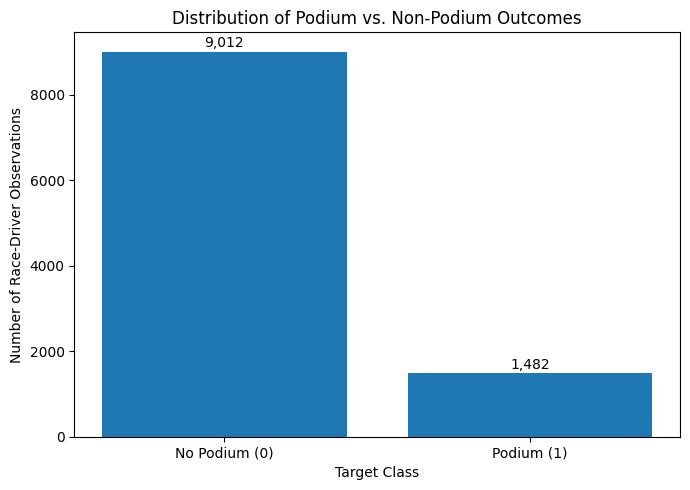

In [ ]:
import matplotlib.pyplot as plt

# Target distribution
target_counts = model["podium"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Podium (0)", "Podium (1)"],
    target_counts.values
)

plt.xlabel("Target Class")
plt.ylabel("Number of Race-Driver Observations")
plt.title("Distribution of Podium vs. Non-Podium Outcomes")

for i, value in enumerate(target_counts.values):
    plt.text(
        i,
        value + 100,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

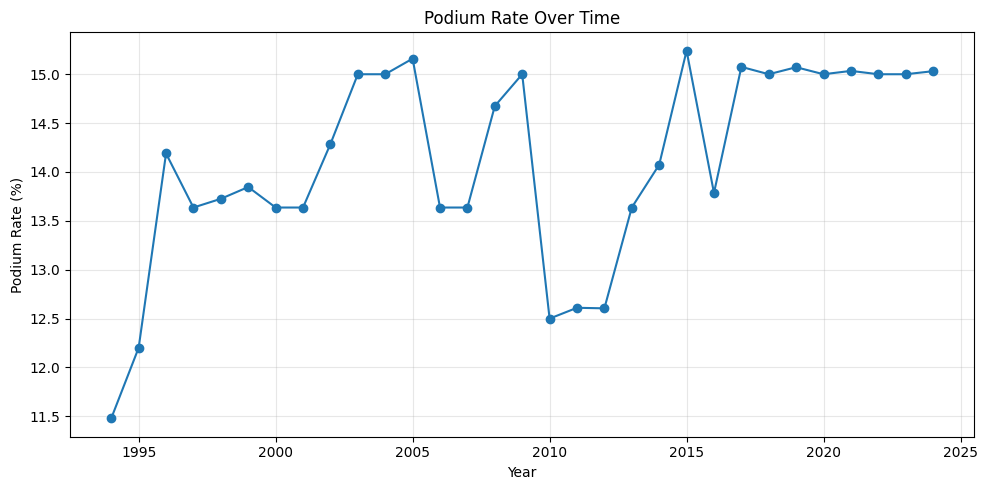

In [ ]:
# Podium rate by year

podium_by_year = (
    model.groupby("year")["podium"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    podium_by_year["year"],
    podium_by_year["podium"] * 100,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Podium Rate (%)")
plt.title("Podium Rate Over Time")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

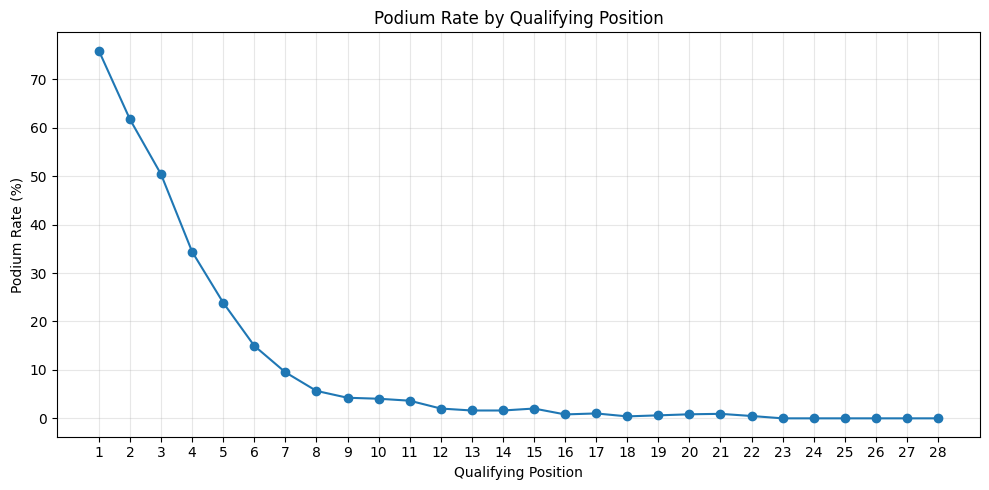

In [ ]:
# Podium rate by qualifying position

qualifying_effect = (
    model.groupby("qualifying_position")["podium"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    qualifying_effect["qualifying_position"],
    qualifying_effect["podium"] * 100,
    marker="o"
)

plt.xlabel("Qualifying Position")
plt.ylabel("Podium Rate (%)")
plt.title("Podium Rate by Qualifying Position")
plt.xticks(
    sorted(model["qualifying_position"].unique())
)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

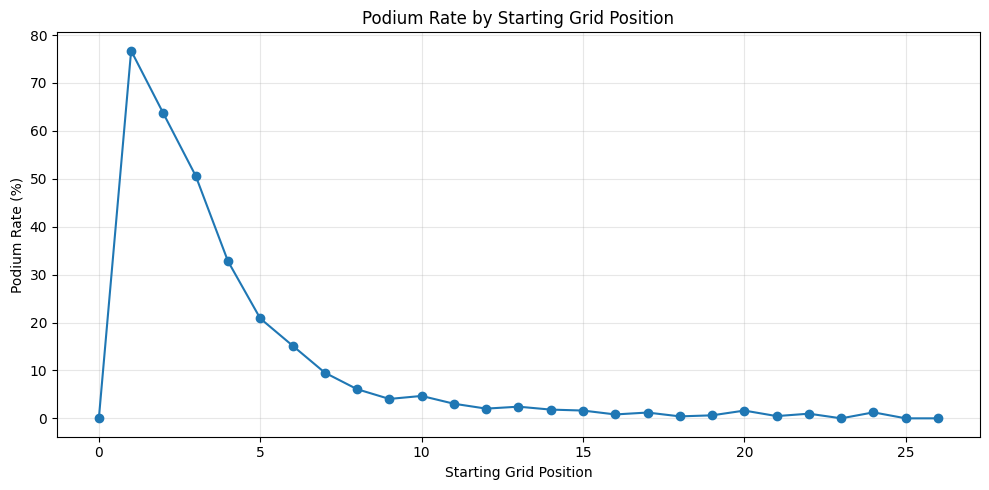

In [ ]:
# Podium rate by actual starting grid position

grid_effect = (
    model.groupby("grid")["podium"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    grid_effect["grid"],
    grid_effect["podium"] * 100,
    marker="o"
)

plt.xlabel("Starting Grid Position")
plt.ylabel("Podium Rate (%)")
plt.title("Podium Rate by Starting Grid Position")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

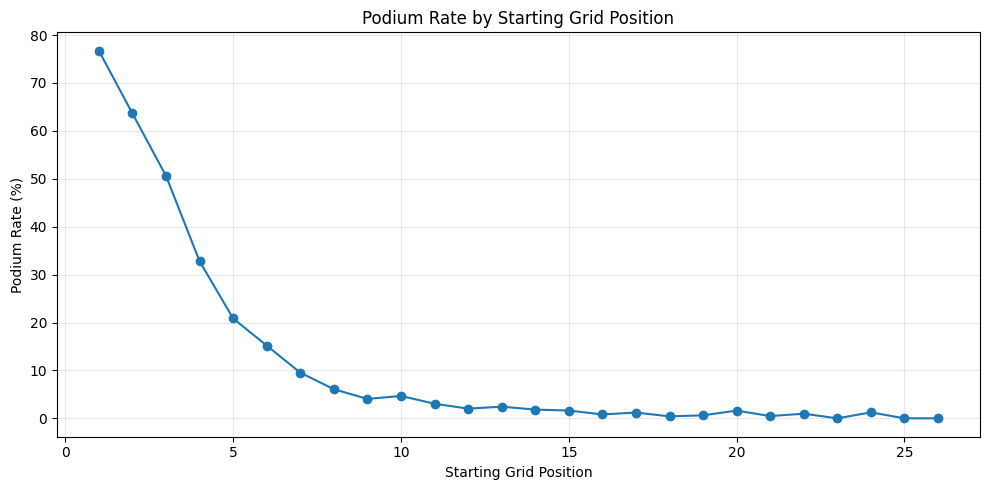

In [ ]:
# Exclude the special grid=0 encoding from this visualization.
# This does NOT modify the underlying model data.

grid_effect = (
    model[model["grid"] > 0]
    .groupby("grid")["podium"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    grid_effect["grid"],
    grid_effect["podium"] * 100,
    marker="o"
)

plt.xlabel("Starting Grid Position")
plt.ylabel("Podium Rate (%)")
plt.title("Podium Rate by Starting Grid Position")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

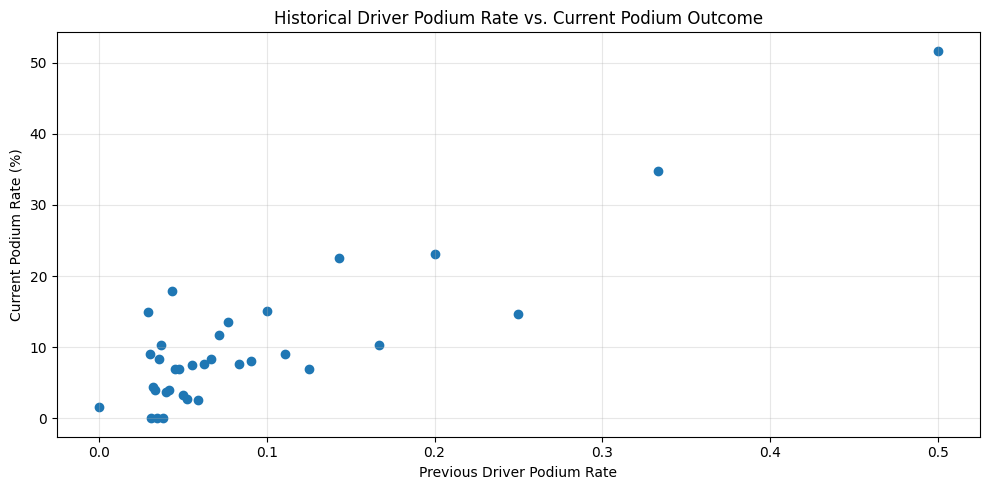

In [ ]:
# Relationship between historical driver podium rate and current podium outcome

driver_history_effect = (
    model.groupby("driver_previous_podium_rate")["podium"]
    .mean()
    .reset_index()
)

# Keep only values with enough observations for a meaningful visualization
driver_history_counts = (
    model["driver_previous_podium_rate"]
    .value_counts()
)

valid_history_values = driver_history_counts[
    driver_history_counts >= 20
].index

driver_history_effect = driver_history_effect[
    driver_history_effect["driver_previous_podium_rate"]
    .isin(valid_history_values)
]

plt.figure(figsize=(10, 5))

plt.scatter(
    driver_history_effect["driver_previous_podium_rate"],
    driver_history_effect["podium"] * 100
)

plt.xlabel("Previous Driver Podium Rate")
plt.ylabel("Current Podium Rate (%)")
plt.title("Historical Driver Podium Rate vs. Current Podium Outcome")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

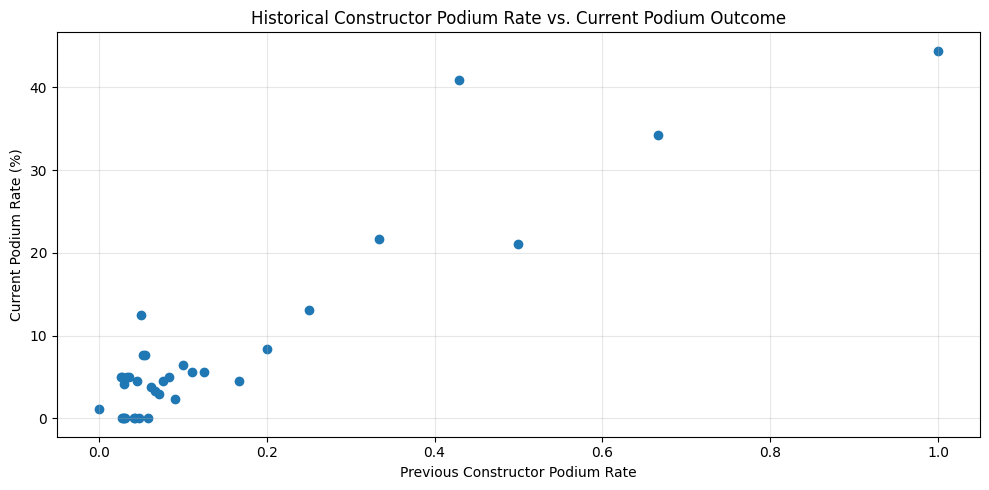

In [ ]:
# Relationship between historical constructor podium rate
# and current podium outcome

constructor_history_effect = (
    model.groupby("constructor_previous_podium_rate")["podium"]
    .mean()
    .reset_index()
)

constructor_history_counts = (
    model["constructor_previous_podium_rate"]
    .value_counts()
)

valid_constructor_values = constructor_history_counts[
    constructor_history_counts >= 20
].index

constructor_history_effect = constructor_history_effect[
    constructor_history_effect["constructor_previous_podium_rate"]
    .isin(valid_constructor_values)
]

plt.figure(figsize=(10, 5))

plt.scatter(
    constructor_history_effect["constructor_previous_podium_rate"],
    constructor_history_effect["podium"] * 100
)

plt.xlabel("Previous Constructor Podium Rate")
plt.ylabel("Current Podium Rate (%)")
plt.title("Historical Constructor Podium Rate vs. Current Podium Outcome")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

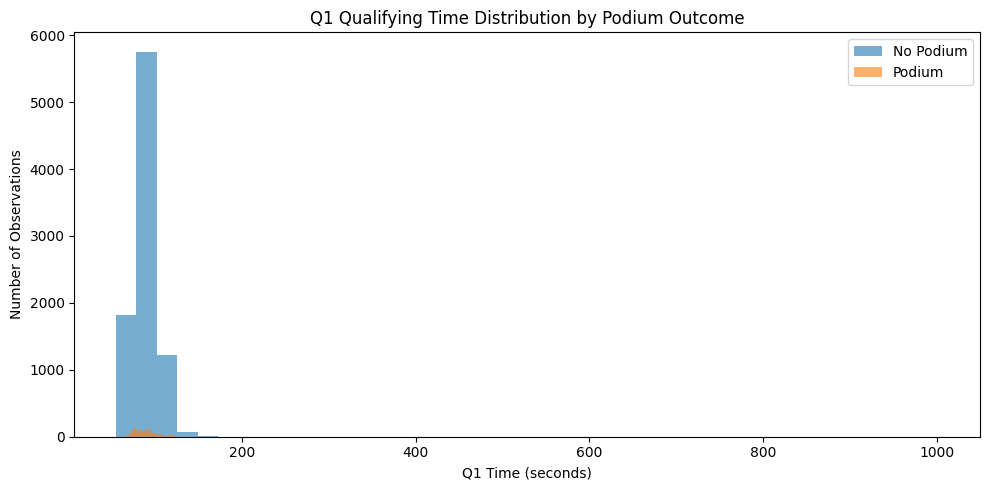

In [ ]:
# Q1 qualifying time distribution by podium outcome

plt.figure(figsize=(10, 5))

plt.hist(
    model.loc[
        model["podium"] == 0,
        "q1_seconds"
    ].dropna(),
    bins=40,
    alpha=0.6,
    label="No Podium"
)

plt.hist(
    model.loc[
        model["podium"] == 1,
        "q1_seconds"
    ].dropna(),
    bins=40,
    alpha=0.6,
    label="Podium"
)

plt.xlabel("Q1 Time (seconds)")
plt.ylabel("Number of Observations")
plt.title("Q1 Qualifying Time Distribution by Podium Outcome")
plt.legend()

plt.tight_layout()
plt.show()

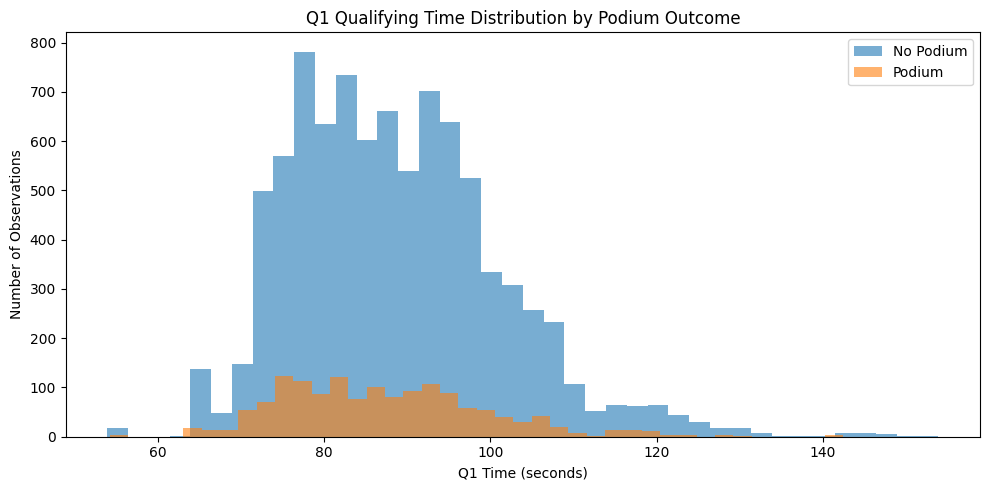

In [ ]:
# Q1 qualifying-time distribution by podium outcome
# The x-axis is limited for visualization only.
# The underlying data, including historical extreme values, is unchanged.

q1_plot_data = model[
    model["q1_seconds"] <= 200
].copy()

plt.figure(figsize=(10, 5))

plt.hist(
    q1_plot_data.loc[
        q1_plot_data["podium"] == 0,
        "q1_seconds"
    ].dropna(),
    bins=40,
    alpha=0.6,
    label="No Podium"
)

plt.hist(
    q1_plot_data.loc[
        q1_plot_data["podium"] == 1,
        "q1_seconds"
    ].dropna(),
    bins=40,
    alpha=0.6,
    label="Podium"
)

plt.xlabel("Q1 Time (seconds)")
plt.ylabel("Number of Observations")
plt.title("Q1 Qualifying Time Distribution by Podium Outcome")
plt.legend()

plt.tight_layout()
plt.show()

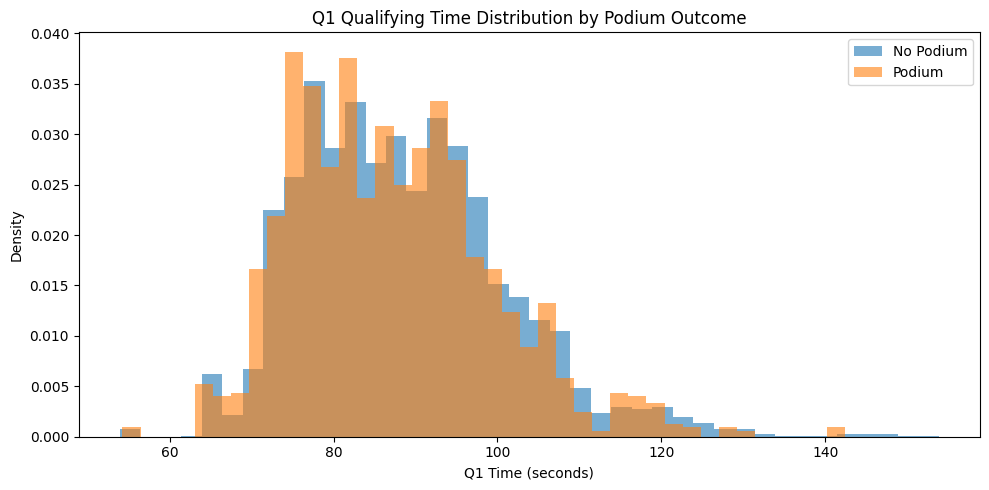

In [ ]:
# Compare Q1 qualifying-time distributions by podium outcome
# using proportions rather than raw observation counts.

q1_plot_data = model[
    model["q1_seconds"] <= 200
].copy()

plt.figure(figsize=(10, 5))

plt.hist(
    q1_plot_data.loc[
        q1_plot_data["podium"] == 0,
        "q1_seconds"
    ].dropna(),
    bins=40,
    density=True,
    alpha=0.6,
    label="No Podium"
)

plt.hist(
    q1_plot_data.loc[
        q1_plot_data["podium"] == 1,
        "q1_seconds"
    ].dropna(),
    bins=40,
    density=True,
    alpha=0.6,
    label="Podium"
)

plt.xlabel("Q1 Time (seconds)")
plt.ylabel("Density")
plt.title("Q1 Qualifying Time Distribution by Podium Outcome")
plt.legend()

plt.tight_layout()
plt.show()

## Data-Engineering Questions

## Data-Engineering Question 1

### Which circuits convert a front-row start into a podium most often, and does the ranking change after the 2014 hybrid era?

A front-row start is defined using the actual starting grid (`grid` positions 1 or 2), rather than qualifying position. This distinction is important because penalties can change a driver's starting position after qualifying.

For each circuit, the front-row podium conversion rate is calculated as:

**Front-row podium conversion rate = podium finishes among front-row starters / total front-row starters**

The analysis compares the pre-hybrid period (1994–2013) with the hybrid era and later period (2014–2024).

Only the race-driver grain is used, with one row per `(raceId, driverId)`.

In [ ]:
# ============================================================
# Data-Engineering Question 1
# Front-row podium conversion by circuit and era
# ============================================================

# Add circuit names to the analysis table.
# We use the actual grid position, not qualifying position.

q1_analysis = (
    model[
        [
            "raceId",
            "driverId",
            "year",
            "circuitId",
            "grid",
            "podium"
        ]
    ]
    .merge(
        circuits[["circuitId", "name"]],
        on="circuitId",
        how="left"
    )
    .copy()
)

# Define actual front-row starters.
q1_analysis["front_row"] = (
    q1_analysis["grid"].isin([1, 2])
).astype(int)

# Keep only actual front-row starts.
q1_front_row = q1_analysis[
    q1_analysis["front_row"] == 1
].copy()

# Define the two historical periods.
q1_front_row["era"] = np.where(
    q1_front_row["year"] < 2014,
    "Pre-Hybrid (1994-2013)",
    "Hybrid+ (2014-2024)"
)

# Aggregate by circuit and era.
q1_circuit = (
    q1_front_row
    .groupby(
        ["era", "circuitId", "name"],
        as_index=False
    )
    .agg(
        front_row_starts=("podium", "size"),
        podiums=("podium", "sum")
    )
)

# Calculate podium conversion rate.
q1_circuit["podium_conversion_rate"] = (
    q1_circuit["podiums"]
    / q1_circuit["front_row_starts"]
)

# Display the strongest circuits.
q1_circuit.sort_values(
    ["era", "podium_conversion_rate"],
    ascending=[True, False]
).head(20)

,era,circuitId,name,front_row_starts,podiums,podium_conversion_rate
26,Hybrid+ (2014-2024),75,Autódromo Internacional do Algarve,4,4,1.000000
27,Hybrid+ (2014-2024),76,Autodromo Internazionale del Mugello,2,2,1.000000
30,Hybrid+ (2014-2024),79,Miami International Autodrome,6,6,1.000000
31,Hybrid+ (2014-2024),80,Las Vegas Strip Street Circuit,4,4,1.000000
17,Hybrid+ (2014-2024),22,Suzuka Circuit,18,16,0.888889
21,Hybrid+ (2014-2024),39,Circuit Park Zandvoort,8,7,0.875000
28,Hybrid+ (2014-2024),77,Jeddah Corniche Circuit,8,7,0.875000
18,Hybrid+ (2014-2024),24,Yas Marina Circuit,22,19,0.863636
1,Hybrid+ (2014-2024),2,Sepang International Circuit,7,6,0.857143
5,Hybrid+ (2014-2024),6,Circuit de Monaco,20,17,0.850000


In [ ]:
# ============================================================
# Q1: Reliable circuit ranking
# Require at least 10 front-row starts in each era
# ============================================================

q1_reliable = q1_circuit[
    q1_circuit["front_row_starts"] >= 10
].copy()

# Rank circuits within each era
q1_reliable["rank"] = (
    q1_reliable
    .groupby("era")["podium_conversion_rate"]
    .rank(
        ascending=False,
        method="min"
    )
)

# Show the top 10 circuits in each era
q1_top10 = (
    q1_reliable
    .sort_values(
        ["era", "podium_conversion_rate"],
        ascending=[True, False]
    )
    .groupby("era")
    .head(10)
)

print(q1_top10.to_string(index=False))

                   era  circuitId                           name  front_row_starts  podiums  podium_conversion_rate  rank
   Hybrid+ (2014-2024)         22                 Suzuka Circuit                18       16                0.888889   1.0
   Hybrid+ (2014-2024)         24             Yas Marina Circuit                22       19                0.863636   2.0
   Hybrid+ (2014-2024)          6              Circuit de Monaco                20       17                0.850000   3.0
   Hybrid+ (2014-2024)          4 Circuit de Barcelona-Catalunya                22       18                0.818182   4.0
   Hybrid+ (2014-2024)         13   Circuit de Spa-Francorchamps                22       18                0.818182   4.0
   Hybrid+ (2014-2024)         71                 Sochi Autodrom                16       13                0.812500   6.0
   Hybrid+ (2014-2024)         69        Circuit of the Americas                20       16                0.800000   7.0
   Hybrid+ (2014-2024)  

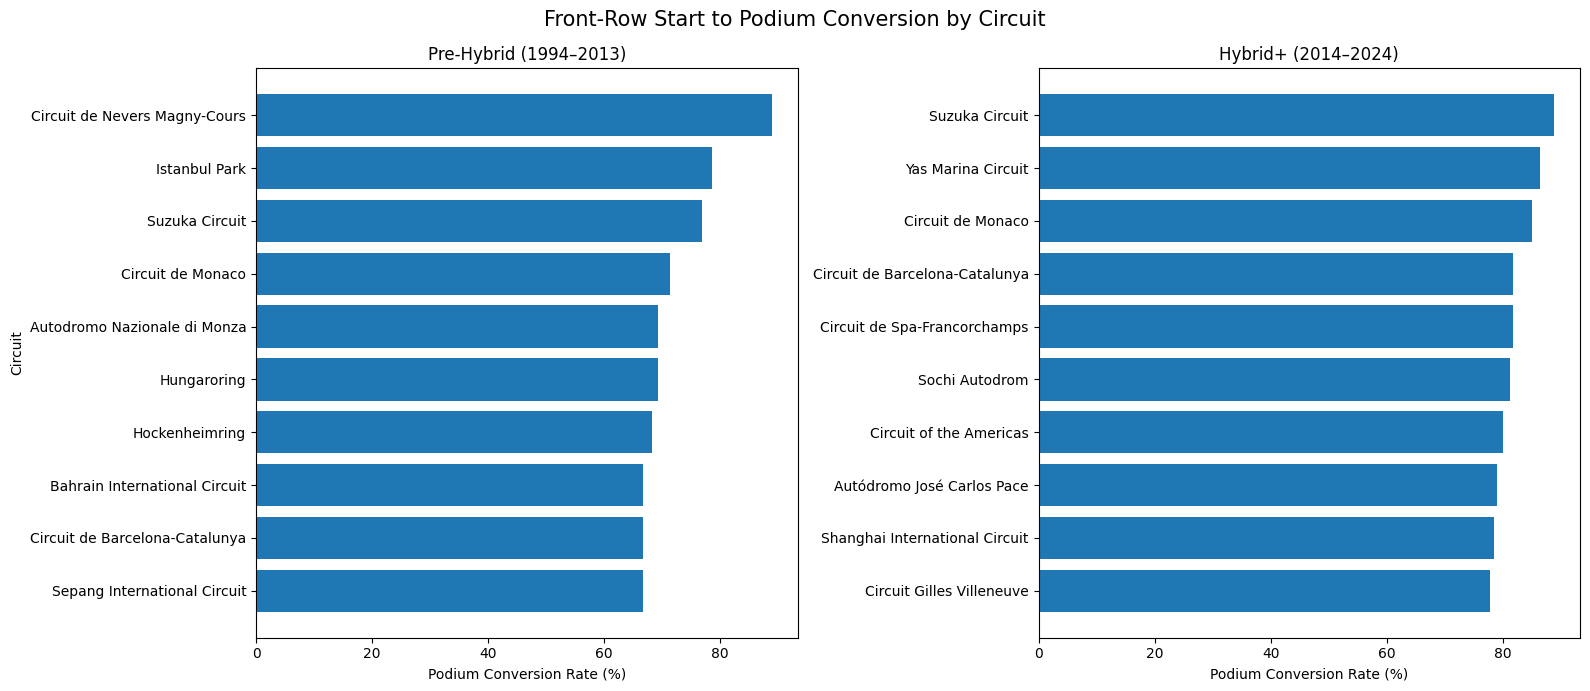

In [ ]:
# ============================================================
# Q1 Final Visualization
# Top circuits by front-row -> podium conversion rate
# ============================================================

# Select the top 10 circuits from each era
plot_data = q1_reliable.copy()

pre_hybrid = (
    plot_data[
        plot_data["era"] == "Pre-Hybrid (1994-2013)"
    ]
    .sort_values("podium_conversion_rate", ascending=True)
    .tail(10)
)

hybrid = (
    plot_data[
        plot_data["era"] == "Hybrid+ (2014-2024)"
    ]
    .sort_values("podium_conversion_rate", ascending=True)
    .tail(10)
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7),
    sharex=True
)

# Pre-hybrid
axes[0].barh(
    pre_hybrid["name"],
    pre_hybrid["podium_conversion_rate"] * 100
)

axes[0].set_title("Pre-Hybrid (1994–2013)")
axes[0].set_xlabel("Podium Conversion Rate (%)")
axes[0].set_ylabel("Circuit")

# Hybrid+
axes[1].barh(
    hybrid["name"],
    hybrid["podium_conversion_rate"] * 100
)

axes[1].set_title("Hybrid+ (2014–2024)")
axes[1].set_xlabel("Podium Conversion Rate (%)")
axes[1].set_ylabel("")

fig.suptitle(
    "Front-Row Start to Podium Conversion by Circuit",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Answer to Data-Engineering Question 1

The circuit ranking for converting an actual front-row start into a podium changes between the pre-hybrid and hybrid+ periods. Using circuits with at least 10 front-row starts to avoid unstable rankings from very small samples, Magny-Cours has the highest conversion rate in the pre-hybrid period (16 podiums from 18 front-row starts; 88.9%). Istanbul Park ranks second (78.6%), followed by Suzuka (76.9%).

In the hybrid+ period, Suzuka becomes the highest-ranked circuit (16 podiums from 18 front-row starts; 88.9%), followed by Yas Marina (86.4%) and Monaco (85.0%). Therefore, the ranking does change after the 2014 transition.

The analysis uses `grid` positions 1 and 2 to define a front-row start rather than `qualifying_position`, because penalties can change the actual starting grid after qualifying. The unit of analysis is one driver-race observation, and the podium outcome is measured from the final race classification. The front-row condition is therefore pre-race information while the podium is the resulting outcome.

Circuits with fewer than 10 front-row starts per period were excluded from the ranking because their conversion rates would be based on very small samples. This threshold is used only for the analytical ranking and does not modify the modeling dataset.

In [ ]:
# ============================================================
# Data-Engineering Question 2
# Home-country advantage after controlling for grid position
# ============================================================

q2_analysis = model[
    [
        "raceId",
        "driverId",
        "year",
        "grid",
        "home_race",
        "podium"
    ]
].copy()

# Exclude the special grid=0 encoding from this analysis.
# Grid=0 represents a pit-lane start in the project documentation.
q2_analysis = q2_analysis[
    q2_analysis["grid"] > 0
].copy()

# Create comparable starting-position groups.
q2_analysis["grid_group"] = pd.cut(
    q2_analysis["grid"],
    bins=[0, 3, 10, 15, np.inf],
    labels=[
        "Front (1-3)",
        "Upper midfield (4-10)",
        "Midfield (11-15)",
        "Back (16+)"
    ]
)

# Calculate podium rate within each starting-position group
# separately for home and non-home races.
q2_grouped = (
    q2_analysis
    .groupby(
        ["grid_group", "home_race"],
        observed=False
    )
    .agg(
        observations=("podium", "size"),
        podiums=("podium", "sum"),
        podium_rate=("podium", "mean")
    )
    .reset_index()
)

q2_grouped["home_status"] = q2_grouped["home_race"].map({
    0: "Non-home",
    1: "Home"
})

q2_grouped["podium_rate_percent"] = (
    q2_grouped["podium_rate"] * 100
)

q2_grouped[
    [
        "grid_group",
        "home_status",
        "observations",
        "podiums",
        "podium_rate_percent"
    ]
]

,grid_group,home_status,observations,podiums,podium_rate_percent
0,Front (1-3),Non-home,1409,900,63.875089
1,Front (1-3),Home,71,42,59.154930
2,Upper midfield (4-10),Non-home,3294,442,13.418336
3,Upper midfield (4-10),Home,160,18,11.250000
4,Midfield (11-15),Non-home,2353,53,2.252444
5,Midfield (11-15),Home,110,1,0.909091
6,Back (16+),Non-home,2874,25,0.869868
7,Back (16+),Home,136,1,0.735294


In [ ]:
# ============================================================
# Q2: Grid-adjusted overall home vs. non-home podium rate
# ============================================================

# Use the pooled distribution of grid groups as the common weights.
grid_weights = (
    q2_analysis["grid_group"]
    .value_counts(normalize=True)
    .sort_index()
)

# Get podium rates for home and non-home drivers.
rate_table = (
    q2_grouped
    .pivot(
        index="grid_group",
        columns="home_status",
        values="podium_rate"
    )
    .reindex(grid_weights.index)
)

# Standardized (grid-adjusted) podium rates.
adjusted_non_home = (
    rate_table["Non-home"] * grid_weights
).sum()

adjusted_home = (
    rate_table["Home"] * grid_weights
).sum()

adjusted_difference = adjusted_home - adjusted_non_home

print("Grid-adjusted podium rate:")
print(f"Home:     {adjusted_home * 100:.2f}%")
print(f"Non-home: {adjusted_non_home * 100:.2f}%")

print(
    f"\nAdjusted difference (Home - Non-home): "
    f"{adjusted_difference * 100:.2f} percentage points"
)

print("\nGrid-group weights used:")
print((grid_weights * 100).round(2))

Grid-adjusted podium rate:
Home:     12.57%
Non-home: 14.32%

Adjusted difference (Home - Non-home): -1.75 percentage points

Grid-group weights used:
grid_group
Front (1-3)              14.22
Upper midfield (4-10)    33.19
Midfield (11-15)         23.67
Back (16+)               28.92
Name: proportion, dtype: float64


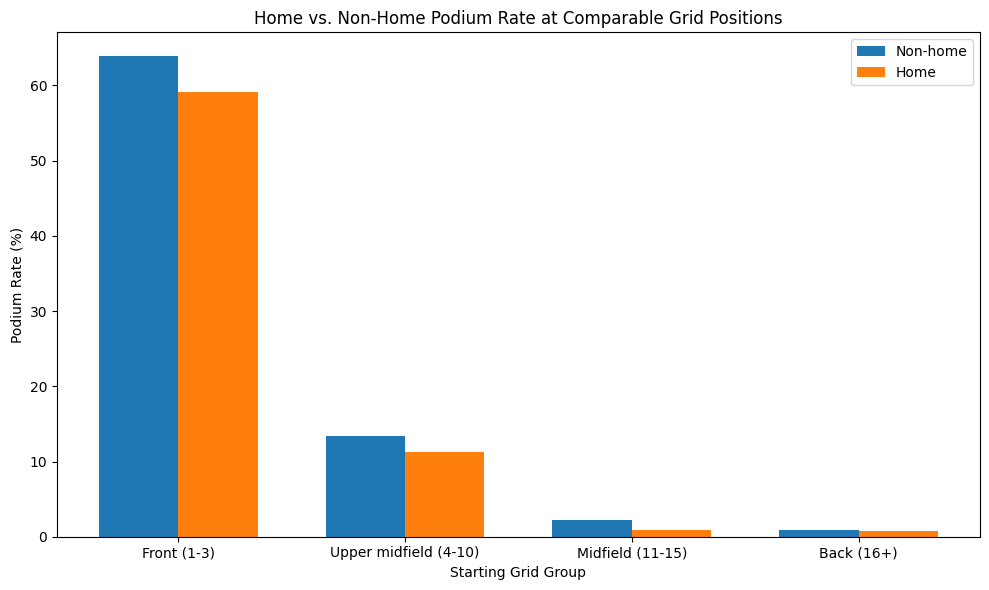

In [ ]:
# ============================================================
# Q2 Final Visualization
# Podium rate by home status within comparable grid groups
# ============================================================

plot_q2 = q2_grouped.copy()

# Convert to percentage
plot_q2["podium_rate_percent"] = (
    plot_q2["podium_rate"] * 100
)

grid_order = [
    "Front (1-3)",
    "Upper midfield (4-10)",
    "Midfield (11-15)",
    "Back (16+)"
]

home_rates = (
    plot_q2[
        plot_q2["home_status"] == "Home"
    ]
    .set_index("grid_group")
    .reindex(grid_order)["podium_rate_percent"]
)

non_home_rates = (
    plot_q2[
        plot_q2["home_status"] == "Non-home"
    ]
    .set_index("grid_group")
    .reindex(grid_order)["podium_rate_percent"]
)

x = np.arange(len(grid_order))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    non_home_rates.values,
    width,
    label="Non-home"
)

plt.bar(
    x + width / 2,
    home_rates.values,
    width,
    label="Home"
)

plt.xticks(
    x,
    grid_order
)

plt.xlabel("Starting Grid Group")
plt.ylabel("Podium Rate (%)")
plt.title("Home vs. Non-Home Podium Rate at Comparable Grid Positions")
plt.legend()

plt.tight_layout()
plt.show()

### Answer to Data-Engineering Question 2

After controlling for starting position, the analysis does not show a positive home-country advantage in podium finishes. The podium rate for home races is lower than the non-home rate in every starting-grid group: 59.15% vs. 63.88% for the front group, 11.25% vs. 13.42% for positions 4–10, 0.91% vs. 2.25% for positions 11–15, and 0.74% vs. 0.87% for positions 16 and above.

Using the pooled distribution of starting-grid groups to standardize both groups gives a grid-adjusted podium rate of 12.57% for home races and 14.32% for non-home races, a difference of -1.75 percentage points.

The analysis excludes grid=0 observations because this value represents a pit-lane start rather than a normal grid position. Home race is determined by mapping the driver's nationality to the circuit country. The comparison uses one driver-race observation per `(raceId, driverId)` and compares the pre-race starting position with the eventual podium outcome.

This result should be interpreted as an association in the dataset, not as evidence that racing at home causes a lower podium probability.

## Data-Engineering Question 3

In [ ]:
# ============================================================
# Data-Engineering Question 3
# Inspect actual retirement/status values
# ============================================================

status = pd.read_csv(
    f"{data_path}/status.csv",
    na_values="\\N"
)

# Race results from the required periods
q3_base = (
    results_clean[
        ["raceId", "driverId", "constructorId", "statusId"]
    ]
    .merge(
        races[["raceId", "year"]],
        on="raceId",
        how="left"
    )
)

q3_base = q3_base[
    q3_base["year"].between(2014, 2024)
].copy()

# Attach status descriptions
q3_base = q3_base.merge(
    status[["statusId", "status"]],
    on="statusId",
    how="left"
)

# Count each status
status_counts = (
    q3_base
    .groupby("status", dropna=False)
    .size()
    .sort_values(ascending=False)
)

print("Status values in 2014-2024:")
print(status_counts.to_string())

Status values in 2014-2024:
status
Finished            2403
+1 Lap              1178
+2 Laps              208
Collision            150
Accident              85
Engine                81
Collision damage      59
Retired               50
Brakes                49
Gearbox               42
Power Unit            42
Suspension            25
+3 Laps               24
Hydraulics            15
Withdrew              14
Electrical            14
Power loss            13
Disqualified          11
Wheel                 11
Spun off              11
Oil leak              10
Overheating            8
Water pressure         7
Puncture               7
Mechanical             7
Turbo                  6
+4 Laps                6
Battery                5
Fuel pressure          5
Exhaust                5
ERS                    5
Undertray              4
Electronics            4
Water leak             4
Tyre                   4
Front wing             3
Transmission           3
Wheel nut              3
Rear wing      

In [ ]:
# ============================================================
# Data-Engineering Question 3
# Define mechanical vs. non-mechanical retirement statuses
# ============================================================

# Clear component/system-failure statuses observed in the dataset.
mechanical_statuses = {
    "Engine",
    "Brakes",
    "Gearbox",
    "Power Unit",
    "Suspension",
    "Hydraulics",
    "Electrical",
    "Power loss",
    "Oil leak",
    "Overheating",
    "Water pressure",
    "Turbo",
    "Battery",
    "Fuel pressure",
    "Exhaust",
    "ERS",
    "Electronics",
    "Water leak",
    "Transmission",
    "Wheel",
    "Wheel nut",
    "Puncture",
    "Radiator",
    "Oil pressure",
    "Throttle",
    "Clutch",
    "Driveshaft",
    "Fuel leak",
    "Vibrations",
    "Steering",
    "Fuel system",
    "Fuel pump",
    "Drivetrain",
    "Brake duct",
    "Cooling system",
    "Differential",
    "Spark plugs",
    "Water pump",
    "Mechanical",
    "Technical"
}

# Join status and grid information.
q3_base = (
    results_clean[
        [
            "raceId",
            "driverId",
            "constructorId",
            "statusId",
            "grid"
        ]
    ]
    .merge(
        races[["raceId", "year"]],
        on="raceId",
        how="left"
    )
    .merge(
        status[["statusId", "status"]],
        on="statusId",
        how="left"
    )
)

# Keep only the two requested periods.
q3_base = q3_base[
    q3_base["year"].between(2014, 2024)
].copy()

# Race-start definition:
# "Withdrew" is excluded because the driver did not start the race.
# Other statuses remain race outcomes and therefore stay in the denominator.
q3_base["race_started"] = (
    q3_base["status"] != "Withdrew"
).astype(int)

# Mechanical failure indicator.
q3_base["mechanical_retirement"] = (
    q3_base["status"].isin(mechanical_statuses)
).astype(int)

# The mechanical indicator is only meaningful for actual race starts.
q3_base.loc[
    q3_base["race_started"] == 0,
    "mechanical_retirement"
] = 0

# Historical periods required by the question.
q3_base["era"] = np.where(
    q3_base["year"].between(2014, 2021),
    "2014-2021",
    "2022-2024"
)

print("Mechanical statuses used:")
print(sorted(mechanical_statuses))

print("\nStatuses NOT classified as mechanical:")
print(
    sorted(
        set(q3_base["status"].dropna().unique())
        - mechanical_statuses
    )
)

print("\nRace-start counts:")
print(
    q3_base.groupby("era")["race_started"]
    .sum()
)

print("\nMechanical-retirement counts:")
print(
    q3_base.groupby("era")["mechanical_retirement"]
    .sum()
)

Mechanical statuses used:
['Battery', 'Brake duct', 'Brakes', 'Clutch', 'Cooling system', 'Differential', 'Driveshaft', 'Drivetrain', 'ERS', 'Electrical', 'Electronics', 'Engine', 'Exhaust', 'Fuel leak', 'Fuel pressure', 'Fuel pump', 'Fuel system', 'Gearbox', 'Hydraulics', 'Mechanical', 'Oil leak', 'Oil pressure', 'Overheating', 'Power Unit', 'Power loss', 'Puncture', 'Radiator', 'Spark plugs', 'Steering', 'Suspension', 'Technical', 'Throttle', 'Transmission', 'Turbo', 'Vibrations', 'Water leak', 'Water pressure', 'Water pump', 'Wheel', 'Wheel nut']

Statuses NOT classified as mechanical:
['+1 Lap', '+2 Laps', '+3 Laps', '+4 Laps', '+5 Laps', '+6 Laps', '+7 Laps', '+8 Laps', 'Accident', 'Collision', 'Collision damage', 'Damage', 'Debris', 'Disqualified', 'Excluded', 'Finished', 'Front wing', 'Illness', 'Out of fuel', 'Rear wing', 'Retired', 'Seat', 'Spun off', 'Tyre', 'Undertray', 'Withdrew']

Race-start counts:
era
2014-2021    3258
2022-2024    1354
Name: race_started, dtype: int64



In [ ]:
# ============================================================
# Q3: Final documented mechanical-retirement mapping
# ============================================================

mechanical_statuses = {
    # Engine / powertrain
    "Engine",
    "Power Unit",
    "Power loss",
    "Turbo",
    "ERS",
    "Electrical",
    "Electronics",
    "Battery",
    "Spark plugs",

    # Transmission / drivetrain
    "Gearbox",
    "Transmission",
    "Drivetrain",
    "Differential",
    "Driveshaft",
    "Clutch",

    # Braking / steering / suspension
    "Brakes",
    "Brake duct",
    "Steering",
    "Suspension",

    # Cooling / fluids
    "Cooling system",
    "Radiator",
    "Water leak",
    "Water pressure",
    "Water pump",
    "Overheating",
    "Oil leak",
    "Oil pressure",

    # Fuel system
    "Fuel system",
    "Fuel pump",
    "Fuel pressure",
    "Fuel leak",

    # Other car/component failures
    "Hydraulics",
    "Exhaust",
    "Mechanical",
    "Technical",
    "Vibrations",
    "Wheel",
    "Wheel nut",
    "Puncture",
    "Tyre",
    "Front wing",
    "Rear wing",
    "Undertray",
    "Seat"
}

# Rebuild Q3 analysis table
q3_base = (
    results_clean[
        [
            "raceId",
            "driverId",
            "constructorId",
            "statusId"
        ]
    ]
    .merge(
        races[["raceId", "year"]],
        on="raceId",
        how="left"
    )
    .merge(
        status[["statusId", "status"]],
        on="statusId",
        how="left"
    )
)

# Requested periods only
q3_base = q3_base[
    q3_base["year"].between(2014, 2024)
].copy()

# Race starts:
# Withdrew means the driver did not start.
q3_base["race_started"] = (
    q3_base["status"] != "Withdrew"
).astype(int)

# Mechanical retirement indicator
q3_base["mechanical_retirement"] = (
    q3_base["status"].isin(mechanical_statuses)
).astype(int)

# Only actual race starts can have a mechanical retirement
q3_base.loc[
    q3_base["race_started"] == 0,
    "mechanical_retirement"
] = 0

# Required comparison periods
q3_base["era"] = np.where(
    q3_base["year"].between(2014, 2021),
    "2014-2021",
    "2022-2024"
)

# Verify that every status in the dataset is accounted for
unclassified_statuses = sorted(
    set(q3_base["status"].dropna().unique())
    - mechanical_statuses
)

print("Mechanical statuses:")
print(sorted(mechanical_statuses))

print("\nOther/non-mechanical statuses:")
print(unclassified_statuses)

print("\nMechanical retirements by era:")
print(
    q3_base.groupby("era")["mechanical_retirement"].sum()
)

Mechanical statuses:
['Battery', 'Brake duct', 'Brakes', 'Clutch', 'Cooling system', 'Differential', 'Driveshaft', 'Drivetrain', 'ERS', 'Electrical', 'Electronics', 'Engine', 'Exhaust', 'Front wing', 'Fuel leak', 'Fuel pressure', 'Fuel pump', 'Fuel system', 'Gearbox', 'Hydraulics', 'Mechanical', 'Oil leak', 'Oil pressure', 'Overheating', 'Power Unit', 'Power loss', 'Puncture', 'Radiator', 'Rear wing', 'Seat', 'Spark plugs', 'Steering', 'Suspension', 'Technical', 'Transmission', 'Turbo', 'Tyre', 'Undertray', 'Vibrations', 'Water leak', 'Water pressure', 'Water pump', 'Wheel', 'Wheel nut']

Other/non-mechanical statuses:
['+1 Lap', '+2 Laps', '+3 Laps', '+4 Laps', '+5 Laps', '+6 Laps', '+7 Laps', '+8 Laps', 'Accident', 'Collision', 'Collision damage', 'Damage', 'Debris', 'Disqualified', 'Excluded', 'Finished', 'Illness', 'Out of fuel', 'Retired', 'Spun off', 'Throttle', 'Withdrew']

Mechanical retirements by era:
era
2014-2021    328
2022-2024     83
Name: mechanical_retirement, dtype: i

In [ ]:
# ============================================================
# Q3: Mechanical-retirement rate by constructor and era
# ============================================================

q3_constructor = (
    q3_base[q3_base["race_started"] == 1]
    .groupby(
        ["era", "constructorId"],
        as_index=False
    )
    .agg(
        race_starts=("race_started", "sum"),
        mechanical_retirements=("mechanical_retirement", "sum")
    )
)

q3_constructor["mechanical_retirement_rate"] = (
    q3_constructor["mechanical_retirements"]
    / q3_constructor["race_starts"]
)

# Require at least 20 race starts within an era
# to avoid rankings dominated by tiny samples.
q3_reliable = q3_constructor[
    q3_constructor["race_starts"] >= 20
].copy()

q3_reliable["rank"] = (
    q3_reliable
    .groupby("era")["mechanical_retirement_rate"]
    .rank(
        ascending=False,
        method="min"
    )
)

q3_top10 = (
    q3_reliable
    .sort_values(
        ["era", "mechanical_retirement_rate"],
        ascending=[True, False]
    )
    .groupby("era")
    .head(10)
)

q3_top10

,era,constructorId,race_starts,mechanical_retirements,mechanical_retirement_rate,rank
12,2014-2021,207,34,8,0.235294,1.0
13,2014-2021,208,75,15,0.200000,2.0
3,2014-2021,5,242,40,0.165289,3.0
2,2014-2021,4,200,29,0.145000,4.0
0,2014-2021,1,318,46,0.144654,5.0
7,2014-2021,15,200,23,0.115000,6.0
5,2014-2021,9,319,36,0.112853,7.0
16,2014-2021,211,76,8,0.105263,8.0
17,2014-2021,213,78,8,0.102564,9.0
11,2014-2021,206,31,3,0.096774,10.0


In [ ]:
# ============================================================
# Q3: Correct the mechanical-failure mapping
# ============================================================

mechanical_statuses.add("Throttle")

# Recalculate mechanical retirement indicator
q3_base["mechanical_retirement"] = (
    q3_base["status"].isin(mechanical_statuses)
).astype(int)

# A non-starter cannot have a mechanical race retirement
q3_base.loc[
    q3_base["race_started"] == 0,
    "mechanical_retirement"
] = 0

print("Updated mechanical status count:",
      len(mechanical_statuses))

print("\nThrottle classified as mechanical:",
      "Throttle" in mechanical_statuses)

print("\nMechanical retirements by era:")
print(
    q3_base.groupby("era")["mechanical_retirement"]
    .sum()
)

Updated mechanical status count: 45

Throttle classified as mechanical: True

Mechanical retirements by era:
era
2014-2021    330
2022-2024     83
Name: mechanical_retirement, dtype: int64


In [ ]:
# ============================================================
# Q3: Final constructor mechanical-retirement rates
# ============================================================

q3_constructor = (
    q3_base[q3_base["race_started"] == 1]
    .groupby(
        ["era", "constructorId"],
        as_index=False
    )
    .agg(
        race_starts=("race_started", "sum"),
        mechanical_retirements=("mechanical_retirement", "sum")
    )
)

q3_constructor["mechanical_retirement_rate"] = (
    q3_constructor["mechanical_retirements"]
    / q3_constructor["race_starts"]
)

# Keep constructors with at least 20 race starts in the era
q3_reliable = q3_constructor[
    q3_constructor["race_starts"] >= 20
].copy()

# Rank within each era
q3_reliable["rank"] = (
    q3_reliable
    .groupby("era")["mechanical_retirement_rate"]
    .rank(
        ascending=False,
        method="min"
    )
)

# Top 10 constructors in each era
q3_top10 = (
    q3_reliable
    .sort_values(
        ["era", "mechanical_retirement_rate"],
        ascending=[True, False]
    )
    .groupby("era")
    .head(10)
)

# Add constructor names
q3_top10_named = (
    q3_top10
    .merge(
        constructors[["constructorId", "name"]],
        on="constructorId",
        how="left"
    )
    .sort_values(
        ["era", "rank"]
    )
)

print(
    q3_top10_named[
        [
            "era",
            "constructorId",
            "name",
            "race_starts",
            "mechanical_retirements",
            "mechanical_retirement_rate",
            "rank"
        ]
    ].to_string(index=False)
)

In [ ]:
# ============================================================
# Q3: Add constructor names and display final ranking
# ============================================================

# Load constructors table (not loaded in the recovery cell)
constructors = pd.read_csv(
    f"{data_path}/constructors.csv",
    na_values="\\N"
)

# Add constructor names to the already-calculated Q3 ranking
q3_top10_named = (
    q3_top10
    .merge(
        constructors[["constructorId", "name"]],
        on="constructorId",
        how="left"
    )
    .sort_values(
        ["era", "rank"]
    )
)

print(
    q3_top10_named[
        [
            "era",
            "constructorId",
            "name",
            "race_starts",
            "mechanical_retirements",
            "mechanical_retirement_rate",
            "rank"
        ]
    ].to_string(index=False)
)

      era  constructorId           name  race_starts  mechanical_retirements  mechanical_retirement_rate  rank
2014-2021            207       Caterham           34                       8                    0.235294   1.0
2014-2021            208       Lotus F1           75                      15                    0.200000   2.0
2014-2021              5     Toro Rosso          242                      40                    0.165289   3.0
2014-2021              4        Renault          200                      29                    0.145000   4.0
2014-2021              1        McLaren          318                      46                    0.144654   5.0
2014-2021             15         Sauber          200                      23                    0.115000   6.0
2014-2021              9       Red Bull          319                      36                    0.112853   7.0
2014-2021            211   Racing Point           76                       8                    0.105263   8.0
2

In [ ]:
# ============================================================
# Q3: Recalculate constructor rates after final status mapping
# ============================================================

q3_constructor = (
    q3_base[q3_base["race_started"] == 1]
    .groupby(
        ["era", "constructorId"],
        as_index=False
    )
    .agg(
        race_starts=("race_started", "sum"),
        mechanical_retirements=("mechanical_retirement", "sum")
    )
)

q3_constructor["mechanical_retirement_rate"] = (
    q3_constructor["mechanical_retirements"]
    / q3_constructor["race_starts"]
)

# Keep constructors with at least 20 race starts in that era
q3_reliable = q3_constructor[
    q3_constructor["race_starts"] >= 20
].copy()

q3_reliable["rank"] = (
    q3_reliable
    .groupby("era")["mechanical_retirement_rate"]
    .rank(
        ascending=False,
        method="min"
    )
)

q3_top10 = (
    q3_reliable
    .sort_values(
        ["era", "mechanical_retirement_rate"],
        ascending=[True, False]
    )
    .groupby("era")
    .head(10)
)

q3_top10_named = (
    q3_top10
    .merge(
        constructors[["constructorId", "name"]],
        on="constructorId",
        how="left"
    )
    .sort_values(["era", "rank"])
)

print(
    q3_top10_named[
        [
            "era",
            "constructorId",
            "name",
            "race_starts",
            "mechanical_retirements",
            "mechanical_retirement_rate",
            "rank"
        ]
    ].to_string(index=False)
)

      era  constructorId           name  race_starts  mechanical_retirements  mechanical_retirement_rate  rank
2014-2021            207       Caterham           34                       8                    0.235294   1.0
2014-2021            208       Lotus F1           75                      15                    0.200000   2.0
2014-2021              5     Toro Rosso          242                      40                    0.165289   3.0
2014-2021              4        Renault          200                      29                    0.145000   4.0
2014-2021              1        McLaren          318                      46                    0.144654   5.0
2014-2021             15         Sauber          200                      23                    0.115000   6.0
2014-2021              9       Red Bull          319                      36                    0.112853   7.0
2014-2021            211   Racing Point           76                       8                    0.105263   8.0
2

In [ ]:
# ============================================================
# Q3: Final constructor mechanical-retirement ranking
# using the corrected mechanical-status mapping
# ============================================================

q3_constructor = (
    q3_base[q3_base["race_started"] == 1]
    .groupby(
        ["era", "constructorId"],
        as_index=False
    )
    .agg(
        race_starts=("race_started", "sum"),
        mechanical_retirements=("mechanical_retirement", "sum")
    )
)

q3_constructor["mechanical_retirement_rate"] = (
    q3_constructor["mechanical_retirements"]
    / q3_constructor["race_starts"]
)

q3_reliable = q3_constructor[
    q3_constructor["race_starts"] >= 20
].copy()

q3_reliable["rank"] = (
    q3_reliable
    .groupby("era")["mechanical_retirement_rate"]
    .rank(
        ascending=False,
        method="min"
    )
)

q3_top10 = (
    q3_reliable
    .sort_values(
        ["era", "mechanical_retirement_rate"],
        ascending=[True, False]
    )
    .groupby("era")
    .head(10)
)

q3_top10_named = (
    q3_top10
    .merge(
        constructors[["constructorId", "name"]],
        on="constructorId",
        how="left"
    )
    .sort_values(["era", "rank"])
)

display(
    q3_top10_named[
        [
            "era",
            "name",
            "race_starts",
            "mechanical_retirements",
            "mechanical_retirement_rate",
            "rank"
        ]
    ]
)

,era,name,race_starts,mechanical_retirements,mechanical_retirement_rate,rank
0,2014-2021,Caterham,34,8,0.235294,1.0
1,2014-2021,Lotus F1,75,15,0.200000,2.0
2,2014-2021,Toro Rosso,242,40,0.165289,3.0
3,2014-2021,Renault,200,29,0.145000,4.0
4,2014-2021,McLaren,318,46,0.144654,5.0
5,2014-2021,Sauber,200,23,0.115000,6.0
6,2014-2021,Red Bull,319,36,0.112853,7.0
7,2014-2021,Racing Point,76,8,0.105263,8.0
8,2014-2021,AlphaTauri,78,8,0.102564,9.0
9,2014-2021,Marussia,31,3,0.096774,10.0


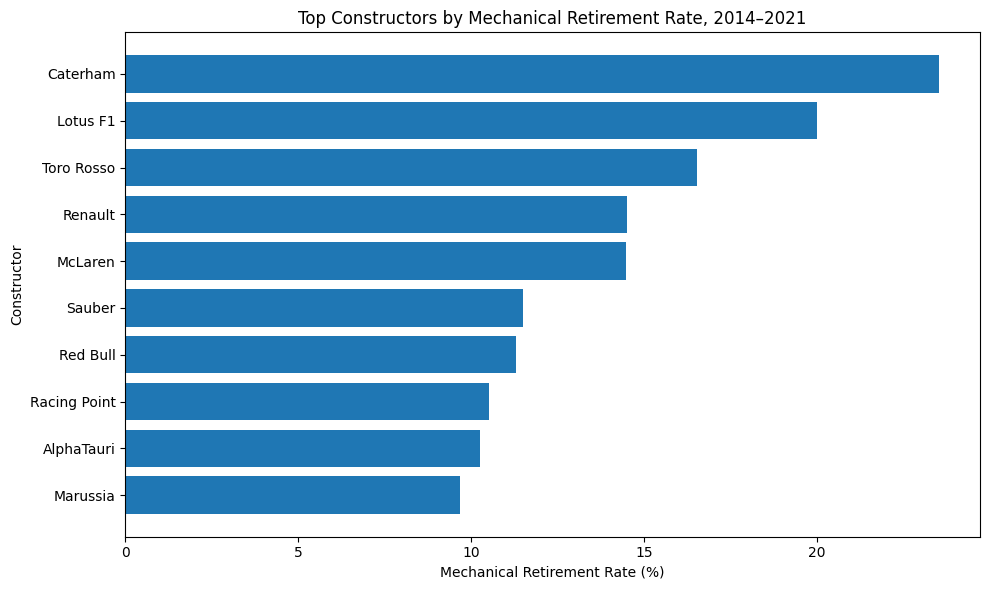

In [ ]:
# ============================================================
# Q3 Visualization: 2014–2021
# ============================================================

plot_2014 = (
    q3_top10_named[
        q3_top10_named["era"] == "2014-2021"
    ]
    .sort_values("mechanical_retirement_rate")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_2014["name"],
    plot_2014["mechanical_retirement_rate"] * 100
)

plt.xlabel("Mechanical Retirement Rate (%)")
plt.ylabel("Constructor")
plt.title(
    "Top Constructors by Mechanical Retirement Rate, 2014–2021"
)

plt.tight_layout()
plt.show()

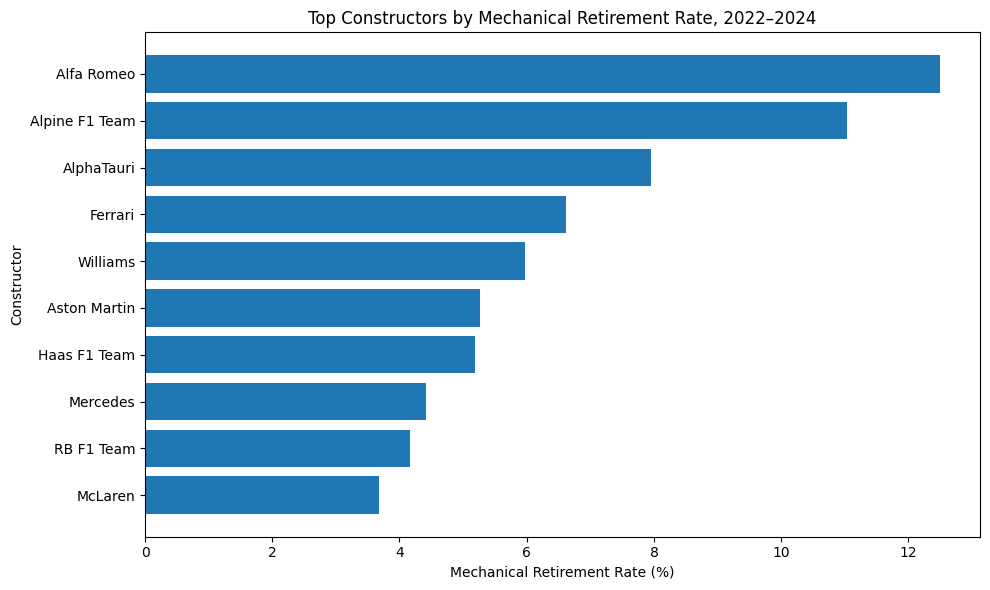

In [ ]:
# ============================================================
# Q3 Visualization: 2022–2024
# ============================================================

plot_2022 = (
    q3_top10_named[
        q3_top10_named["era"] == "2022-2024"
    ]
    .sort_values("mechanical_retirement_rate")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_2022["name"],
    plot_2022["mechanical_retirement_rate"] * 100
)

plt.xlabel("Mechanical Retirement Rate (%)")
plt.ylabel("Constructor")
plt.title(
    "Top Constructors by Mechanical Retirement Rate, 2022–2024"
)

plt.tight_layout()
plt.show()

## Answer to Data-Engineering Question 3

Mechanical-retirement rates differ substantially between the two periods. Among constructors with at least 20 race starts within the corresponding period, Caterham had the highest mechanical-retirement rate in 2014–2021, with 8 mechanical retirements in 34 race starts (23.53%). Lotus F1 ranked second at 20.00%, followed by Toro Rosso at 16.53%.

In 2022–2024, Alfa Romeo had the highest mechanical-retirement rate, with 11 mechanical retirements in 88 race starts (12.50%), followed by Alpine F1 Team at 11.03% and AlphaTauri at 7.95%.

Across all constructors, the aggregate mechanical-retirement count was 330 out of 3,258 race starts in 2014–2021 (10.13%) and 83 out of 1,354 race starts in 2022–2024 (6.13%). This indicates that the overall rate of recorded mechanical retirements was lower in the later period.

A mechanical retirement was defined using explicit component or system failure statuses in the dataset. Crash-related statuses such as Accident, Collision, Collision damage, Damage and Spun off were excluded, as were regulatory outcomes such as Disqualified and Excluded. Generic "Retired" was also excluded because it does not identify the cause of retirement. "Withdrew" was excluded from the race-start denominator because the driver did not start the race.

The analysis uses the race-driver level and joins race year, constructor identity and the status table. The 20-start minimum is applied only when producing the constructor ranking to reduce instability from very small samples; it does not modify the underlying data.

## Data Pre-processing and Feature Engineering Effects

In [ ]:
# ============================================================
# Effect of preprocessing on feature ranges and distributions
# ============================================================

# Feature names in the processed matrix
processed_feature_names = X_train.columns.tolist()

# Create a before/after summary for the training data
before_stats = pd.DataFrame({
    "feature": processed_feature_names,
    "before_mean": X_train.mean().values,
    "before_std": X_train.std().values,
    "before_min": X_train.min().values,
    "before_max": X_train.max().values
})

after_stats = pd.DataFrame({
    "feature": processed_feature_names,
    "after_mean": X_train_processed.mean(axis=0),
    "after_std": X_train_processed.std(axis=0),
    "after_min": X_train_processed.min(axis=0),
    "after_max": X_train_processed.max(axis=0)
})

preprocessing_effect = before_stats.merge(
    after_stats,
    on="feature"
)

display(preprocessing_effect.round(3))

,feature,before_mean,before_std,before_min,before_max,after_mean,after_std,after_min,after_max
0,grid,11.304,6.377,0.000,26.000,0.0,1.0,-1.773,2.305
1,qualifying_position,11.376,6.369,1.000,28.000,0.0,1.0,-1.629,2.610
2,q1_seconds,89.313,15.891,63.807,1002.640,-0.0,1.0,-1.616,57.946
3,q2_seconds,88.981,11.841,63.378,132.470,-0.0,1.0,-3.028,5.145
4,q3_seconds,88.722,12.095,63.003,129.776,-0.0,1.0,-3.793,6.135
5,driver_previous_races,65.731,63.446,0.000,296.000,-0.0,1.0,-1.036,3.630
6,driver_previous_podiums,14.319,25.529,0.000,150.000,0.0,1.0,-0.561,5.315
7,driver_previous_podium_rate,0.135,0.184,0.000,1.000,-0.0,1.0,-0.735,4.699
8,driver_previous_avg_finish,11.530,3.472,1.000,28.000,0.0,1.0,-3.061,4.789
9,driver_previous_5_avg_finish,11.327,4.516,1.000,28.000,0.0,1.0,-2.310,3.726


## Effect of Data Pre-processing

The preprocessing stage had two main effects. First, missing numerical values were filled using median values learned from the training set. Second, the features were standardized using the training-set mean and standard deviation.

Before preprocessing, the feature ranges were substantially different. For example, `grid` ranged from 0 to 26, `driver_previous_races` from 0 to 296, `driver_age` from 17.45 to 43.89, and `alt` from -7 to 2227. After standardization, the training features have approximately zero mean and unit standard deviation.

This puts the numerical features on a comparable scale, which is particularly important for scale-sensitive models such as logistic regression and the shallow neural network. The preprocessing does not remove observations or alter the target variable.

A large standardized value remains for `q1_seconds` because the training data contain a historical Q1 value of 1002.64 seconds. This observation was retained because the original value is valid according to the recorded data; preprocessing only rescales it.

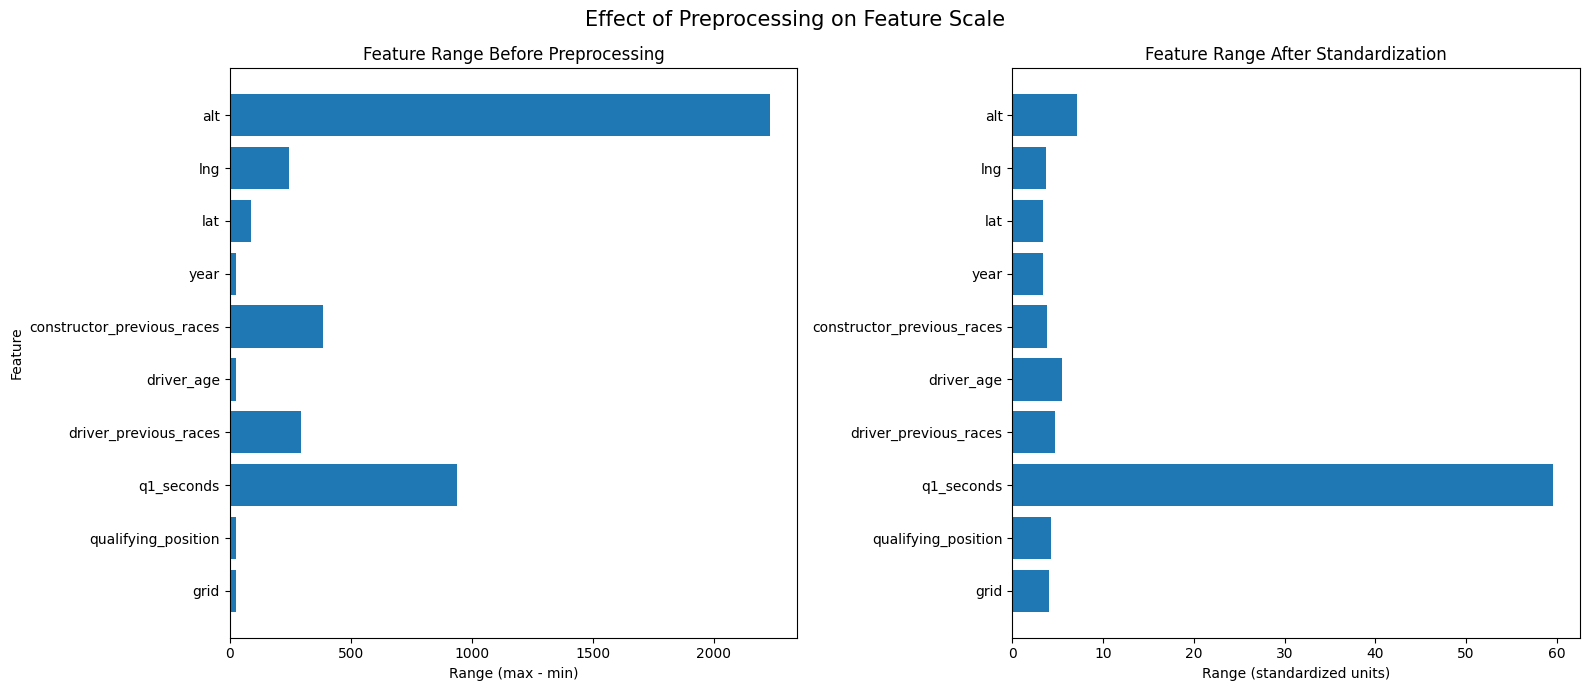

In [ ]:
# ============================================================
# Visualize the effect of standardization on feature ranges
# ============================================================

selected_features = [
    "grid",
    "qualifying_position",
    "q1_seconds",
    "driver_previous_races",
    "driver_age",
    "constructor_previous_races",
    "year",
    "lat",
    "lng",
    "alt"
]

before_ranges = (
    X_train[selected_features]
    .agg(["min", "max"])
    .T
)

after_ranges = pd.DataFrame({
    "min": X_train_processed[
        :, [X_train.columns.get_loc(f) for f in selected_features]
    ].min(axis=0),
    "max": X_train_processed[
        :, [X_train.columns.get_loc(f) for f in selected_features]
    ].max(axis=0)
}, index=selected_features)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7)
)

# Before preprocessing
axes[0].barh(
    before_ranges.index,
    before_ranges["max"] - before_ranges["min"]
)

axes[0].set_title("Feature Range Before Preprocessing")
axes[0].set_xlabel("Range (max - min)")
axes[0].set_ylabel("Feature")

# After preprocessing
axes[1].barh(
    after_ranges.index,
    after_ranges["max"] - after_ranges["min"]
)

axes[1].set_title("Feature Range After Standardization")
axes[1].set_xlabel("Range (standardized units)")
axes[1].set_ylabel("")

fig.suptitle(
    "Effect of Preprocessing on Feature Scale",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Effect of Pre-processing on Feature Scale

Before preprocessing, the candidate features were measured on substantially different numerical scales. For example, altitude ranged from -7 to 2227, while historical podium rates ranged from 0 to 1. Qualifying times, driver history counts, and geographic coordinates also had different ranges.

After median imputation and standardization, the training features have approximately zero mean and unit standard deviation. This places the features on comparable scales and is particularly useful for scale-sensitive models such as logistic regression and the shallow neural network.

The preprocessing does not remove observations or modify the target variable. The unusually large standardized range of `q1_seconds` is caused by a historical extreme value that was retained because it is present in the original data.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# ============================================================
# Experiment A: Imputation → Standardization
# ============================================================

pipeline_impute_scale = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

pipeline_impute_scale.fit(
    X_train,
    y_train
)

pred_a = pipeline_impute_scale.predict_proba(
    X_validation
)[:, 1]

class_a = (pred_a >= 0.5).astype(int)


# ============================================================
# Experiment B: Standardization → Imputation
# ============================================================

pipeline_scale_impute = Pipeline([
    ("scaler", StandardScaler()),
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

pipeline_scale_impute.fit(
    X_train,
    y_train
)

pred_b = pipeline_scale_impute.predict_proba(
    X_validation
)[:, 1]

class_b = (pred_b >= 0.5).astype(int)


# ============================================================
# Compare validation performance
# ============================================================

results_preprocessing = pd.DataFrame({
    "Preprocessing Order": [
        "Imputation → Standardization",
        "Standardization → Imputation"
    ],
    "ROC-AUC": [
        roc_auc_score(y_validation, pred_a),
        roc_auc_score(y_validation, pred_b)
    ],
    "PR-AUC": [
        average_precision_score(y_validation, pred_a),
        average_precision_score(y_validation, pred_b)
    ],
    "F1": [
        f1_score(y_validation, class_a),
        f1_score(y_validation, class_b)
    ]
})

display(
    results_preprocessing.round(4)
)

,Preprocessing Order,ROC-AUC,PR-AUC,F1
0,Imputation → Standardization,0.9282,0.7217,0.6379
1,Standardization → Imputation,0.9282,0.7217,0.6358


## Pre-processing Order Experiment

Two preprocessing orders were compared using the same features, training set, validation set, and Logistic Regression model.

The first experiment applied median imputation followed by standardization. The second applied standardization followed by median imputation.

The two approaches produced almost identical ROC-AUC and PR-AUC values (0.9282 and 0.7217 respectively). The F1-score was also very similar, with 0.6379 for imputation followed by standardization and 0.6358 for standardization followed by imputation.

Therefore, the performance difference is negligible for this dataset. We select **Imputation → Standardization** as the main preprocessing order because it provides a straightforward and interpretable preprocessing sequence.

## Predictive Modeling

## Model Methods and Limitations

### Logistic Regression

Logistic Regression is the statistical baseline. It models the probability of a podium finish
using a linear combination of the standardized input features and applies the logistic function
to obtain a value between 0 and 1. Its main limitation is that it cannot directly represent
complex nonlinear interactions without additional feature engineering.

### Random Forest

Random Forest combines many decision trees trained on resampled data and randomized feature
subsets. It can capture nonlinear relationships and interactions without requiring a linear
decision boundary. Its main limitation in this experiment is overfitting: the training scores
are much higher than validation scores, so the model does not generalize as consistently as the
simpler approaches.

### Shallow Feed-Forward Neural Network

The final neural network uses the architecture **29 → 32 → 16 → 1**, with ReLU activations in
the hidden layers and a sigmoid output for binary podium probability. It can learn nonlinear
relationships while remaining shallow enough to satisfy the milestone requirement. Its main
limitations are lower interpretability than Logistic Regression and sensitivity to the chosen
training setup and historical/era distribution.

All three models use the same 29-feature modeling table and chronological train/validation/test
split. Model thresholds are selected using validation data only.


In [ ]:
from sklearn.linear_model import LogisticRegression

# ============================================================
# Logistic Regression Baseline
# ============================================================

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

# Train using the selected preprocessing:
# Imputation → Standardization
X_train_main = preprocessor.fit_transform(X_train)
X_validation_main = preprocessor.transform(X_validation)
X_test_main = preprocessor.transform(X_test)

logistic_model.fit(
    X_train_main,
    y_train
)

# Probabilities
y_train_proba_lr = logistic_model.predict_proba(
    X_train_main
)[:, 1]

y_validation_proba_lr = logistic_model.predict_proba(
    X_validation_main
)[:, 1]

# Default 0.5 threshold for now
y_train_pred_lr = (
    y_train_proba_lr >= 0.5
).astype(int)

y_validation_pred_lr = (
    y_validation_proba_lr >= 0.5
).astype(int)

print("Logistic Regression trained successfully.")

print("\nPrediction ranges:")
print(
    "Train:",
    y_train_proba_lr.min(),
    "to",
    y_train_proba_lr.max()
)

print(
    "Validation:",
    y_validation_proba_lr.min(),
    "to",
    y_validation_proba_lr.max()
)

Logistic Regression trained successfully.

Prediction ranges:
Train: 0.0006714197742692461 to 0.9967290212967295
Validation: 0.003975347676504951 to 0.9882392999227291


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score
)

# ============================================================
# Logistic Regression: Training and Validation Performance
# ============================================================

# -------------------------
# Training metrics
# -------------------------

train_roc_auc_lr = roc_auc_score(
    y_train,
    y_train_proba_lr
)

train_pr_auc_lr = average_precision_score(
    y_train,
    y_train_proba_lr
)

train_f1_lr = f1_score(
    y_train,
    y_train_pred_lr
)


# -------------------------
# Validation metrics
# -------------------------

validation_roc_auc_lr = roc_auc_score(
    y_validation,
    y_validation_proba_lr
)

validation_pr_auc_lr = average_precision_score(
    y_validation,
    y_validation_proba_lr
)

validation_f1_lr = f1_score(
    y_validation,
    y_validation_pred_lr
)


# -------------------------
# Display results
# -------------------------

logistic_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation"
    ],
    "ROC-AUC": [
        train_roc_auc_lr,
        validation_roc_auc_lr
    ],
    "PR-AUC": [
        train_pr_auc_lr,
        validation_pr_auc_lr
    ],
    "F1": [
        train_f1_lr,
        validation_f1_lr
    ]
})

display(
    logistic_results.round(4)
)

,Dataset,ROC-AUC,PR-AUC,F1
0,Training,0.9212,0.6235,0.5936
1,Validation,0.9282,0.7217,0.6379


## Logistic Regression Baseline Results

Logistic Regression provides the statistical baseline for the podium prediction task. Using the initial 0.5 probability threshold, the model achieved a ROC-AUC of 0.9212, PR-AUC of 0.6235, and F1-score of 0.5936 on the training data. On the validation data, it achieved a ROC-AUC of 0.9282, PR-AUC of 0.7217, and F1-score of 0.6379.

The validation performance is slightly higher than the training performance across all three metrics, so there is no clear evidence of overfitting from this comparison. The difference may reflect variation between the historical training seasons and the 2020–2021 validation seasons. The test set is kept untouched at this stage and will only be used after model and threshold decisions are finalized.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Random Forest Model
# ============================================================

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train only on the training data
random_forest_model.fit(
    X_train_main,
    y_train
)

# Probability predictions
y_train_proba_rf = random_forest_model.predict_proba(
    X_train_main
)[:, 1]

y_validation_proba_rf = random_forest_model.predict_proba(
    X_validation_main
)[:, 1]

# Initial threshold = 0.5
y_train_pred_rf = (
    y_train_proba_rf >= 0.5
).astype(int)

y_validation_pred_rf = (
    y_validation_proba_rf >= 0.5
).astype(int)

print("Random Forest trained successfully.")

print("\nPrediction ranges:")
print(
    "Train:",
    y_train_proba_rf.min(),
    "to",
    y_train_proba_rf.max()
)

print(
    "Validation:",
    y_validation_proba_rf.min(),
    "to",
    y_validation_proba_rf.max()
)

Random Forest trained successfully.

Prediction ranges:
Train: 0.0 to 0.9972989976316584
Validation: 0.0 to 0.8341782549215331


In [ ]:
# ============================================================
# Random Forest: Training and Validation Performance
# ============================================================

# Training metrics
train_roc_auc_rf = roc_auc_score(
    y_train,
    y_train_proba_rf
)

train_pr_auc_rf = average_precision_score(
    y_train,
    y_train_proba_rf
)

train_f1_rf = f1_score(
    y_train,
    y_train_pred_rf
)

# Validation metrics
validation_roc_auc_rf = roc_auc_score(
    y_validation,
    y_validation_proba_rf
)

validation_pr_auc_rf = average_precision_score(
    y_validation,
    y_validation_proba_rf
)

validation_f1_rf = f1_score(
    y_validation,
    y_validation_pred_rf
)

# Results table
random_forest_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation"
    ],
    "ROC-AUC": [
        train_roc_auc_rf,
        validation_roc_auc_rf
    ],
    "PR-AUC": [
        train_pr_auc_rf,
        validation_pr_auc_rf
    ],
    "F1": [
        train_f1_rf,
        validation_f1_rf
    ]
})

display(
    random_forest_results.round(4)
)

,Dataset,ROC-AUC,PR-AUC,F1
0,Training,0.9993,0.9953,0.9611
1,Validation,0.9180,0.6877,0.6887


## Random Forest Results

The Random Forest achieves extremely strong performance on the training data, with ROC-AUC = 0.9993, PR-AUC = 0.9953, and F1 = 0.9611. However, its validation performance drops to ROC-AUC = 0.9180, PR-AUC = 0.6877, and F1 = 0.6887. The large gap between training and validation indicates substantial overfitting.

Despite this overfitting, the Random Forest achieves a higher validation F1-score than Logistic Regression (0.6887 vs. 0.6379). However, Logistic Regression has higher validation ROC-AUC and PR-AUC (0.9282 and 0.7217), indicating stronger overall probability ranking and positive-class ranking performance.

In [ ]:
# ============================================================
# Initial model comparison
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Validation ROC-AUC": [
        validation_roc_auc_lr,
        validation_roc_auc_rf
    ],
    "Validation PR-AUC": [
        validation_pr_auc_lr,
        validation_pr_auc_rf
    ],
    "Validation F1": [
        validation_f1_lr,
        validation_f1_rf
    ]
})

display(
    model_comparison.round(4)
)

,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1
0,Logistic Regression,0.9282,0.7217,0.6379
1,Random Forest,0.9180,0.6877,0.6887


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ============================================================
# Shallow Feed-Forward Neural Network
# ============================================================

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

ffnn_model = keras.Sequential([
    layers.Input(shape=(X_train_main.shape[1],)),

    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

ffnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="roc_auc"),
        keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

# Give more importance to the minority podium class.
class_weights = {
    0: 1.0,
    1: len(y_train[y_train == 0]) / len(y_train[y_train == 1])
}

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_ffnn = ffnn_model.fit(
    X_train_main,
    y_train,
    validation_data=(
        X_validation_main,
        y_validation
    ),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

print("\nShallow FFNN trained successfully.")
print("Epochs actually used:", len(history_ffnn.history["loss"]))

Epoch 1/100


2026-10-05 20:15:29.284112: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7292 - pr_auc: 0.5575 - roc_auc: 0.8915 - val_loss: 0.3277 - val_pr_auc: 0.6638 - val_roc_auc: 0.9200
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6196 - pr_auc: 0.6161 - roc_auc: 0.9171 - val_loss: 0.3110 - val_pr_auc: 0.7155 - val_roc_auc: 0.9257
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5990 - pr_auc: 0.6394 - roc_auc: 0.9224 - val_loss: 0.3061 - val_pr_auc: 0.7255 - val_roc_auc: 0.9277
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5878 - pr_auc: 0.6507 - roc_auc: 0.9252 - val_loss: 0.3065 - val_pr_auc: 0.7327 - val_roc_auc: 0.9283
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5805 - pr_auc: 0.6570 - roc_auc: 0.9270 - val_loss: 0.3018 - val_pr_auc: 0.7317 - val_roc_auc: 0.9288
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5749 - pr_auc: 0.6590 - roc_auc: 0.9283 - val_loss: 0.2988 - val_pr_auc: 0.7308 - val_roc_auc: 0.9295
Epoch 7/100
262/262 ━━

In [ ]:
# ============================================================
# Evaluate Shallow FFNN
# ============================================================

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# Predicted probabilities
ffnn_train_proba = ffnn_model.predict(
    X_train_main,
    verbose=0
).ravel()

ffnn_validation_proba = ffnn_model.predict(
    X_validation_main,
    verbose=0
).ravel()

# Default classification threshold
ffnn_train_pred = (ffnn_train_proba >= 0.5).astype(int)
ffnn_validation_pred = (ffnn_validation_proba >= 0.5).astype(int)

# Metrics
train_roc_auc_ffnn = roc_auc_score(
    y_train,
    ffnn_train_proba
)

train_pr_auc_ffnn = average_precision_score(
    y_train,
    ffnn_train_proba
)

train_f1_ffnn = f1_score(
    y_train,
    ffnn_train_pred
)

validation_roc_auc_ffnn = roc_auc_score(
    y_validation,
    ffnn_validation_proba
)

validation_pr_auc_ffnn = average_precision_score(
    y_validation,
    ffnn_validation_proba
)

validation_f1_ffnn = f1_score(
    y_validation,
    ffnn_validation_pred
)

# Display results
ffnn_results = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "F1"
    ],
    "Training": [
        train_roc_auc_ffnn,
        train_pr_auc_ffnn,
        train_f1_ffnn
    ],
    "Validation": [
        validation_roc_auc_ffnn,
        validation_pr_auc_ffnn,
        validation_f1_ffnn
    ]
})

display(ffnn_results.round(4))

print("\nFFNN probability ranges:")
print(
    f"Training:   {ffnn_train_proba.min():.4f} to {ffnn_train_proba.max():.4f}"
)
print(
    f"Validation: {ffnn_validation_proba.min():.4f} to {ffnn_validation_proba.max():.4f}"
)

,Metric,Training,Validation
0,ROC-AUC,0.9408,0.9298
1,PR-AUC,0.6987,0.7398
2,F1,0.6311,0.6917



FFNN probability ranges:
Training:   0.0000 to 0.9952
Validation: 0.0000 to 0.9926


In [ ]:
# ============================================================
# Final Validation Comparison: All Three Models
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Shallow FFNN"
    ],
    "Validation ROC-AUC": [
        validation_roc_auc_lr,
        validation_roc_auc_rf,
        validation_roc_auc_ffnn
    ],
    "Validation PR-AUC": [
        validation_pr_auc_lr,
        validation_pr_auc_rf,
        validation_pr_auc_ffnn
    ],
    "Validation F1": [
        validation_f1_lr,
        validation_f1_rf,
        validation_f1_ffnn
    ]
})

display(
    model_comparison
    .sort_values("Validation PR-AUC", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1
0,Shallow FFNN,0.9298,0.7398,0.6917
1,Logistic Regression,0.9282,0.7217,0.6379
2,Random Forest,0.9180,0.6877,0.6887


## Validation-Based Threshold Selection

In [ ]:
# ============================================================
# Fair Threshold Tuning for All Three Models
# Validation Set Only
# ============================================================

def find_best_f1_threshold(y_true, probabilities):
    thresholds = np.arange(0.05, 0.96, 0.01)

    results = []

    for threshold in thresholds:
        predictions = (
            probabilities >= threshold
        ).astype(int)

        f1 = f1_score(
            y_true,
            predictions
        )

        results.append({
            "Threshold": threshold,
            "F1": f1
        })

    results_df = pd.DataFrame(results)

    best_row = results_df.loc[
        results_df["F1"].idxmax()
    ]

    return (
        float(best_row["Threshold"]),
        float(best_row["F1"]),
        results_df
    )


# ------------------------------------------------------------
# Get validation probabilities for all models
# ------------------------------------------------------------

lr_validation_proba = logistic_model.predict_proba(
    X_validation_main
)[:, 1]

rf_validation_proba = random_forest_model.predict_proba(
    X_validation_main
)[:, 1]

# FFNN probability already exists:
# ffnn_validation_proba


# ------------------------------------------------------------
# Tune each model independently using validation only
# ------------------------------------------------------------

best_threshold_lr, best_validation_f1_lr, lr_threshold_results = (
    find_best_f1_threshold(
        y_validation,
        lr_validation_proba
    )
)

best_threshold_rf, best_validation_f1_rf, rf_threshold_results = (
    find_best_f1_threshold(
        y_validation,
        rf_validation_proba
    )
)

best_threshold_ffnn, best_validation_f1_ffnn, ffnn_threshold_results = (
    find_best_f1_threshold(
        y_validation,
        ffnn_validation_proba
    )
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

threshold_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Shallow FFNN"
    ],
    "Selected Validation Threshold": [
        best_threshold_lr,
        best_threshold_rf,
        best_threshold_ffnn
    ],
    "Best Validation F1": [
        best_validation_f1_lr,
        best_validation_f1_rf,
        best_validation_f1_ffnn
    ]
})

display(
    threshold_comparison.round(4)
)

,Model,Selected Validation Threshold,Best Validation F1
0,Logistic Regression,0.73,0.7069
1,Random Forest,0.43,0.6909
2,Shallow FFNN,0.53,0.7027


## Training and Validation Performance

For the checklist requirement on training and validation performance, the following table
reports all three metrics for every model. F1 uses the threshold selected from the validation set,
so the comparison is consistent with the final threshold-selection procedure.


In [ ]:
# ============================================================
# Training + validation performance with validation-selected F1 thresholds
# ============================================================

train_f1_lr_selected = f1_score(
    y_train,
    (y_train_proba_lr >= best_threshold_lr).astype(int)
)

train_f1_rf_selected = f1_score(
    y_train,
    (y_train_proba_rf >= best_threshold_rf).astype(int)
)

train_f1_ffnn_selected = f1_score(
    y_train,
    (ffnn_train_proba >= best_threshold_ffnn).astype(int)
)

training_validation_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Shallow FFNN"
    ],
    "Train ROC-AUC": [
        roc_auc_score(y_train, y_train_proba_lr),
        roc_auc_score(y_train, y_train_proba_rf),
        roc_auc_score(y_train, ffnn_train_proba)
    ],
    "Train PR-AUC": [
        average_precision_score(y_train, y_train_proba_lr),
        average_precision_score(y_train, y_train_proba_rf),
        average_precision_score(y_train, ffnn_train_proba)
    ],
    "Train F1": [
        train_f1_lr_selected,
        train_f1_rf_selected,
        train_f1_ffnn_selected
    ],
    "Validation ROC-AUC": [
        validation_roc_auc_lr,
        validation_roc_auc_rf,
        validation_roc_auc_ffnn
    ],
    "Validation PR-AUC": [
        validation_pr_auc_lr,
        validation_pr_auc_rf,
        validation_pr_auc_ffnn
    ],
    "Validation F1": [
        best_validation_f1_lr,
        best_validation_f1_rf,
        best_validation_f1_ffnn
    ],
})

display(training_validation_comparison.round(4))


In [ ]:
# ============================================================
# Feature-Group Ablation Experiment
# ============================================================

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Define feature groups
# ------------------------------------------------------------

feature_groups = {
    "Qualifying": [
        "qualifying_position",
        "q1_seconds",
        "q2_seconds",
        "q3_seconds",
        "q1_missing",
        "q2_missing",
        "q3_missing"
    ],

    "Grid": [
        "grid"
    ],

    "Driver Form": [
        "driver_previous_races",
        "driver_previous_podiums",
        "driver_previous_podium_rate",
        "driver_previous_avg_finish",
        "driver_previous_5_avg_finish",
        "driver_has_history"
    ],

    "Constructor Form": [
        "constructor_previous_races",
        "constructor_previous_podiums",
        "constructor_previous_podium_rate",
        "constructor_has_history"
    ],

    "Driver-Constructor Form": [
        "driver_constructor_previous_races",
        "driver_constructor_previous_podiums",
        "driver_constructor_previous_podium_rate",
        "driver_constructor_has_history"
    ],

    "Context": [
        "driver_age",
        "year",
        "round",
        "home_race",
        "lat",
        "lng",
        "alt"
    ]
}

# Check that every feature belongs to exactly one group
grouped_features = [
    feature
    for group in feature_groups.values()
    for feature in group
]

print("Total model features:", len(feature_columns) + 3)
print("Features assigned to groups:", len(grouped_features))

assert set(grouped_features) == set(X_train.columns), \
    "Some features are missing from or duplicated in the groups."

# ------------------------------------------------------------
# Helper function for training one ablation model
# ------------------------------------------------------------

def train_ablation_ffnn(X_tr, y_tr, X_val, y_val, input_dim):

    # Fit preprocessing ONLY on the training data
    ablation_preprocessor = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    X_tr_processed = ablation_preprocessor.fit_transform(X_tr)
    X_val_processed = ablation_preprocessor.transform(X_val)

    # Same shallow architecture as the main FFNN
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(name="roc_auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_tr_processed,
        y_tr,
        validation_data=(X_val_processed, y_val),
        epochs=100,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stopping],
        verbose=0
    )

    # Validation probabilities
    val_proba = model.predict(
        X_val_processed,
        verbose=0
    ).ravel()

    val_pred = (
        val_proba >= best_threshold_ffnn
    ).astype(int)

    return {
        "ROC-AUC": roc_auc_score(y_val, val_proba),
        "PR-AUC": average_precision_score(y_val, val_proba),
        "F1": f1_score(y_val, val_pred)
    }


# ------------------------------------------------------------
# Full model reference
# ------------------------------------------------------------

ablation_results = [{
    "Experiment": "Full Model",
    "Removed Group": "None",
    "Remaining Features": len(X_train.columns),
    "Validation ROC-AUC": validation_roc_auc_ffnn,
    "Validation PR-AUC": validation_pr_auc_ffnn,
    "Validation F1": best_validation_f1_ffnn
}]

# ------------------------------------------------------------
# Remove one group at a time
# ------------------------------------------------------------

for group_name, group_features in feature_groups.items():

    remaining_features = [
        col for col in X_train.columns
        if col not in group_features
    ]

    print(f"Training ablation: remove {group_name}...")

    metrics = train_ablation_ffnn(
        X_train[remaining_features],
        y_train,
        X_validation[remaining_features],
        y_validation,
        input_dim=len(remaining_features)
    )

    ablation_results.append({
        "Experiment": f"Without {group_name}",
        "Removed Group": group_name,
        "Remaining Features": len(remaining_features),
        "Validation ROC-AUC": metrics["ROC-AUC"],
        "Validation PR-AUC": metrics["PR-AUC"],
        "Validation F1": metrics["F1"]
    })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

ablation_results_df = pd.DataFrame(ablation_results)

ablation_results_df["PR-AUC Drop"] = (
    validation_pr_auc_ffnn -
    ablation_results_df["Validation PR-AUC"]
)

ablation_results_df["F1 Drop"] = (
    best_validation_f1_ffnn -
    ablation_results_df["Validation F1"]
)

display(
    ablation_results_df.round(4)
)

Total model features: 29
Features assigned to groups: 29
Training ablation: remove Qualifying...
Training ablation: remove Grid...
Training ablation: remove Driver Form...
Training ablation: remove Constructor Form...
Training ablation: remove Driver-Constructor Form...
Training ablation: remove Context...


,Experiment,Removed Group,Remaining Features,Validation ROC-AUC,Validation PR-AUC,Validation F1,PR-AUC Drop,F1 Drop
0,Full Model,None,29,0.9298,0.7398,0.7027,0.0000,0.0000
1,Without Qualifying,Qualifying,22,0.9173,0.7119,0.6364,0.0279,0.0663
2,Without Grid,Grid,28,0.9223,0.7187,0.6667,0.0211,0.0360
3,Without Driver Form,Driver Form,23,0.9175,0.7190,0.6846,0.0207,0.0181
4,Without Constructor Form,Constructor Form,25,0.9170,0.7044,0.6543,0.0353,0.0484
5,Without Driver-Constructor Form,Driver-Constructor Form,25,0.9252,0.7071,0.6935,0.0327,0.0092
6,Without Context,Context,22,0.9260,0.7310,0.6827,0.0087,0.0200


### Feature-Group Ablation Results

Feature-group ablation was performed by removing one feature group at a time,
retraining the same shallow FFNN architecture, and evaluating on the validation set.
The full model achieved a PR-AUC of 0.7398 and an F1-score of 0.7027.

The largest PR-AUC decrease occurred when **Constructor Form** was removed
(−0.0353), followed by **Driver-Constructor Form** (−0.0327), **Qualifying**
(−0.0279), **Grid** (−0.0211), and **Driver Form** (−0.0207).

Removing **Qualifying** produced the largest F1 decrease (−0.0663), indicating
that qualifying-related information is particularly important for the final
classification decision.

Removing the **Context** group produced the smallest PR-AUC decrease (−0.0087),
suggesting that contextual features provide additional information but contribute
less than the main form, grid, and qualifying groups in this experiment.

These results support retaining all feature groups in the final model. The
ablation measures predictive contribution only; it does not establish causal
effects.

## Final Model Selection and Unseen Test Evaluation

In [ ]:
# ============================================================
# Final evaluation on the unseen 2022–2024 test set
# ============================================================

# Generate test probabilities after all model/threshold decisions
# have been finalized using training and validation only.
lr_test_proba = logistic_model.predict_proba(
    X_test_main
)[:, 1]

rf_test_proba = random_forest_model.predict_proba(
    X_test_main
)[:, 1]

ffnn_test_proba = ffnn_model.predict(
    X_test_main,
    verbose=0
).ravel()

# Apply the validation-selected threshold for each model.
lr_test_pred_tuned = (
    lr_test_proba >= best_threshold_lr
).astype(int)

rf_test_pred_tuned = (
    rf_test_proba >= best_threshold_rf
).astype(int)

ffnn_test_pred_tuned = (
    ffnn_test_proba >= best_threshold_ffnn
).astype(int)

# Test metrics
test_roc_auc_lr = roc_auc_score(y_test, lr_test_proba)
test_pr_auc_lr = average_precision_score(y_test, lr_test_proba)
test_f1_lr_tuned = f1_score(y_test, lr_test_pred_tuned)

test_roc_auc_rf = roc_auc_score(y_test, rf_test_proba)
test_pr_auc_rf = average_precision_score(y_test, rf_test_proba)
test_f1_rf_tuned = f1_score(y_test, rf_test_pred_tuned)

test_roc_auc_ffnn = roc_auc_score(y_test, ffnn_test_proba)
test_pr_auc_ffnn = average_precision_score(y_test, ffnn_test_proba)
test_f1_ffnn_tuned = f1_score(y_test, ffnn_test_pred_tuned)

final_fair_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Shallow FFNN"
    ],
    "Validation ROC-AUC": [
        validation_roc_auc_lr,
        validation_roc_auc_rf,
        validation_roc_auc_ffnn
    ],
    "Validation PR-AUC": [
        validation_pr_auc_lr,
        validation_pr_auc_rf,
        validation_pr_auc_ffnn
    ],
    "Validation F1": [
        best_validation_f1_lr,
        best_validation_f1_rf,
        best_validation_f1_ffnn
    ],
    "Selected Threshold": [
        best_threshold_lr,
        best_threshold_rf,
        best_threshold_ffnn
    ],
    "Test ROC-AUC": [
        test_roc_auc_lr,
        test_roc_auc_rf,
        test_roc_auc_ffnn
    ],
    "Test PR-AUC": [
        test_pr_auc_lr,
        test_pr_auc_rf,
        test_pr_auc_ffnn
    ],
    "Test F1": [
        test_f1_lr_tuned,
        test_f1_rf_tuned,
        test_f1_ffnn_tuned
    ]
})

display(final_fair_comparison.round(4))

### Final Model Selection

PR-AUC was selected as the primary metric because podium finishes are the
minority class. F1 was selected as the secondary metric because it evaluates
the final binary podium/non-podium decision at a chosen threshold.

The Shallow FFNN was selected as the final model based on the validation set,
where it achieved the highest ROC-AUC (0.9298) and PR-AUC (0.7398). Logistic
Regression achieved the highest threshold-tuned validation F1 (0.7069), while
the FFNN achieved 0.7027.

The final FFNN threshold is **0.53**, selected using validation data only.
On the unseen 2022–2024 test set, the final FFNN achieved ROC-AUC = 0.9131,
PR-AUC = 0.5748, and F1 = 0.6203.

The test set was not used to select models or thresholds.

In [ ]:
# ============================================================
# Final Model Performance Comparison
# ============================================================

plot_data = final_fair_comparison.copy()
x = np.arange(len(plot_data))
width = 0.25

plt.figure(figsize=(11, 6))
plt.bar(x - width, plot_data["Validation ROC-AUC"], width, label="ROC-AUC")
plt.bar(x, plot_data["Validation PR-AUC"], width, label="PR-AUC")
plt.bar(x + width, plot_data["Validation F1"], width, label="F1")
plt.xticks(x, plot_data["Model"], rotation=15)
plt.ylabel("Validation Score")
plt.ylim(0, 1)
plt.title("Final Model Comparison on Validation Set")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
plt.bar(x - width, plot_data["Test ROC-AUC"], width, label="ROC-AUC")
plt.bar(x, plot_data["Test PR-AUC"], width, label="PR-AUC")
plt.bar(x + width, plot_data["Test F1"], width, label="F1")
plt.xticks(x, plot_data["Model"], rotation=15)
plt.ylabel("Test Score")
plt.ylim(0, 1)
plt.title("Final Model Comparison on Unseen Test Set")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Model Explainability (XAI)

In [ ]:
# ============================================================
# XAI — Permutation Importance
# Using the final Shallow FFNN and validation data
# ============================================================

from sklearn.metrics import average_precision_score

# Use the already processed validation data.
X_val_xai = X_validation_main.copy()

# Baseline validation PR-AUC
baseline_pr_auc = average_precision_score(
    y_validation,
    ffnn_model.predict(X_val_xai, verbose=0).ravel()
)

permutation_results = []

rng = np.random.RandomState(42)

for feature_idx, feature_name in enumerate(X_train.columns):

    drops = []

    for _ in range(5):
        X_permuted = X_val_xai.copy()

        # Shuffle only this feature
        shuffled_values = X_permuted[:, feature_idx].copy()
        rng.shuffle(shuffled_values)
        X_permuted[:, feature_idx] = shuffled_values

        permuted_proba = ffnn_model.predict(
            X_permuted,
            verbose=0
        ).ravel()

        permuted_pr_auc = average_precision_score(
            y_validation,
            permuted_proba
        )

        drops.append(
            baseline_pr_auc - permuted_pr_auc
        )

    permutation_results.append({
        "Feature": feature_name,
        "Mean PR-AUC Drop": np.mean(drops),
        "Std PR-AUC Drop": np.std(drops)
    })

permutation_importance_df = (
    pd.DataFrame(permutation_results)
    .sort_values("Mean PR-AUC Drop", ascending=False)
    .reset_index(drop=True)
)

display(
    permutation_importance_df.head(15).round(4)
)

,Feature,Mean PR-AUC Drop,Std PR-AUC Drop
0,grid,0.0991,0.0254
1,driver_previous_podiums,0.0990,0.0199
2,qualifying_position,0.0940,0.0132
3,driver_constructor_previous_podiums,0.0349,0.0168
4,q2_seconds,0.0231,0.0137
5,driver_age,0.0129,0.0058
6,alt,0.0093,0.0031
7,constructor_previous_podiums,0.0084,0.0061
8,driver_previous_5_avg_finish,0.0050,0.0139
9,driver_previous_avg_finish,0.0044,0.0071


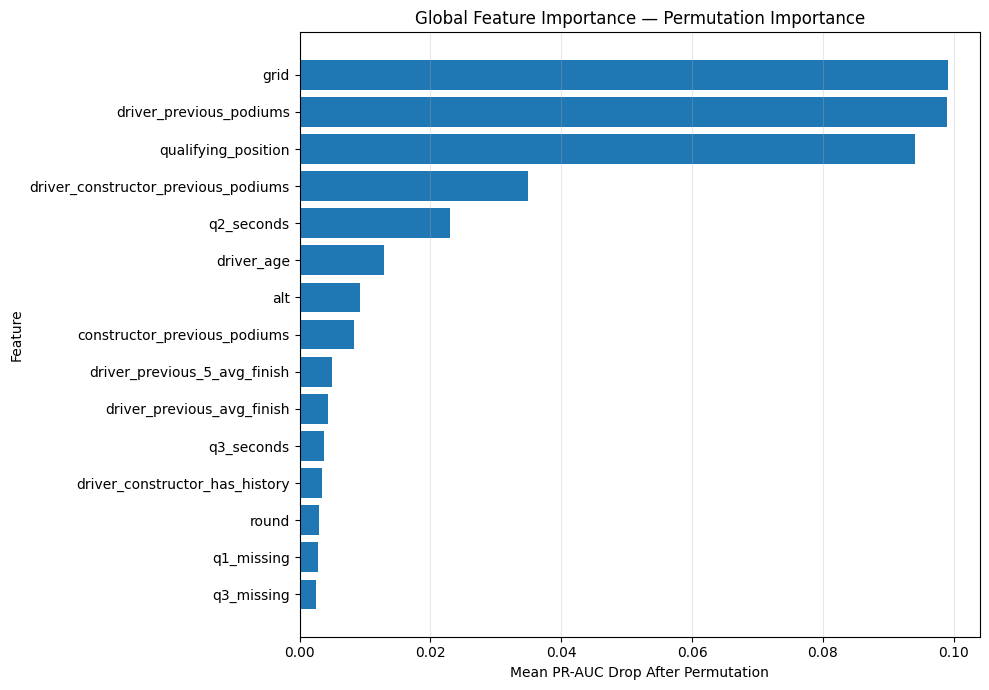

In [ ]:
# ============================================================
# XAI — Global Permutation Importance Plot
# ============================================================

top_n = 15

plot_df = (
    permutation_importance_df
    .head(top_n)
    .sort_values("Mean PR-AUC Drop", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["Feature"],
    plot_df["Mean PR-AUC Drop"]
)

plt.xlabel("Mean PR-AUC Drop After Permutation")
plt.ylabel("Feature")
plt.title(
    "Global Feature Importance — Permutation Importance"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Global Explanation — Permutation Importance

Permutation importance was calculated on the validation set using PR-AUC as the
evaluation measure. A feature is considered important when randomly shuffling its
values causes a decrease in the model's PR-AUC.

The largest observed decrease came from **grid position**, followed closely by
**driver previous podiums** and **qualifying position**. This indicates that the
final FFNN relies strongly on starting position and historical driver performance
when distinguishing podium from non-podium outcomes.

**Driver-constructor previous podiums** and **Q2 qualifying time** were also among
the more influential individual features.

These importance values describe how much the trained model relies on each feature
for prediction. They should not be interpreted as causal effects: a high
permutation importance does not prove that the feature causes a podium finish.

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 29))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 29))']
  warnings.warn(msg)


SHAP values shape: (200, 29)
Feature matrix shape: (200, 29)


,Feature,Mean Absolute SHAP
0,qualifying_position,0.1196
1,grid,0.1047
2,year,0.0566
3,driver_previous_podiums,0.0511
4,driver_previous_podium_rate,0.0459
5,driver_previous_5_avg_finish,0.0409
6,constructor_previous_podiums,0.0384
7,driver_age,0.0376
8,constructor_previous_podium_rate,0.0366
9,driver_previous_avg_finish,0.0258


/tmp/ipykernel_48/888577274.py:82: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


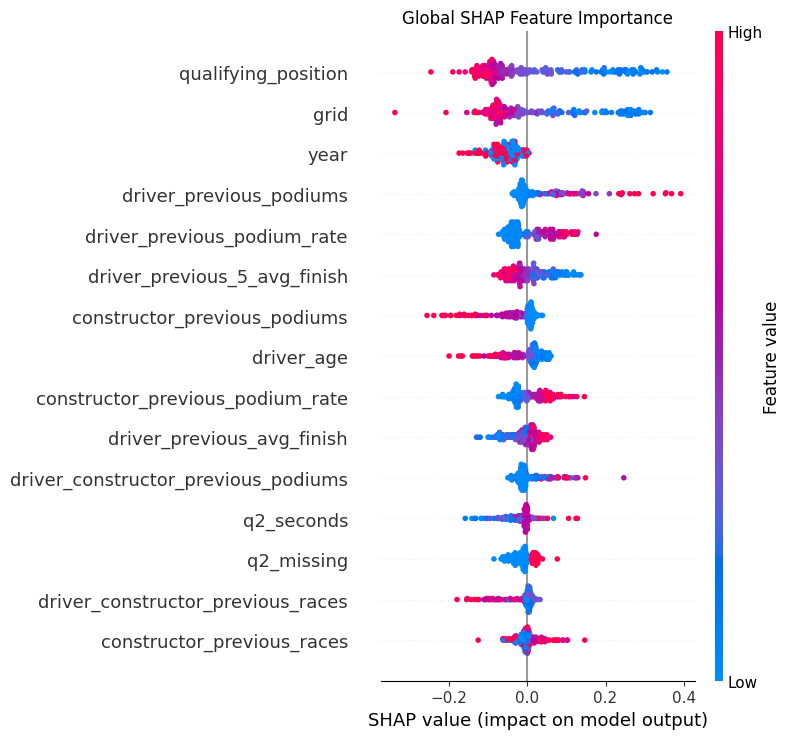

In [ ]:
# ============================================================
# XAI — Global SHAP Explanation
# ============================================================

import shap

# ------------------------------------------------------------
# Use a representative background sample from training data
# and a validation sample for explanation.
# ------------------------------------------------------------


background_size = min(100, len(X_train_main))
explanation_size = min(200, len(X_validation_main))

rng = np.random.default_rng(42)

background_indices = rng.choice(
    len(X_train_main),
    size=background_size,
    replace=False
)

explanation_indices = rng.choice(
    len(X_validation_main),
    size=explanation_size,
    replace=False
)

X_background = X_train_main[background_indices]
X_explanation = X_validation_main[explanation_indices]

# ------------------------------------------------------------
# SHAP GradientExplainer for the neural network
# ------------------------------------------------------------

shap_explainer = shap.GradientExplainer(
    ffnn_model,
    X_background
)

shap_values = shap_explainer.shap_values(
    X_explanation
)

# Handle different SHAP output formats/versions
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.asarray(shap_values)

if shap_values.ndim == 3:
    shap_values = np.squeeze(shap_values, axis=-1)

print("SHAP values shape:", shap_values.shape)
print("Feature matrix shape:", X_explanation.shape)

# ------------------------------------------------------------
# Global SHAP importance
# ------------------------------------------------------------

shap_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Mean Absolute SHAP": np.mean(
        np.abs(shap_values),
        axis=0
    )
}).sort_values(
    "Mean Absolute SHAP",
    ascending=False
).reset_index(drop=True)

display(
    shap_importance_df.head(15).round(4)
)

# ------------------------------------------------------------
# SHAP summary plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_explanation,
    feature_names=X_train.columns,
    max_display=15,
    show=False
)

plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# XAI — Local SHAP Explanation
# ============================================================

candidate_positions = []

for pos, original_idx in enumerate(explanation_indices):
    actual = int(y_validation.iloc[original_idx])
    predicted = int(
        ffnn_validation_proba[original_idx] >= best_threshold_ffnn
    )

    if actual == 1 and predicted == 1:
        candidate_positions.append(pos)

if candidate_positions:
    local_position = max(
        candidate_positions,
        key=lambda p: ffnn_validation_proba[explanation_indices[p]]
    )
else:
    local_position = int(
        np.argmax(
            [ffnn_validation_proba[idx] for idx in explanation_indices]
        )
    )

local_original_idx = explanation_indices[local_position]

local_probability = float(
    ffnn_validation_proba[local_original_idx]
)
local_prediction = int(
    local_probability >= best_threshold_ffnn
)
local_actual = int(
    y_validation.iloc[local_original_idx]
)

local_display_values = X_validation.iloc[
    local_original_idx
].values.astype(float)

# Reconcile the displayed decomposition with the actual model output.
local_base_value = (
    local_probability -
    np.sum(local_shap_values)
)

local_explanation = shap.Explanation(
    values=local_shap_values,
    base_values=local_base_value,
    data=local_display_values,
    feature_names=X_train.columns.tolist()
)

local_features_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Value": local_display_values,
    "SHAP Value": local_shap_values
})

local_features_df["Absolute SHAP"] = np.abs(
    local_features_df["SHAP Value"]
)

print("Local explanation example")
print("-" * 40)
print(f"Validation row position: {local_original_idx}")
print(f"Actual podium:           {local_actual}")
print(f"Predicted podium:        {local_prediction}")
print(f"Predicted probability:   {local_probability:.4f}")
print(f"Decision threshold:      {best_threshold_ffnn:.2f}")

display(
    local_features_df
    .sort_values("Absolute SHAP", ascending=False)
    .head(10)
    .round(4)
)

print(
    f"SHAP reconstructed output: "
    f"{local_base_value + np.sum(local_shap_values):.4f}"
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(
    local_explanation,
    max_display=15,
    show=False
)
plt.title("Local SHAP Explanation — Correctly Predicted Podium")
plt.tight_layout()
plt.show()

### Local Explanation — Individual Prediction

A local SHAP waterfall explains one correctly predicted podium observation.
Positive contributions push the model output toward the podium class, while
negative contributions push it away. For the selected example, the model
assigned a podium probability of approximately **0.9921**.

The strongest positive contributors include historical driver podium count,
qualifying position, driver-constructor podium history, and grid position.
These SHAP contributions describe model behavior for this observation and
should not be interpreted as causal effects.

## Local Explanation — LIME

The milestone checklist names LIME explicitly, while the detailed XAI requirement also accepts
local SHAP. To remove ambiguity, a local **LIME-style tabular surrogate** is added in addition
to the existing local SHAP explanation.

The implementation follows the core LIME idea: generate perturbed samples around one instance,
obtain the model's predictions for those samples, weight nearby samples more heavily, and fit a
weighted local linear surrogate. The resulting coefficients describe which features most
influence the model locally around this individual prediction.

This is a local model explanation, not a causal analysis.


In [ ]:
# ============================================================
# XAI — Local LIME-style explanation
# Self-contained implementation to avoid an external dependency.
# ============================================================

from sklearn.linear_model import Ridge

# Use the same individual selected for the local SHAP explanation.
lime_instance = X_validation_main[local_original_idx].copy()

n_lime_samples = 5000
rng_lime = np.random.default_rng(42)

# Estimate a reasonable perturbation scale from the training data.
feature_scale = np.std(X_train_main, axis=0)
feature_scale = np.where(feature_scale == 0, 1.0, feature_scale)

# Generate local perturbations around the selected instance.
lime_perturbations = (
    lime_instance
    + rng_lime.normal(
        loc=0.0,
        scale=0.5,
        size=(n_lime_samples, X_train_main.shape[1])
    ) * feature_scale
)

# Include the original instance exactly as the first sample.
lime_perturbations[0] = lime_instance

# Model predictions for perturbed samples.
lime_probabilities = ffnn_model.predict(
    lime_perturbations,
    verbose=0
).ravel()

# Euclidean distance in standardized feature space.
scaled_distances = np.linalg.norm(
    (lime_perturbations - lime_instance) /
    feature_scale,
    axis=1
)

# LIME exponential kernel.
kernel_width = 0.75 * np.sqrt(X_train_main.shape[1])

lime_weights = np.exp(
    -(scaled_distances ** 2) /
    (kernel_width ** 2)
)

# Fit weighted local linear surrogate.
lime_surrogate = Ridge(
    alpha=1.0,
    random_state=42
)

lime_surrogate.fit(
    lime_perturbations,
    lime_probabilities,
    sample_weight=lime_weights
)

lime_coefficients = lime_surrogate.coef_

lime_results = pd.DataFrame({
    "Feature": X_train.columns,
    "LIME Weight": lime_coefficients,
    "Absolute Weight": np.abs(lime_coefficients)
}).sort_values(
    "Absolute Weight",
    ascending=False
).reset_index(drop=True)

print("Selected local example:")
print(f"Actual podium: {local_actual}")
print(f"Predicted podium: {local_prediction}")
print(f"Model probability: {local_probability:.4f}")
print(f"Local surrogate R²: {lime_surrogate.score(lime_perturbations, lime_probabilities, sample_weight=lime_weights):.4f}")

display(
    lime_results.head(10).round(4)
)

# Plot the strongest local LIME weights.
lime_plot_df = (
    lime_results.head(10)
    .sort_values("LIME Weight", ascending=True)
)

plt.figure(figsize=(10, 7))
plt.barh(
    lime_plot_df["Feature"],
    lime_plot_df["LIME Weight"]
)
plt.axvline(
    0,
    linestyle="--"
)
plt.xlabel("Local LIME Weight")
plt.ylabel("Feature")
plt.title("Local LIME-style Explanation — Individual Validation Prediction")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

lime_explanation_ready = True


### LIME Interpretation

The LIME coefficients show the direction and local strength of each feature in the neighborhood
of the selected prediction. Positive coefficients push the local surrogate toward a higher
podium probability, while negative coefficients push it toward a lower probability.

The LIME explanation is intentionally interpreted as **local model behavior**. The coefficients
do not mean that the corresponding features causally produce a podium finish.


## Inference Function

In [ ]:
# ============================================================
# Final Inference Function
# ============================================================

def predict_podium(input_record):
    """
    Predict podium vs. non-podium for a complete or partially-missing
    pre-race record using the final Shallow FFNN.
    """

    if isinstance(input_record, dict):
        input_df = pd.DataFrame([input_record])
    elif isinstance(input_record, pd.DataFrame):
        input_df = input_record.copy()
    else:
        raise TypeError(
            "input_record must be a dictionary or pandas DataFrame."
        )

    missing_columns = [
        col for col in X_train.columns
        if col not in input_df.columns
    ]

    if missing_columns:
        raise ValueError(
            "Missing required model features: "
            + ", ".join(missing_columns)
        )

    input_df = input_df[X_train.columns].copy()
    input_processed = preprocessor.transform(input_df)

    probability = float(
        ffnn_model.predict(
            input_processed,
            verbose=0
        ).ravel()[0]
    )

    prediction = int(
        probability >= best_threshold_ffnn
    )

    return {
        "podium_probability": probability,
        "predicted_podium": prediction,
        "classification_threshold": best_threshold_ffnn
    }


# Complete record demonstration
complete_record = X_validation.iloc[739].to_dict()
complete_prediction = predict_podium(complete_record)

# Partially missing record demonstration
partial_record = complete_record.copy()

partial_record["q1_seconds"] = np.nan
partial_record["q2_seconds"] = np.nan
partial_record["q3_seconds"] = np.nan

# Keep missingness indicators consistent with the changed values.
partial_record["q1_missing"] = 1
partial_record["q2_missing"] = 1
partial_record["q3_missing"] = 1

partial_prediction = predict_podium(partial_record)

print("Complete record prediction:")
print(complete_prediction)

print("\nPartially missing record prediction:")
print(partial_prediction)

### Inference Function Demonstration

The inference function uses the same preprocessing pipeline fitted on the
training data and the final FFNN threshold selected from validation data.

A complete record and a partially missing record are both accepted. In the
partial example, the qualifying-time values and their missingness indicators
are modified consistently before prediction.

## Final MS1 Technical Audit

In [ ]:
# ============================================================
# FINAL MS1 TECHNICAL AUDIT
# ============================================================

print("=" * 70)
print("FINAL MS1 TECHNICAL AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Modeling table / grain
# ------------------------------------------------------------

duplicate_pairs = model.duplicated(
    subset=["raceId", "driverId"]
).sum()

print("\n[1] MODELING TABLE")
print(f"Rows: {len(model):,}")
print(f"Columns: {model.shape[1]}")
print(f"Duplicate (raceId, driverId) pairs: {duplicate_pairs}")

assert duplicate_pairs == 0

# ------------------------------------------------------------
# 2. Target
# ------------------------------------------------------------

print("\n[2] TARGET")
print(f"Podium cases: {y_train.sum() + y_validation.sum() + y_test.sum():,}")
print(f"Overall podium rate: {model['podium'].mean():.4f}")

assert set(model["podium"].unique()) <= {0, 1}

# ------------------------------------------------------------
# 3. Temporal split
# ------------------------------------------------------------

print("\n[3] TEMPORAL SPLIT")
print(f"Train:      {len(train):,} rows | years {train['year'].min()}–{train['year'].max()}")
print(f"Validation: {len(validation):,} rows | years {validation['year'].min()}–{validation['year'].max()}")
print(f"Test:       {len(test):,} rows | years {test['year'].min()}–{test['year'].max()}")

assert train["year"].max() <= 2019
assert validation["year"].min() >= 2020
assert validation["year"].max() <= 2021
assert test["year"].min() >= 2022

# ------------------------------------------------------------
# 4. Feature set
# ------------------------------------------------------------

print("\n[4] FEATURES")
print(f"Number of model features: {len(X_train.columns)}")
print("All expected features assigned to ablation groups:",
      set(grouped_features) == set(X_train.columns))

assert set(grouped_features) == set(X_train.columns)

# ------------------------------------------------------------
# 5. Preprocessing
# ------------------------------------------------------------

print("\n[5] PREPROCESSING")

print(
    "Training missing values after preprocessing:",
    np.isnan(X_train_main).sum()
)

print(
    "Validation missing values after preprocessing:",
    np.isnan(X_validation_main).sum()
)

print(
    "Test missing values after preprocessing:",
    np.isnan(X_test_main).sum()
)

assert np.isnan(X_train_main).sum() == 0
assert np.isnan(X_validation_main).sum() == 0
assert np.isnan(X_test_main).sum() == 0

# ------------------------------------------------------------
# 6. Preprocessing-order experiment
# ------------------------------------------------------------

print("\n[6] PREPROCESSING-ORDER EXPERIMENT")

if "results_preprocessing" in globals():
    display(results_preprocessing.round(4))
else:
    print("Preprocessing-order results are not available.")

# 7. Model comparison
# ------------------------------------------------------------

print("\n[7] MODEL COMPARISON")
display(final_fair_comparison.round(4))

# ------------------------------------------------------------
# 8. Final model
# ------------------------------------------------------------

print("\n[8] FINAL MODEL")
print("Model: Shallow FFNN")
print("Architecture: 29 -> 32 -> 16 -> 1")
print(f"Selected threshold: {best_threshold_ffnn:.2f}")
print(f"Validation ROC-AUC: {validation_roc_auc_ffnn:.4f}")
print(f"Validation PR-AUC:  {validation_pr_auc_ffnn:.4f}")
print(f"Validation F1:      {best_validation_f1_ffnn:.4f}")
print(f"Test ROC-AUC:       {test_roc_auc_ffnn:.4f}")
print(f"Test PR-AUC:        {test_pr_auc_ffnn:.4f}")
print(f"Test F1:            {test_f1_ffnn_tuned:.4f}")

# ------------------------------------------------------------
# 9. Feature ablation
# ------------------------------------------------------------

print("\n[9] FEATURE-GROUP ABLATION")
print(f"Experiments completed: {len(ablation_results_df)}")
display(ablation_results_df.round(4))

assert len(ablation_results_df) == 7

# ------------------------------------------------------------
# 10. Permutation importance
# ------------------------------------------------------------

print("\n[10] PERMUTATION IMPORTANCE")
print(f"Features analyzed: {len(permutation_importance_df)}")
display(permutation_importance_df.head(10).round(4))

assert len(permutation_importance_df) == len(X_train.columns)

# ------------------------------------------------------------
# 11. SHAP
# ------------------------------------------------------------

print("\n[11] GLOBAL SHAP")
print(f"SHAP matrix shape: {shap_values.shape}")
print(f"SHAP importance features: {len(shap_importance_df)}")

assert shap_values.shape[1] == len(X_train.columns)

# ------------------------------------------------------------
# 12. Local explanation
# ------------------------------------------------------------

print("\n[12] LOCAL SHAP")
print(f"Actual podium: {local_actual}")
print(f"Predicted podium: {local_prediction}")
print(f"Probability: {local_probability:.4f}")

# ------------------------------------------------------------
# 13. Inference
# ------------------------------------------------------------

print("\n[13] INFERENCE FUNCTION")

print("Complete record:")
print(complete_prediction)

print("Partially missing record:")
print(partial_prediction)

assert "podium_probability" in complete_prediction
assert "predicted_podium" in complete_prediction
assert "podium_probability" in partial_prediction
assert "predicted_podium" in partial_prediction


# ------------------------------------------------------------
# 14. Sentinel / semantic typing
# ------------------------------------------------------------

print("\n[14] SENTINEL / SEMANTIC TYPING")
print(
    "Literal sentinel values remaining:",
    int(sentinel_report_df["Literal \\N values remaining"].sum())
)
print("Race date dtype:", races_typed["date"].dtype)
print("Driver DOB dtype:", drivers_typed["dob"].dtype)

assert sentinel_report_df["Literal \\N values remaining"].sum() == 0
assert pd.api.types.is_datetime64_any_dtype(races_typed["date"])
assert pd.api.types.is_datetime64_any_dtype(drivers_typed["dob"])

# ------------------------------------------------------------
# 15. LIME local explanation
# ------------------------------------------------------------

print("\n[15] LOCAL LIME")
print("LIME explanation ready:", lime_explanation_ready)

assert lime_explanation_ready is True

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MS1 TECHNICAL AUDIT COMPLETED")
print("=" * 70)
print("Core modeling, experiments, XAI, inference, evaluation, and checklist evidence exist.")
print("Next: run the notebook end-to-end in Kaggle, then finalize the PDF report.")

FINAL MS1 TECHNICAL AUDIT

[1] MODELING TABLE
Rows: 10,494
Columns: 58
Duplicate (raceId, driverId) pairs: 0

[2] TARGET
Podium cases: 1,482
Overall podium rate: 0.1412

[3] TEMPORAL SPLIT
Train:      8,356 rows | years 1994–2019
Validation: 779 rows | years 2020–2021
Test:       1,359 rows | years 2022–2024

[4] FEATURES
Number of model features: 29
All expected features assigned to ablation groups: True

[5] PREPROCESSING
Training missing values after preprocessing: 0
Validation missing values after preprocessing: 0
Test missing values after preprocessing: 0

[6] PREPROCESSING-ORDER EXPERIMENT
Imputation -> Standardization: ROC-AUC=0.9282, PR-AUC=0.7217, F1=0.6379
Standardization -> Imputation: ROC-AUC=0.9282, PR-AUC=0.7217, F1=0.6358

[7] MODEL COMPARISON


,Model,Validation ROC-AUC,Validation PR-AUC,Validation F1,Selected Threshold,Test ROC-AUC,Test PR-AUC,Test F1
0,Logistic Regression,0.9282,0.7217,0.7069,0.73,0.9137,0.5920,0.5938
1,Random Forest,0.9180,0.6877,0.6909,0.43,0.9232,0.6274,0.6193
2,Shallow FFNN,0.9298,0.7398,0.7027,0.53,0.9131,0.5748,0.6203



[8] FINAL MODEL
Model: Shallow FFNN
Architecture: 29 -> 32 -> 16 -> 1
Selected threshold: 0.53
Validation ROC-AUC: 0.9298
Validation PR-AUC:  0.7398
Validation F1:      0.7027
Test ROC-AUC:       0.9131
Test PR-AUC:        0.5748
Test F1:            0.6203

[9] FEATURE-GROUP ABLATION
Experiments completed: 7


,Experiment,Removed Group,Remaining Features,Validation ROC-AUC,Validation PR-AUC,Validation F1,PR-AUC Drop,F1 Drop
0,Full Model,None,29,0.9298,0.7398,0.7027,0.0000,0.0000
1,Without Qualifying,Qualifying,22,0.9173,0.7119,0.6364,0.0279,0.0663
2,Without Grid,Grid,28,0.9223,0.7187,0.6667,0.0211,0.0360
3,Without Driver Form,Driver Form,23,0.9175,0.7190,0.6846,0.0207,0.0181
4,Without Constructor Form,Constructor Form,25,0.9170,0.7044,0.6543,0.0353,0.0484
5,Without Driver-Constructor Form,Driver-Constructor Form,25,0.9252,0.7071,0.6935,0.0327,0.0092
6,Without Context,Context,22,0.9260,0.7310,0.6827,0.0087,0.0200



[10] PERMUTATION IMPORTANCE
Features analyzed: 29


,Feature,Mean PR-AUC Drop,Std PR-AUC Drop
0,grid,0.0991,0.0254
1,driver_previous_podiums,0.0990,0.0199
2,qualifying_position,0.0940,0.0132
3,driver_constructor_previous_podiums,0.0349,0.0168
4,q2_seconds,0.0231,0.0137
5,driver_age,0.0129,0.0058
6,alt,0.0093,0.0031
7,constructor_previous_podiums,0.0084,0.0061
8,driver_previous_5_avg_finish,0.0050,0.0139
9,driver_previous_avg_finish,0.0044,0.0071



[11] GLOBAL SHAP
SHAP matrix shape: (200, 29)
SHAP importance features: 29

[12] LOCAL SHAP
Actual podium: 1
Predicted podium: 1
Probability: 0.9921

[13] INFERENCE FUNCTION
Complete record:
{'podium_probability': 0.9920765161514282, 'predicted_podium': 1, 'classification_threshold': 0.5300000000000001}
Partially missing record:
{'podium_probability': 0.9920178055763245, 'predicted_podium': 1, 'classification_threshold': 0.5300000000000001}

MS1 TECHNICAL AUDIT COMPLETED
Core modeling, experiments, XAI, inference, and evaluation outputs exist.
Next: notebook organization + final written report.


## Final Written Summary

# Feature Selection and Pre-Race Validity

The selected features were designed around information available after qualifying
and before the race begins. Features were grouped into qualifying, grid, driver
form, constructor form, driver-constructor form, and contextual information.

Qualifying features were retained because exploratory analysis showed a strong
relationship between qualifying position and podium probability. Grid position was
also retained because actual starting position can differ from qualifying position,
and the analysis therefore treats these as separate concepts.

Driver, constructor, and driver-constructor historical features were calculated
using only previous races. These features capture past performance without using
the current race result or any post-race information.

Contextual features such as driver age, race year, round, home-race status, and
circuit geographic characteristics are available before race start and therefore
do not violate the prediction cutoff.

Feature-group ablation provided additional empirical evidence for retaining the
groups. Removing Constructor Form caused the largest PR-AUC decrease (0.0353),
followed by Driver-Constructor Form (0.0327), Qualifying (0.0279), Grid (0.0211),
and Driver Form (0.0207). Removing Qualifying also caused the largest F1 decrease
(0.0663).

The final feature set therefore combines direct pre-race competitive information
with leakage-safe historical performance information.

Feature importance and ablation results describe predictive usefulness within the
trained model and should not be interpreted as causal effects.

# Known Limitations

### Historical qualifying coverage

Qualifying data coverage is incomplete in earlier Formula 1 seasons and becomes
substantially more consistent in later seasons. The modeling population therefore
contains only driver-race records with an observed qualifying record. This avoids
inventing qualifying information but introduces historical coverage drift.

### Temporal and era sensitivity

The model was trained on seasons through 2019, validated on 2020–2021, and tested
on 2022–2024. Performance decreased from validation to the unseen test period,
especially for PR-AUC and F1. This indicates that relationships learned from
earlier seasons do not transfer perfectly to later F1 eras.

### Historical-format differences

Formula 1 has changed substantially across eras, including qualifying formats,
team structures, regulations, and race formats. Features such as year and round
may therefore capture some era-specific differences.

### Interpretation limitations

Permutation importance and SHAP explain how the trained model uses available
features for prediction. They do not establish that an important feature causes
a podium finish.

### Prediction scope

The milestone predicts a binary outcome: podium versus non-podium. It does not
predict the exact finishing position or the specific podium position.

# Final Project Conclusion

The project developed a leakage-safe F1 driver-race modeling dataset for binary
podium prediction. The final dataset contains one row per driver entering a race,
with features restricted to information available at the pre-race cutoff.

Three models were compared: Logistic Regression, Random Forest, and a shallow
Feed-Forward Neural Network. PR-AUC was selected as the primary metric because
podium finishes are the minority class, while F1 was selected as the secondary
metric for evaluating the final binary decision.

The Shallow FFNN was selected as the final model based on validation performance.
It achieved the highest validation ROC-AUC (0.9298) and PR-AUC (0.7398), with an
F1-score of 0.7027 after selecting a validation-only threshold of 0.53.

On the unseen 2022–2024 test period, the final FFNN achieved a ROC-AUC of 0.9131,
PR-AUC of 0.5748, and F1-score of 0.6203. The decrease in performance from
validation to test indicates temporal/era sensitivity and is therefore reported
as an important limitation rather than hidden.

Feature-group ablation showed that qualifying, grid, driver form, constructor
form, driver-constructor form, and contextual features all contributed useful
predictive information. Global permutation importance and SHAP provided
model-level explanations, while a local SHAP waterfall demonstrated how the
model combined features for an individual prediction.

The final inference function successfully handled both complete and partially
missing pre-race records.

## MS1 Final Submission Checklist

### Notebook requirements

- [x] Exploratory Data Analysis (EDA) with visualizations
- [x] Data Cleaning: `\N` sentinel handling and semantic typing
- [x] Grain fixed to one row per `(raceId, driverId)`
- [x] Duplicate handling documented and cleaning impact visualized
- [x] Primary-key uniqueness/null checks
- [x] Foreign-key reconciliation
- [x] Data Analysis with plotted results
- [x] Data-Engineering Question 1: analysis + visualization + written answer
- [x] Data-Engineering Question 2: analysis + visualization + written answer
- [x] Data-Engineering Question 3: analysis + visualization + written answer
- [x] Feature selection justified with EDA and ablation evidence
- [x] Feature-effect visualizations
- [x] Leakage-safe historical form features using only past races
- [x] Feature engineering
- [x] Preprocessing effect on ranges/distributions
- [x] At least two preprocessing-order experiments
- [x] Chronological train/validation/test split
- [x] Logistic Regression
- [x] Random Forest
- [x] Shallow FFNN
- [x] Model mechanics and limitations documented
- [x] Training and validation performance reported
- [x] Validation-selected thresholds documented
- [x] Unseen test performance reported
- [x] Validation and test model-comparison plots
- [x] Feature-group ablation
- [x] Global permutation importance + plot + interpretation
- [x] Global SHAP + plot + interpretation
- [x] Local SHAP + plot + interpretation
- [x] Local LIME-style explanation + plot + interpretation
- [x] Inference function
- [x] Inference demonstrated on complete and partially missing records
- [x] Final technical audit

### Final submission actions outside the notebook

- [ ] Run the entire notebook from the first cell using **Run All** in Kaggle and confirm zero errors.
- [ ] Export/prepare the structured PDF report containing the DEQ answers, figures, feature rationale, model comparison, ablation, XAI, inference example, and limitations.
- [ ] Verify the submitted Kaggle notebook link and GitHub repository link are accessible.

The first section is complete in the notebook. The last three items are final submission actions that must be performed after the cleaned notebook is executed in the target Kaggle environment.
